# Design and Performance Evaluation of a Machine Learning-Based Smart Agriculture Monitoring System for Rural Nigerian Communities

**Author:** David Edet Mbre (24/PG/EG/EE/002)
**Programme:** M.Eng Electrical and Electronics Engineering
**Supervisors:** Dr. Engr. Emmanuel Ogungbemi, Dr. Akaninyene Obot

---

## 1. Project Goal
Build, train, evaluate and benchmark a suite of classical, ensemble, and deep-learning
models that ingest soil, weather, and IoT sensor data to (a) recommend optimal crops,
(b) predict irrigation needs, and (c) provide yield-relevant insights tailored to rural
Nigerian agro-ecological zones.

## 2. Datasets Used
| # | Dataset | Source | Role |
|---|---------|--------|------|
| 1 | Nigeria Digital Soil Map (DSM) | Mendeley (Nkwunonwo et al., 2020) | Geographic/soil context for Nigeria |
| 2 | Crop Recommendation Dataset | Kaggle (Atharva Ingle) | Primary ML training (NPK + climate → crop) |
| 3 | Advanced IoT Agriculture 2024 | Kaggle (Tikrit University) | Plant growth phenotype features |
| 4 | IoT Agriculture 2024 | Kaggle (Tikrit University) | Real IoT sensor + actuator data |
| 5 | HarvestStat Africa (Nigeria subset) | Dryad (Lee et al., 2025) | Subnational yield statistics |
| 6 | Smart Agriculture Dataset | Kaggle (Chaitanya Gopidesi) | Irrigation decision data |
| 7 | CropHarvest (Nigeria task) | Zenodo (Tseng et al., 2021) | Remote-sensing time-series |
| 8 | OpenWeatherMap API | live API | Real-time weather inputs |

## 3. Analytical Pipeline
1. **Per-dataset EDA** — load, profile, clean, visualise, save figures.
2. **Cross-dataset fusion** — harmonise schemas, engineer composite features.
3. **Feature engineering & scaling** — encoding, standardisation, dimensionality reduction.
4. **Classical ML benchmark** — 9 models with stratified k-fold CV and hyperparameter tuning.
5. **Ensemble methods** — voting, stacking, boosting.
6. **Deep-learning models** — MLP, 1-D CNN, LSTM, TabNet-style attention.
7. **Comparative analysis** — accuracy, F1, ROC-AUC, inference time, model size.
8. **Explainability** — SHAP feature attribution for the best model.

## 4. Conventions
- Every figure is saved to `/content/figures/figure_NN_<name>.png` at 300 dpi
  AND offered as a download via `files.download()`.
- Every figure has an inline comment `# Figure N: <caption>` for direct reuse in the thesis.
- Raw numerical outputs are printed verbatim (so they can be quoted in the write-up).
- Random seed fixed at `42` everywhere for reproducibility.

In [ ]:
# CELL 2: Install all required libraries
# (Colab already ships with pandas, numpy, sklearn, tensorflow, matplotlib, seaborn.
#  We only add the specialised ones.)

!pip install xgboost
!pip install lightgbm
!pip install catboost
!pip install imbalanced-learn
!pip install shap
!pip install optuna
!pip install requests
!pip install folium
!pip install plotly
!pip install openpyxl
!pip install kaggle

# print("✅ All extra libraries installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 30.8 MB/s eta 0:00:00


In [ ]:
# CELL 3: Imports, seeds, plotting style, output folders
import os, sys, json, warnings, random, time, zipfile, io, requests
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# ML / DL
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, GridSearchCV, RandomizedSearchCV)
from sklearn.preprocessing import (StandardScaler, MinMaxScaler, LabelEncoder,
                                   OneHotEncoder, RobustScaler)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, mean_squared_error,
                             r2_score, mean_absolute_error)

# Classical models
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              ExtraTreesClassifier, AdaBoostClassifier,
                              VotingClassifier, StackingClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Gradient boosting
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers

# Explainability
import shap

# Hyperparameter optimisation
import optuna

# Geospatial
import geopandas as gpd

# Google Colab utilities
try:
    from google.colab import files, drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="viridis", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["savefig.bbox"] = "tight"

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# Output folders
FIG_DIR = Path("/content/figures"); FIG_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR = Path("/content/data");   DATA_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR = Path("/content/models"); MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Figure counter — used across the whole notebook
FIG_COUNTER = {"n": 0}

def save_fig(name: str, dpi: int = 300, also_download: bool = True):
    """Save the current matplotlib figure under a descriptive name, then offer download."""
    FIG_COUNTER["n"] += 1
    n = FIG_COUNTER["n"]
    fname = FIG_DIR / f"{name}.png"  # descriptive name, no figure number
    plt.savefig(fname, dpi=dpi, bbox_inches="tight")
    print(f"   💾 Saved → {fname}")
    if also_download and IN_COLAB:
        try:
            files.download(str(fname))
        except Exception as e:
            print(f"   (auto-download skipped: {e})")
    return fname

print("TensorFlow version:", tf.__version__)
print("GPU available     :", tf.config.list_physical_devices('GPU'))
print("Random seed       :", SEED)
print("Figures folder    :", FIG_DIR)

# SECTION 1 — Crop Recommendation Dataset (Kaggle)

The **primary training dataset** for the crop-recommendation task.
2,200 records × 8 columns: `N, P, K, temperature, humidity, ph, rainfall, label`.
22 crop classes. Clean, balanced, ML-ready.

In [ ]:
# CELL 5: Pull the Crop Recommendation CSV
# Method B — using Kaggle API (Method A failed)

# IMPORTANT: You need to upload your `kaggle.json` file for authentication.
# Go to your Kaggle account settings, click 'Create New API Token', and download the kaggle.json file.
# Then, run this cell and upload the file when prompted.
from google.colab import files
import pandas as pd

if not (DATA_DIR / "Crop_recommendation.csv").exists():
    print("Please upload your kaggle.json file. Click 'Choose Files' below.")
    files.upload()   # upload your kaggle.json
    !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
    !kaggle datasets download -d atharvaingle/crop-recommendation-dataset -p {DATA_DIR} --unzip

CROP_PATH = DATA_DIR / "Crop_recommendation.csv"

if CROP_PATH.exists():
    crop_df = pd.read_csv(CROP_PATH)
    print("Shape     :", crop_df.shape)
    print("\nFirst rows:")
    print(crop_df.head())
    print("\nDtypes:")
    print(crop_df.dtypes)
    print("\nMissing values per column:")
    print(crop_df.isna().sum())
else:
    print(f"Error: {CROP_PATH} not found after download attempt.")

Please upload your kaggle.json file. Click 'Choose Files' below.


In [ ]:
crop_df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [ ]:
crop_df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [ ]:
# CELL 6: Statistical profile + class balance
print("=" * 70)
print("CROP RECOMMENDATION — STATISTICAL SUMMARY")
print("=" * 70)
print(crop_df.describe().T.round(3))


CROP RECOMMENDATION — STATISTICAL SUMMARY
              count     mean     std     min     25%     50%      75%      max
N            2200.0   50.552  36.917   0.000  21.000  37.000   84.250  140.000
P            2200.0   53.363  32.986   5.000  28.000  51.000   68.000  145.000
K            2200.0   48.149  50.648   5.000  20.000  32.000   49.000  205.000
temperature  2200.0   25.616   5.064   8.826  22.769  25.599   28.562   43.675
humidity     2200.0   71.482  22.264  14.258  60.262  80.473   89.949   99.982
ph           2200.0    6.469   0.774   3.505   5.972   6.425    6.924    9.935
rainfall     2200.0  103.464  54.958  20.211  64.552  94.868  124.268  298.560


In [ ]:
print("\nClass distribution (22 crops):")
class_counts = crop_df["label"].value_counts()
print(class_counts)
print(f"\nNumber of classes : {crop_df['label'].nunique()}")
print(f"Balanced?         : {'Yes' if class_counts.std() < 1 else 'No'}")


Class distribution (22 crops):
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

Number of classes : 22
Balanced?         : Yes


   💾 Saved → /content/figures/figure_01_crop_class_distribution.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

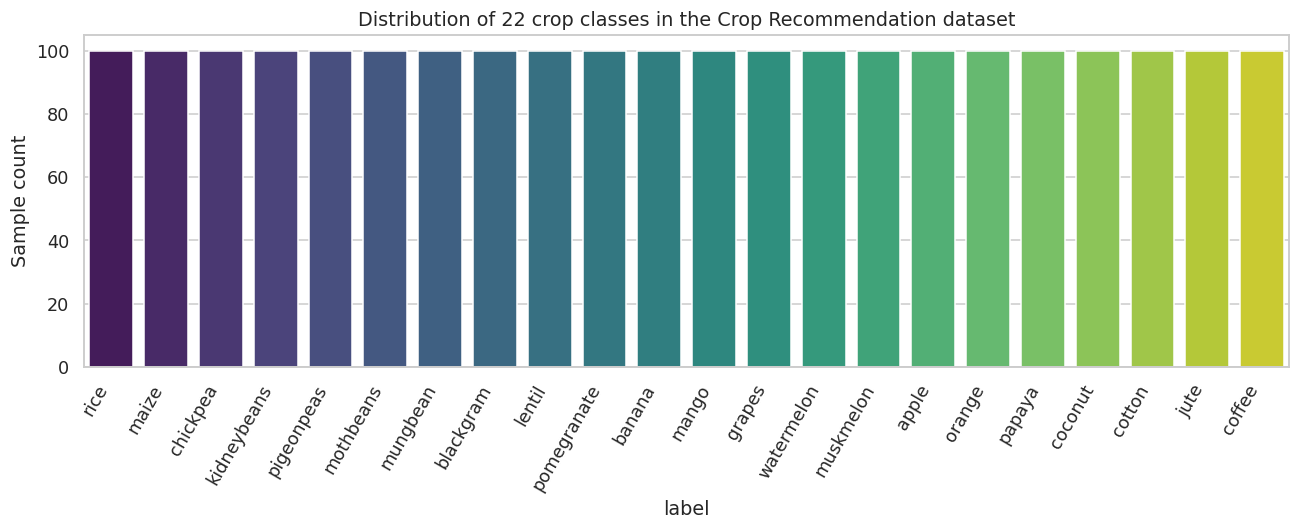

In [ ]:
# CELL 7: Visualisations for Crop Recommendation Dataset
# Class distribution
plt.figure(figsize=(12, 5))
sns.countplot(data=crop_df, x="label",
              order=crop_df["label"].value_counts().index, palette="viridis")
plt.xticks(rotation=60, ha="right")
plt.title("Distribution of 22 crop classes in the Crop Recommendation dataset")
plt.ylabel("Sample count")
plt.tight_layout()
save_fig("crop_class_distribution")
plt.show()

   💾 Saved → /content/figures/figure_02_crop_correlation_heatmap.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

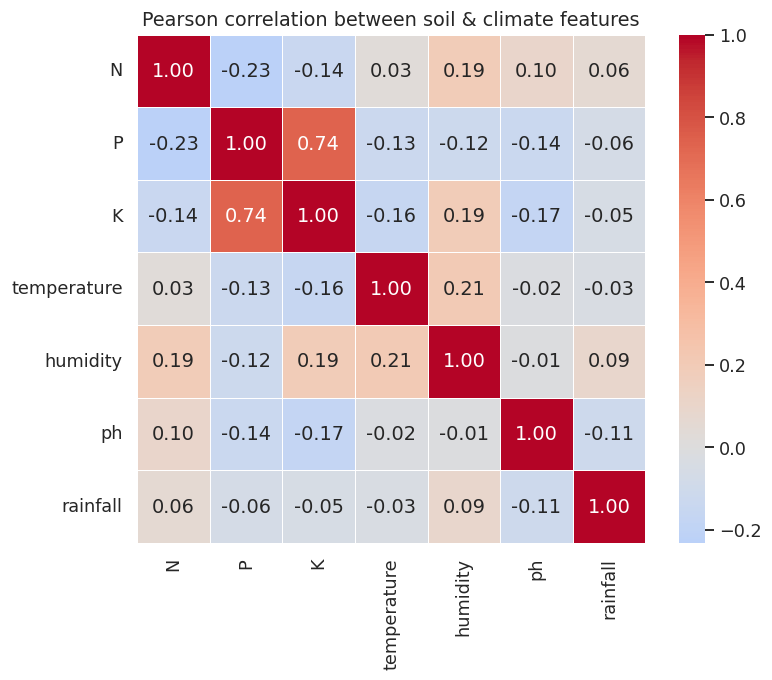

In [ ]:
# Correlation heatmap of numeric features
plt.figure(figsize=(8, 6))
numeric_cols = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
sns.heatmap(crop_df[numeric_cols].corr(), annot=True, cmap="coolwarm",
            fmt=".2f", center=0, square=True, linewidths=0.5)
plt.title("Pearson correlation between soil & climate features")
save_fig("crop_correlation_heatmap")
plt.show()

   💾 Saved → /content/figures/figure_03_crop_feature_distributions.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

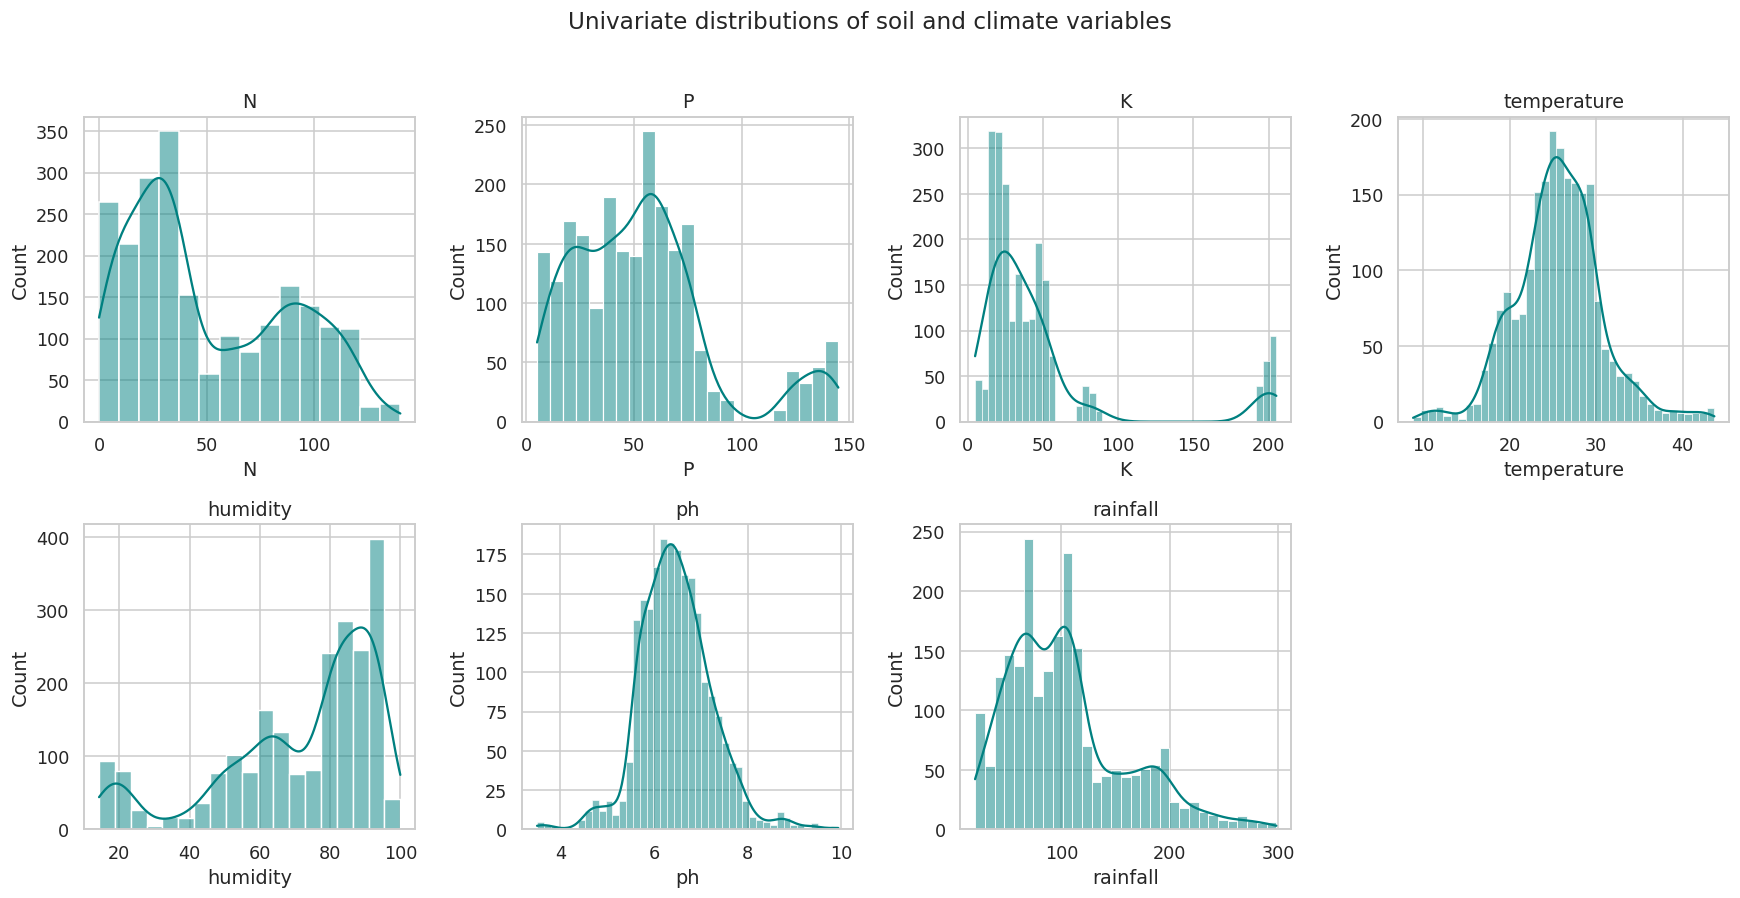

In [ ]:
# Distribution of each numeric feature
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(crop_df[col], kde=True, ax=ax, color="teal")
    ax.set_title(f"{col}")
axes.flat[-1].axis("off")
plt.suptitle("Univariate distributions of soil and climate variables", y=1.02)
plt.tight_layout()
save_fig("crop_feature_distributions")
plt.show()

   💾 Saved → /content/figures/figure_04_crop_mean_profile_heatmap.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

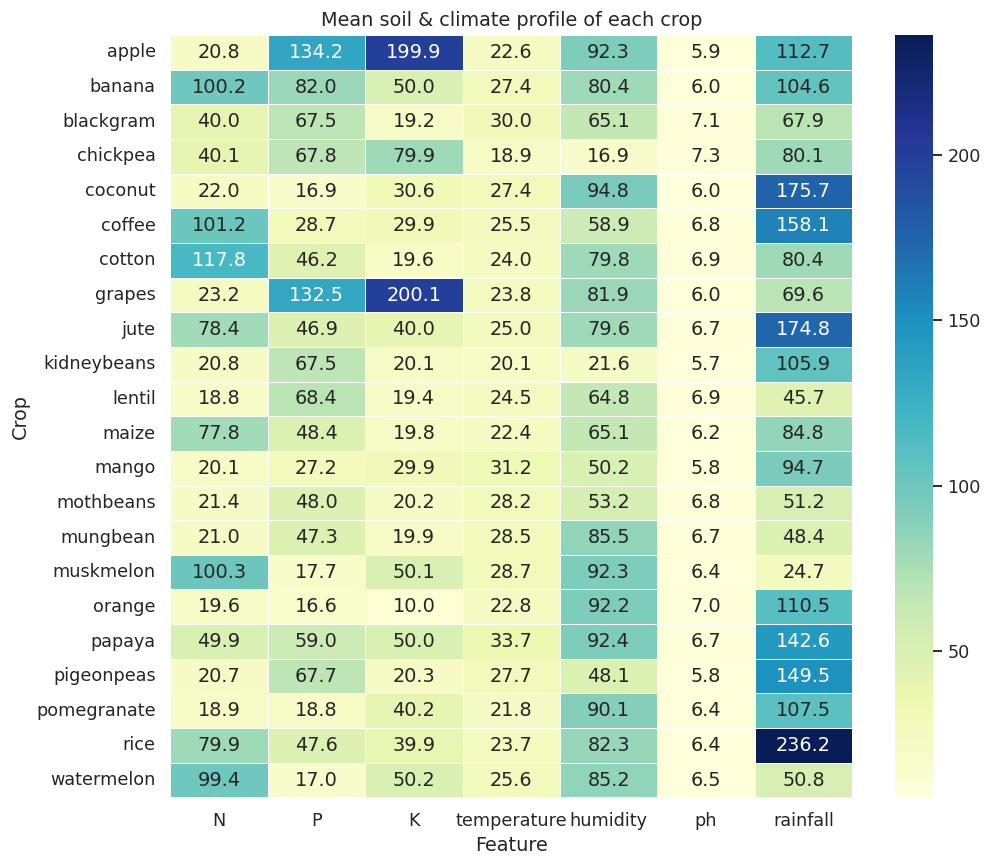

In [ ]:

# Per-crop mean profile (heatmap of crop × feature means)
crop_means = crop_df.groupby("label")[numeric_cols].mean()
plt.figure(figsize=(10, 9))
sns.heatmap(crop_means, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=0.4)
plt.title("Mean soil & climate profile of each crop")
plt.xlabel("Feature")
plt.ylabel("Crop")
save_fig("crop_mean_profile_heatmap")
plt.show()

   💾 Saved → /content/figures/figure_05_crop_pairplot_npk_rainfall.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

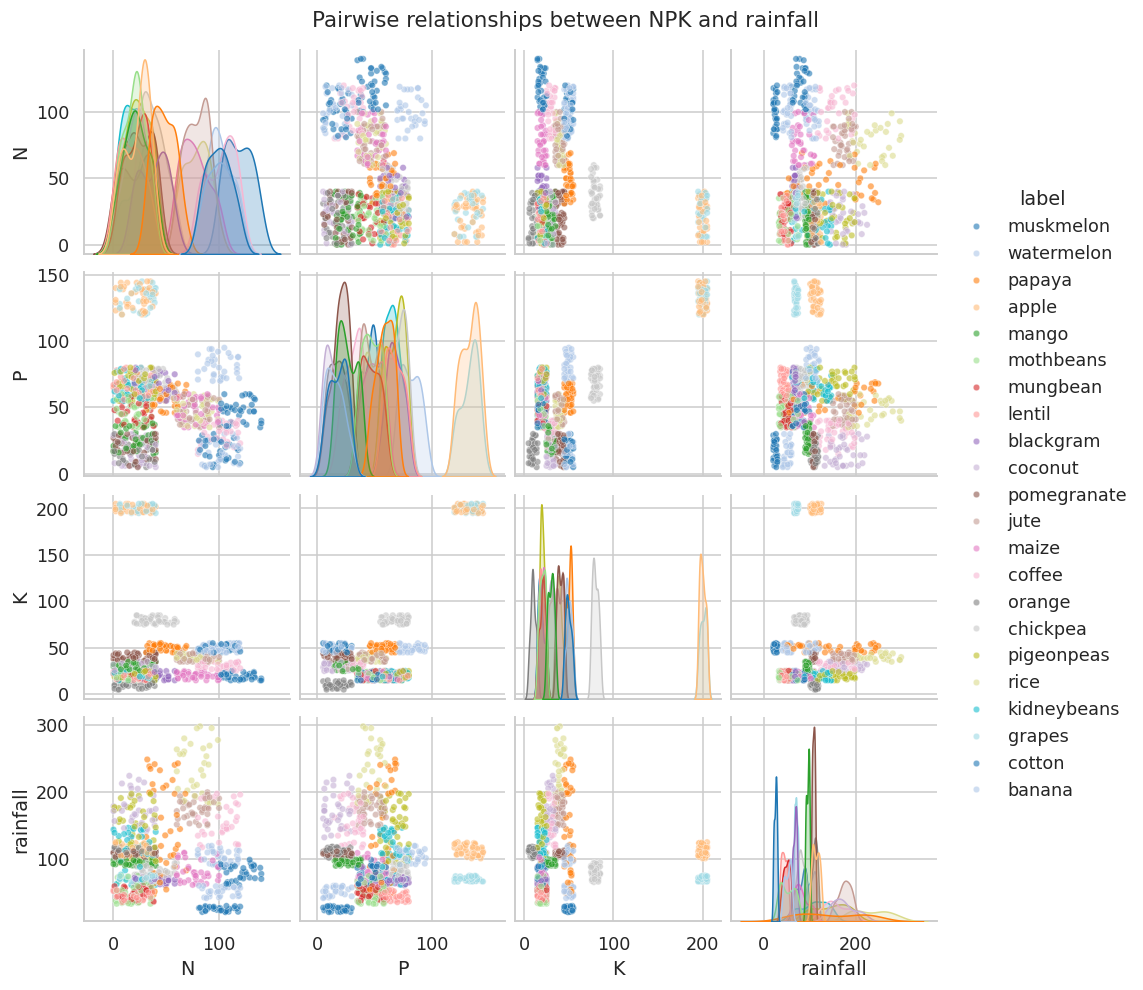

In [ ]:
# Pairwise scatter (NPK vs rainfall, coloured by crop family)
sample = crop_df.sample(n=min(800, len(crop_df)), random_state=SEED)
g = sns.pairplot(sample, vars=["N", "P", "K", "rainfall"], hue="label",
                 palette="tab20", height=2.2, plot_kws={"alpha": 0.6, "s": 18})
g.fig.suptitle("Pairwise relationships between NPK and rainfall",
               y=1.02, fontsize=14)
save_fig("crop_pairplot_npk_rainfall")
plt.show()

   💾 Saved → /content/figures/figure_06_crop_ph_boxplot.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

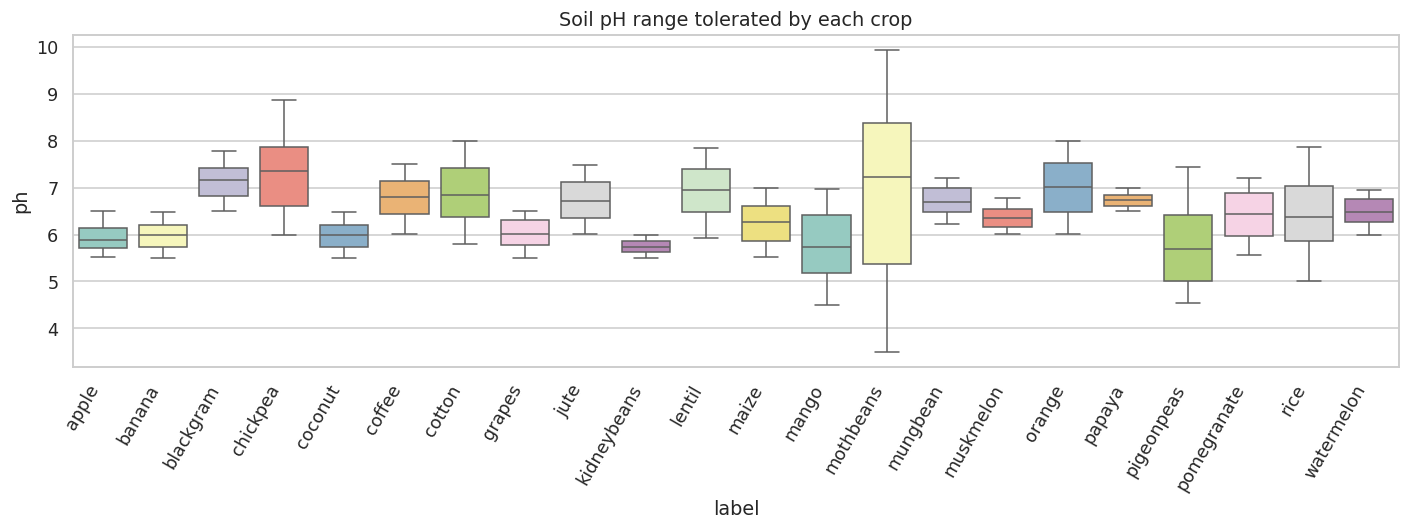

In [ ]:

# Boxplots of pH per crop
plt.figure(figsize=(13, 5))
sns.boxplot(data=crop_df, x="label", y="ph",
            order=sorted(crop_df["label"].unique()), palette="Set3")
plt.xticks(rotation=60, ha="right")
plt.title("Soil pH range tolerated by each crop")
plt.tight_layout()
save_fig("crop_ph_boxplot")
plt.show()

# SECTION 2 — IoT Agriculture 2024 (Tikrit University)

37,923 rows × 13 columns of real IoT greenhouse readings:
`date, temperature, humidity, water_level, N, P, K`
plus one-hot encoded actuator states (fan, plant pump, water pump).
Excellent for **time-series EDA** and **actuator-decision classification**.

In [ ]:
# CELL 9: Load IoT Agriculture 2024 via Kaggle API
# Upload kaggle.json once (it stays for the session).

# if not Path("/root/.kaggle/kaggle.json").exists():
#     print("⬆️  Please upload your kaggle.json (Kaggle → Account → Create API token):")
#     if IN_COLAB:
#         files.upload()
#         !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

# !kaggle datasets download -d wisam1985/iot-agriculture-2024 -p {DATA_DIR} --unzip -q

# # Find the CSV (filename sometimes varies)
# iot_csv = next(DATA_DIR.glob("*IoT*Agriculture*.csv"), None) \
#        or next(DATA_DIR.glob("*Agriculture*.csv"), None) \
#        or next(DATA_DIR.glob("*.csv"), None)
# print("Loaded:", iot_csv)

iot_df = pd.read_csv("/content/IoTProcessed_Data.csv")

print("Shape :", iot_df.shape)
print("\nColumns:", list(iot_df.columns))
print("\nFirst rows:"); print(iot_df.head())
print("\nDtypes:"); print(iot_df.dtypes)

Shape : (16105, 13)

Columns: ['date', 'tempreature', 'humidity', 'water_level', 'N', 'P', 'K', 'Fan_actuator_OFF', 'Fan_actuator_ON', 'Watering_plant_pump_OFF', 'Watering_plant_pump_ON', 'Water_pump_actuator_OFF', 'Water_pump_actuator_ON']

First rows:
                  date  tempreature  humidity  water_level    N    P    K  \
0  2024-02-08 06:10:00           41        63          100  255  255  255   
1  2024-02-08 06:15:00           41        59          100  255  255  255   
2  2024-02-08 06:20:00           41        62          100  255  255  255   
3  2024-02-08 06:05:00           40        60          100  255  255  255   
4  2024-02-08 06:00:00           39        61          100  255  255  255   

   Fan_actuator_OFF  Fan_actuator_ON  Watering_plant_pump_OFF  \
0               0.0              1.0                      1.0   
1               0.0              1.0                      1.0   
2               0.0              1.0                      1.0   
3               0.0    

In [ ]:
iot_df

,date,tempreature,humidity,water_level,N,P,K,Fan_actuator_OFF,Fan_actuator_ON,Watering_plant_pump_OFF,Watering_plant_pump_ON,Water_pump_actuator_OFF,Water_pump_actuator_ON
0,2024-02-08 06:10:00,41,63,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0
1,2024-02-08 06:15:00,41,59,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0
2,2024-02-08 06:20:00,41,62,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0
3,2024-02-08 06:05:00,40,60,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0
4,2024-02-08 06:00:00,39,61,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16100,2023-12-07 12:32:00,18,58,60,183,187,158,1.0,0.0,1.0,0.0,0.0,1.0
16101,2023-12-07 12:27:00,18,58,60,183,187,158,1.0,0.0,1.0,0.0,0.0,1.0
16102,2023-12-07 12:22:00,18,57,60,183,187,158,1.0,0.0,1.0,0.0,0.0,1.0
16103,2023-12-07 12:17:00,18,58,60,183,187,158,1.0,0.0,1.0,0.0,0.0,1.0


In [ ]:
iot_df.head()

,date,tempreature,humidity,water_level,N,P,K,Fan_actuator_OFF,Fan_actuator_ON,Watering_plant_pump_OFF,Watering_plant_pump_ON,Water_pump_actuator_OFF,Water_pump_actuator_ON
0,2024-02-08 06:10:00,41,63,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0
1,2024-02-08 06:15:00,41,59,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0
2,2024-02-08 06:20:00,41,62,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0
3,2024-02-08 06:05:00,40,60,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0
4,2024-02-08 06:00:00,39,61,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0


In [ ]:
iot_df.columns

Index(['date', 'tempreature', 'humidity', 'water_level', 'N', 'P', 'K',
       'Fan_actuator_OFF', 'Fan_actuator_ON', 'Watering_plant_pump_OFF',
       'Watering_plant_pump_ON', 'Water_pump_actuator_OFF',
       'Water_pump_actuator_ON'],
      dtype='object')

In [ ]:
# CELL 10: Parse dates, engineer time features, profile actuators
# Normalise column names (the published CSV has a typo: "tempreature")
iot_df.columns = [c.strip().lower().replace("tempreature", "temperature")
                  for c in iot_df.columns]
print("Normalised columns:", list(iot_df.columns))

# Parse datetime
iot_df["date"] = pd.to_datetime(iot_df["date"], errors="coerce")
iot_df = iot_df.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

# Time features
iot_df["hour"]      = iot_df["date"].dt.hour
iot_df["dayofweek"] = iot_df["date"].dt.dayofweek
iot_df["month"]     = iot_df["date"].dt.month

# Reconstruct categorical actuator states from one-hot pairs (if present)
def collapse_pair(df, off_col, on_col, new_col):
    if off_col in df.columns and on_col in df.columns:
        df[new_col] = np.where(df[on_col] == 1, "ON", "OFF")
    return df

iot_df = collapse_pair(iot_df, "fan_actuator_off",        "fan_actuator_on",        "fan_state")
iot_df = collapse_pair(iot_df, "watering_plant_pump_off", "watering_plant_pump_on", "plant_pump_state")
iot_df = collapse_pair(iot_df, "water_pump_actuator_off", "water_pump_actuator_on", "water_pump_state")


Normalised columns: ['date', 'temperature', 'humidity', 'water_level', 'n', 'p', 'k', 'fan_actuator_off', 'fan_actuator_on', 'watering_plant_pump_off', 'watering_plant_pump_on', 'water_pump_actuator_off', 'water_pump_actuator_on']


In [ ]:
print("\nDescriptive stats:"); print(iot_df.describe().T.round(2))
print("\nActuator distributions:")
for c in ["fan_state", "plant_pump_state", "water_pump_state"]:
    if c in iot_df.columns:
        print(f"\n{c}:"); print(iot_df[c].value_counts(dropna=False))


Descriptive stats:
                           count                           mean  \
date                       16103  2024-01-11 00:45:54.053282048   
temperature              16103.0                      26.000373   
humidity                 16103.0                      47.858846   
water_level              16103.0                      70.989816   
n                        16103.0                     231.699683   
p                        16103.0                     233.856176   
k                        16103.0                     224.773831   
fan_actuator_off         16103.0                       0.269639   
fan_actuator_on          16103.0                       0.730361   
watering_plant_pump_off  16103.0                        0.71732   
watering_plant_pump_on   16103.0                        0.28268   
water_pump_actuator_off  16103.0                       0.692231   
water_pump_actuator_on   16102.0                       0.307726   
hour                     16103.0          

   💾 Saved → /content/figures/figure_07_iot_hourly_temp_humidity.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

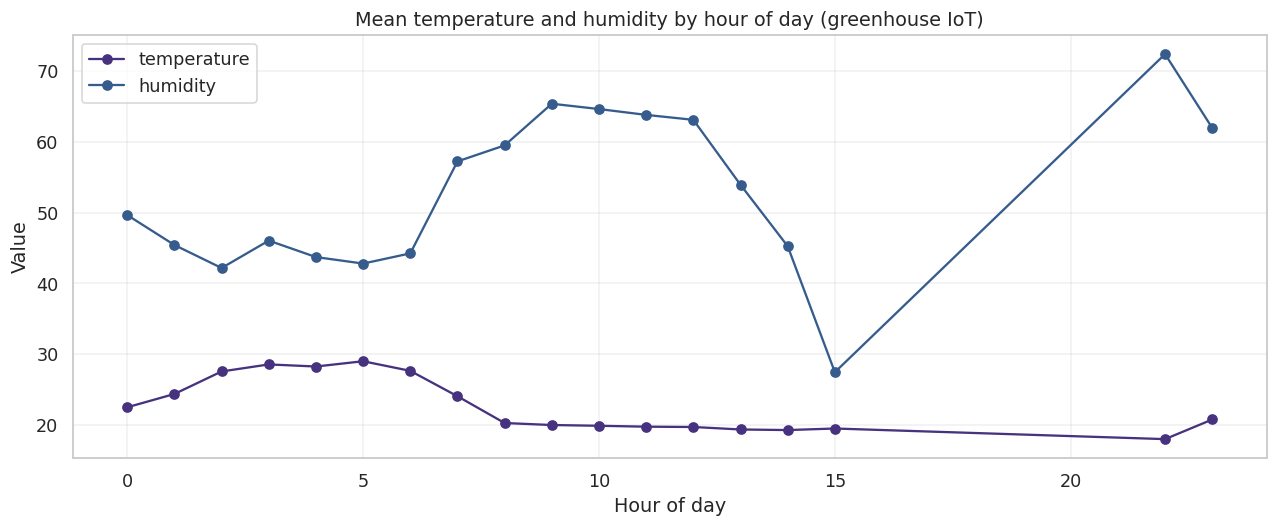

In [ ]:
# CELL 11: Visualisations for IoT Agriculture 2024

# Hourly temperature and humidity trends
plt.figure(figsize=(14, 5))
hourly = iot_df.groupby("hour")[["temperature", "humidity"]].mean()
hourly.plot(ax=plt.gca(), marker="o")
plt.title("Mean temperature and humidity by hour of day (greenhouse IoT)")
plt.xlabel("Hour of day"); plt.ylabel("Value")
plt.grid(True, alpha=0.3)
save_fig("iot_hourly_temp_humidity")
plt.show()

   💾 Saved → /content/figures/figure_08_iot_temperature_timeseries.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

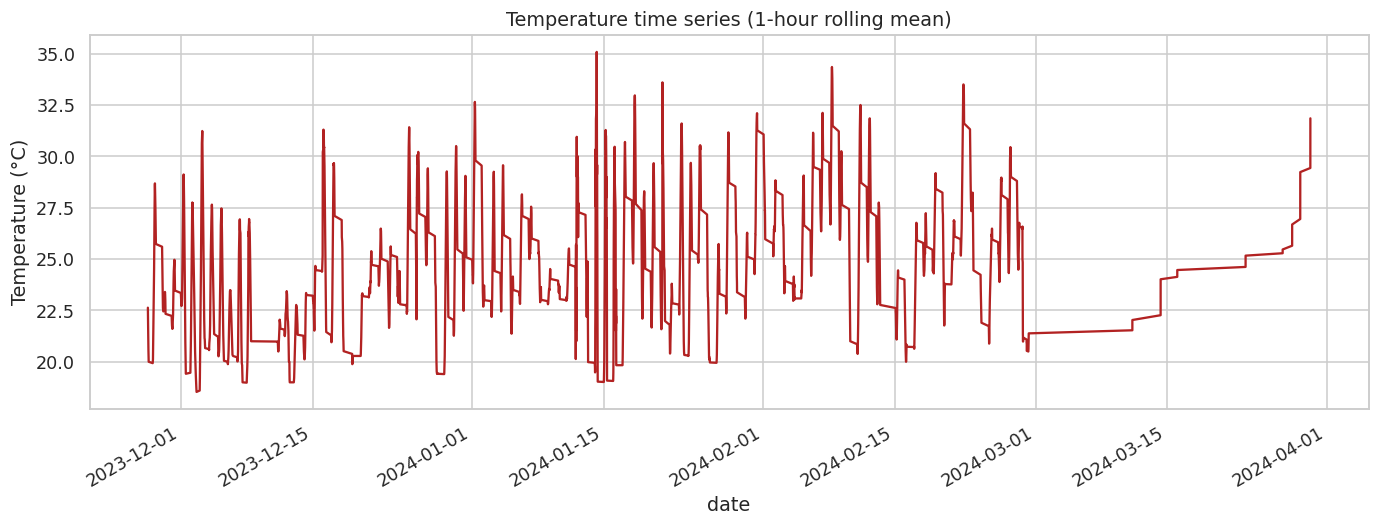

In [ ]:
# Time-series of temperature over the full period
plt.figure(figsize=(15, 5))
iot_df.set_index("date")["temperature"].rolling(60).mean().plot(color="firebrick")
plt.title("Temperature time series (1-hour rolling mean)")
plt.ylabel("Temperature (°C)")
save_fig("iot_temperature_timeseries")
plt.show()


   💾 Saved → /content/figures/figure_09_iot_npk_distribution.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

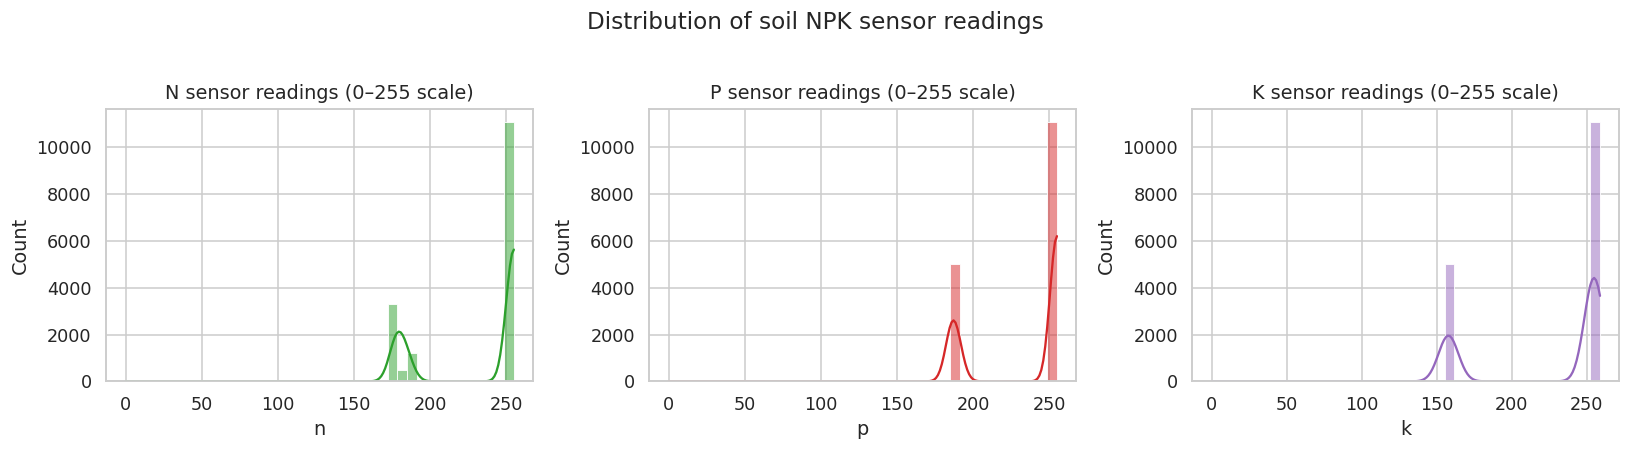

In [ ]:
# NPK readings distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes, ["n", "p", "k"], ["#2ca02c", "#d62728", "#9467bd"]):
    sns.histplot(iot_df[col], bins=40, kde=True, ax=ax, color=color)
    ax.set_title(f"{col.upper()} sensor readings (0–255 scale)")
plt.suptitle("Distribution of soil NPK sensor readings", y=1.02)
plt.tight_layout()
save_fig("iot_npk_distribution")
plt.show()

   💾 Saved → /content/figures/figure_10_iot_actuator_distribution.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

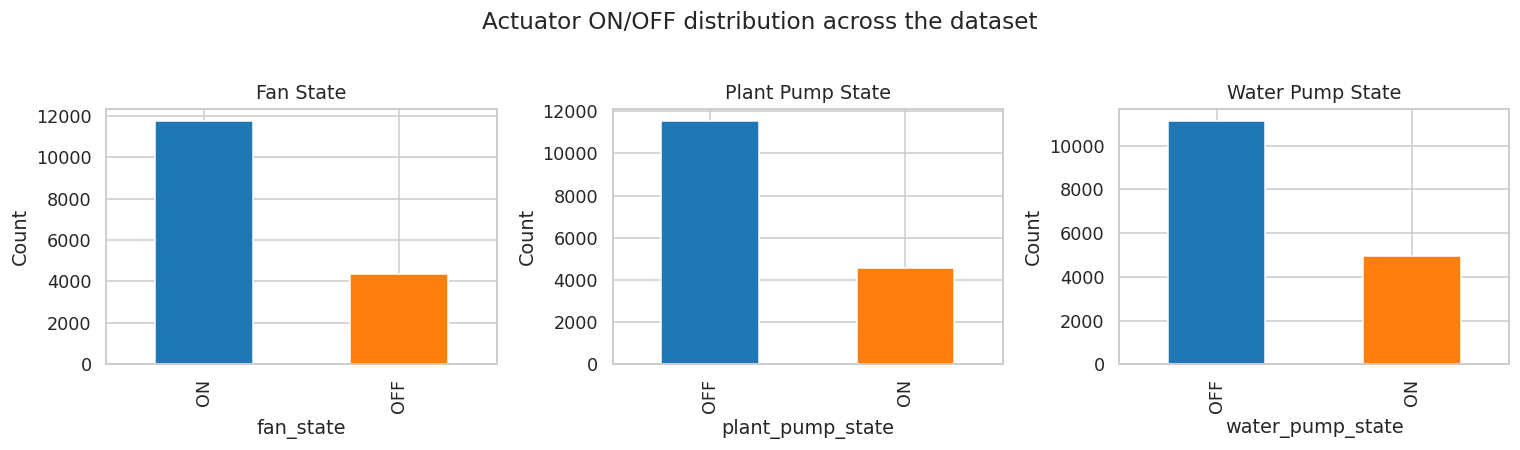

In [ ]:
# Actuator activation rates
if "fan_state" in iot_df.columns:
    actuators = ["fan_state", "plant_pump_state", "water_pump_state"]
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, col in zip(axes, actuators):
        iot_df[col].value_counts().plot(kind="bar", ax=ax,
                                        color=["#1f77b4", "#ff7f0e"])
        ax.set_title(col.replace("_", " ").title())
        ax.set_ylabel("Count")
    plt.suptitle("Actuator ON/OFF distribution across the dataset", y=1.02)
    plt.tight_layout()
    save_fig("iot_actuator_distribution")
    plt.show()

   💾 Saved → /content/figures/figure_11_iot_sensor_correlation.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

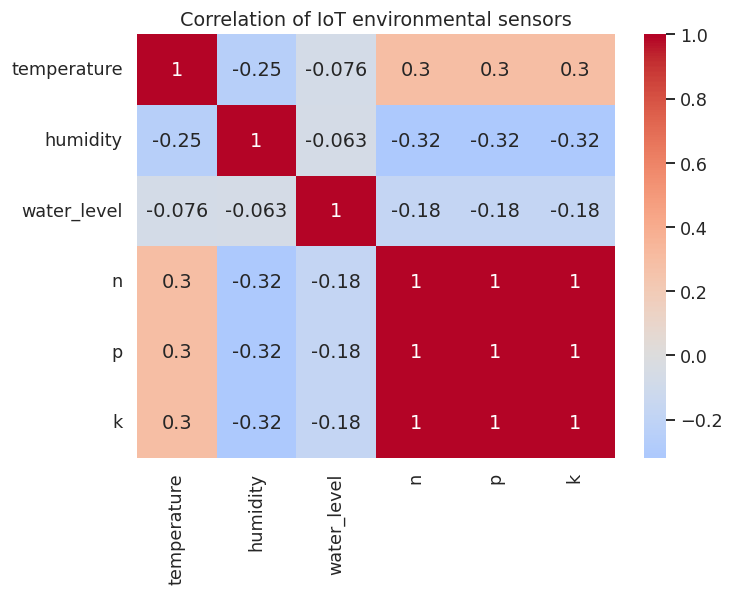

In [ ]:
# Correlation between environmental variables
plt.figure(figsize=(7, 5))
sns.heatmap(iot_df[["temperature", "humidity", "water_level", "n", "p", "k"]].corr(),
            annot=True, cmap="coolwarm", center=0)
plt.title("Correlation of IoT environmental sensors")
save_fig("iot_sensor_correlation")
plt.show()

# SECTION 3 — Advanced IoT Agriculture 2024

30,000 rows × 14 columns of **plant phenotype measurements** captured in
IoT vs traditional greenhouses (chlorophyll, root length, leaf area, dry/wet
weights …) labelled with a `Class` indicating growth/treatment group.
A perfect supplement that lets us model **plant health classification**.

In [ ]:
# CELL 13: Load Advanced IoT Agriculture 2024
!kaggle datasets download -d wisam1985/advanced-iot-agriculture-2024 -p {DATA_DIR} --unzip -q

adv_csv = next(DATA_DIR.glob("Advanced*IoT*Dataset*.csv"), None) \
       or next(DATA_DIR.glob("*Advanced*.csv"), None)
print("Loaded:", adv_csv)

adv_df = pd.read_csv(adv_csv)
adv_df.columns = [c.strip() for c in adv_df.columns]
print("Shape:", adv_df.shape)
print("\nColumns:"); print(list(adv_df.columns))
print("\nFirst rows:"); print(adv_df.head())
print("\nClass distribution:"); print(adv_df["Class"].value_counts())
print("\nDescribe:"); print(adv_df.describe().T.round(3))

Dataset URL: https://www.kaggle.com/datasets/wisam1985/advanced-iot-agriculture-2024
License(s): Attribution-NoDerivatives 4.0 International (CC BY-ND 4.0)
Loaded: /content/data/Advanced_IoT_Dataset.csv
Shape: (30000, 14)

Columns:
['Random', 'Average  of chlorophyll in the plant (ACHP)', 'Plant height rate (PHR)', 'Average wet weight of the growth vegetative (AWWGV)', 'Average leaf area of the plant (ALAP)', 'Average number of plant leaves (ANPL)', 'Average root diameter (ARD)', 'Average dry weight of the root (ADWR)', 'Percentage of dry matter for vegetative growth (PDMVG)', 'Average root length (ARL)', 'Average wet weight of the root (AWWR)', 'Average dry weight of vegetative plants (ADWV)', 'Percentage of dry matter for root growth (PDMRG)', 'Class']

First rows:
  Random  Average  of chlorophyll in the plant (ACHP)  \
0     R1                                    34.533468   
1     R1                                    34.489028   
2     R2                                    33.1004

   💾 Saved → /content/figures/figure_12_adv_class_distribution.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

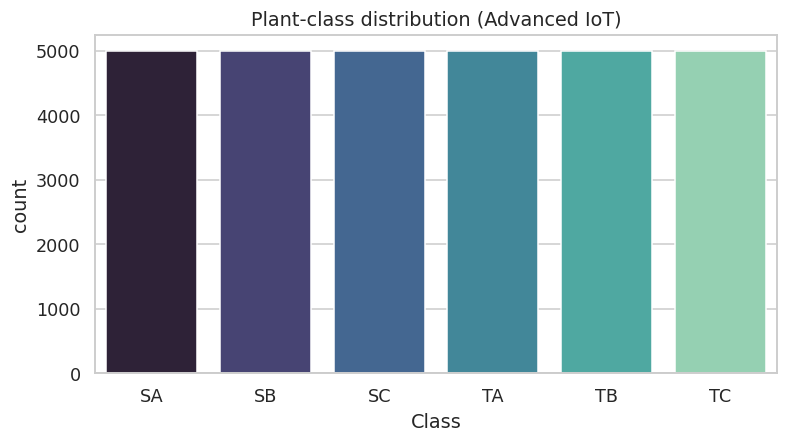

In [ ]:
# CELL 14: Visualisations for Advanced IoT Agriculture 2024
numeric_cols_adv = adv_df.select_dtypes(include=np.number).columns.tolist()

# Class distribution
plt.figure(figsize=(8, 4))
sns.countplot(data=adv_df, x="Class", palette="mako",
              order=adv_df["Class"].value_counts().index)
plt.title("Plant-class distribution (Advanced IoT)")
save_fig("adv_class_distribution")
plt.show()


   💾 Saved → /content/figures/figure_13_adv_phenotype_correlation.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

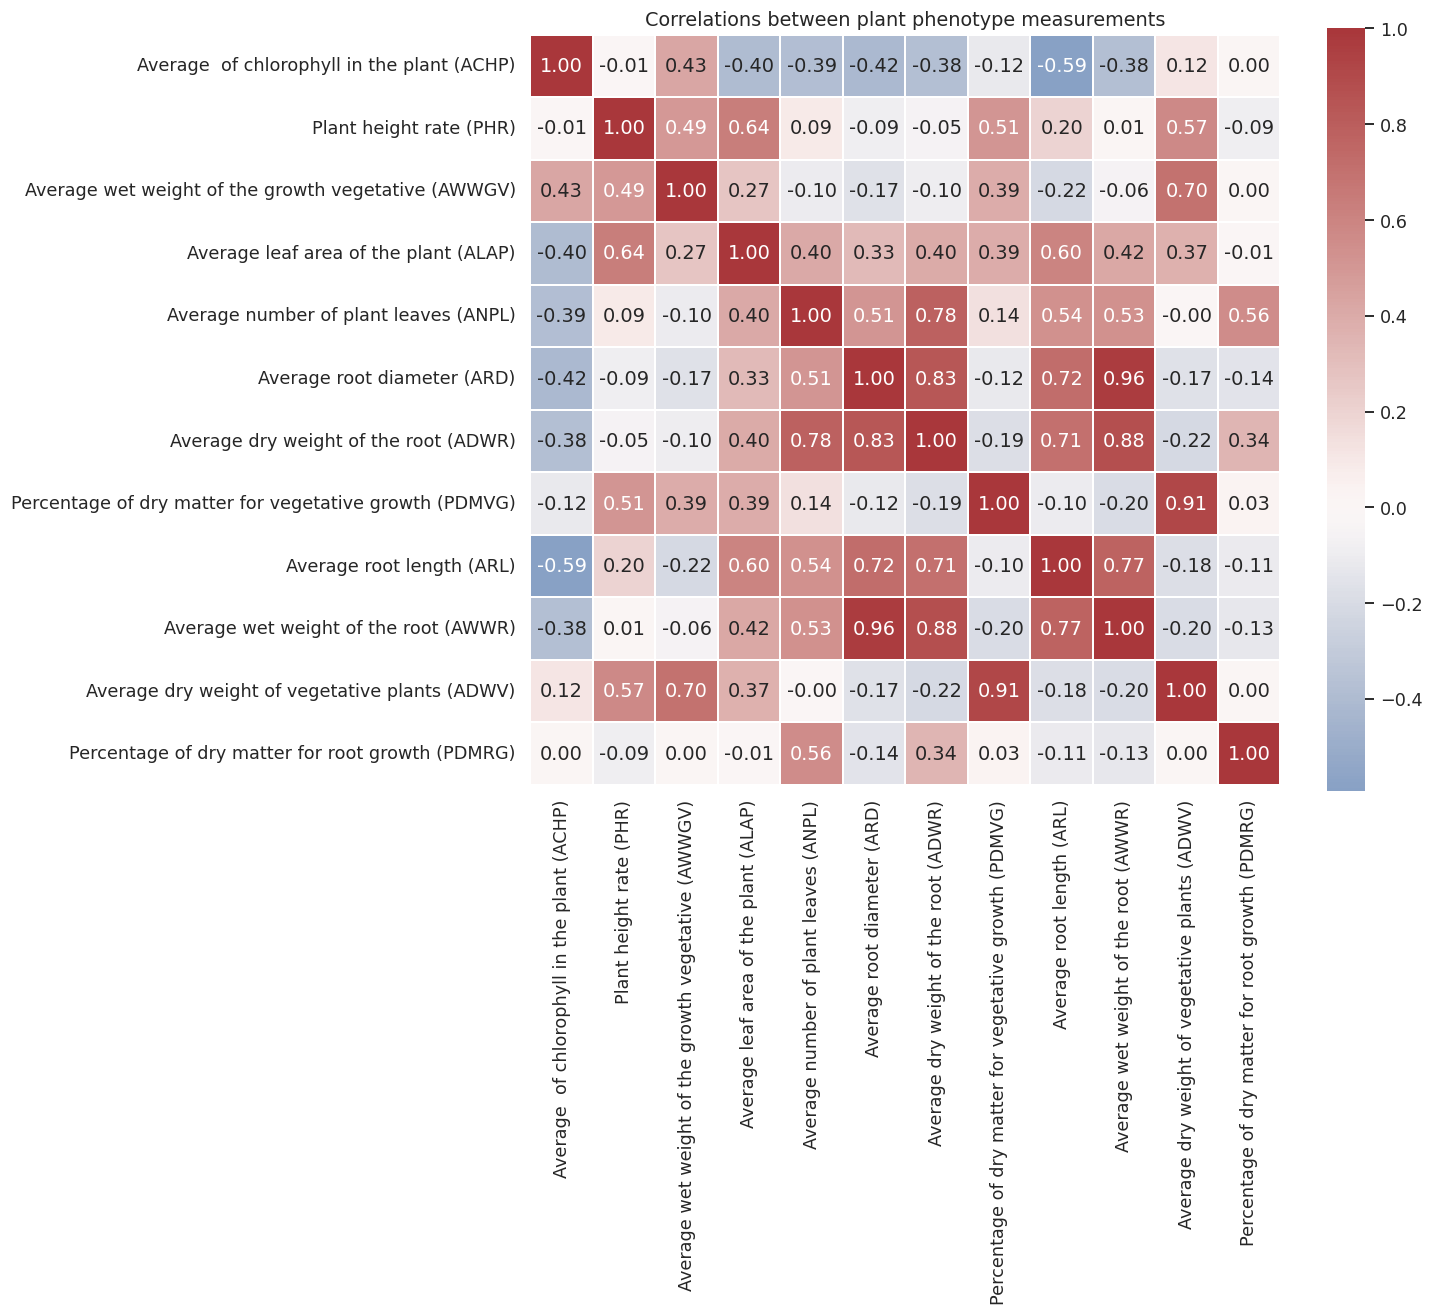

In [ ]:

# Correlation matrix of phenotype features
plt.figure(figsize=(11, 9))
sns.heatmap(adv_df[numeric_cols_adv].corr(), annot=True, fmt=".2f",
            cmap="vlag", center=0, square=True, linewidths=0.3)
plt.title("Correlations between plant phenotype measurements")
save_fig("adv_phenotype_correlation")
plt.show()

   💾 Saved → /content/figures/figure_14_adv_features_by_class.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

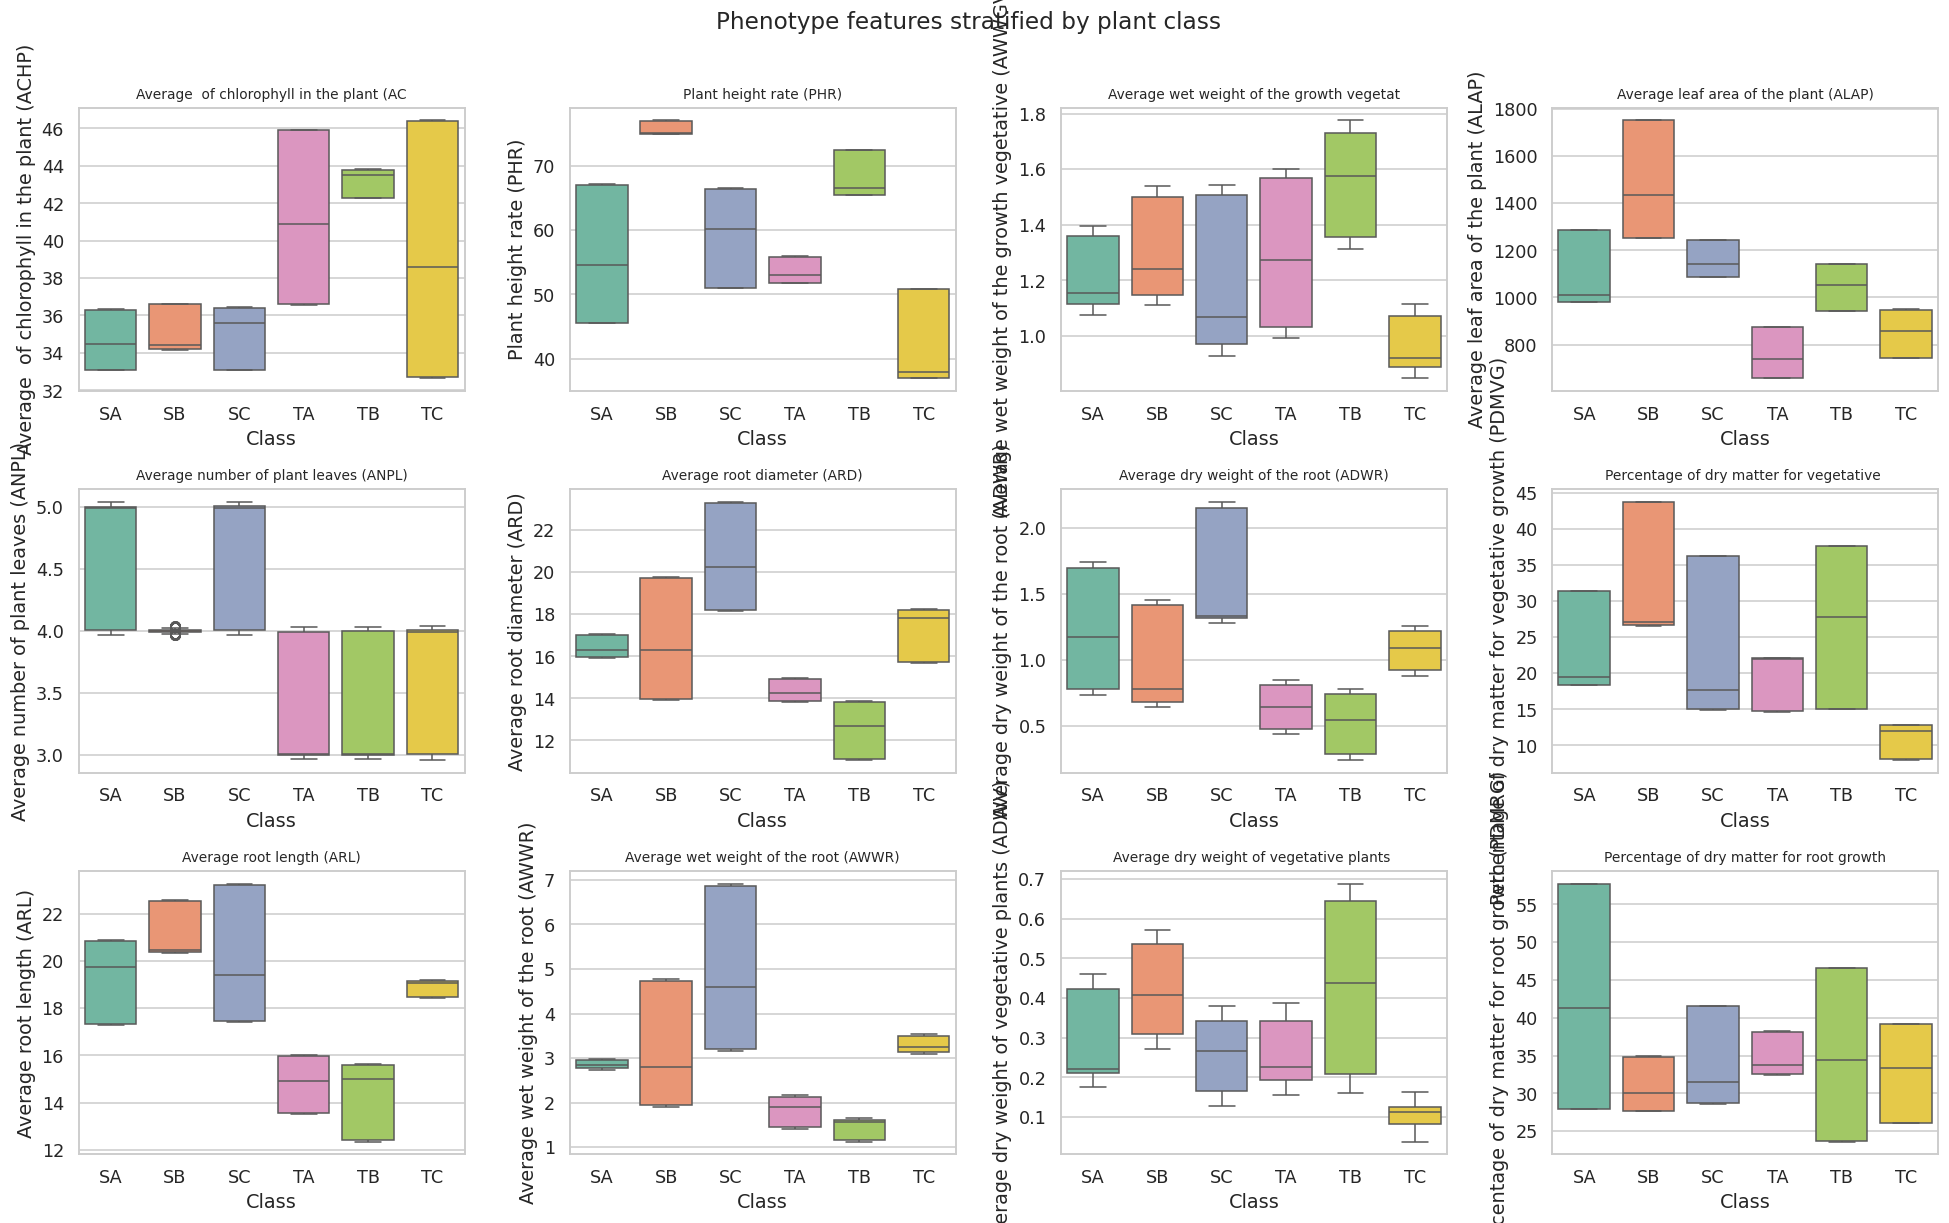

In [ ]:
# Boxplots of every feature by Class
fig, axes = plt.subplots(3, 4, figsize=(18, 11))
for ax, col in zip(axes.flat, numeric_cols_adv):
    sns.boxplot(data=adv_df, x="Class", y=col, ax=ax, palette="Set2")
    ax.set_title(col[:40], fontsize=9)
plt.suptitle("Phenotype features stratified by plant class", y=1.01)
plt.tight_layout()
save_fig("adv_features_by_class")
plt.show()

   💾 Saved → /content/figures/figure_15_adv_pca_2d.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

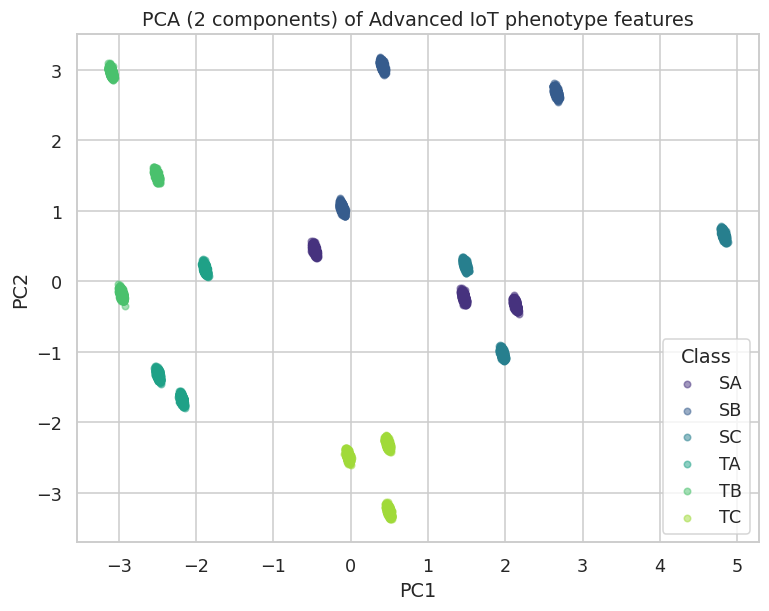

In [ ]:
# PCA projection to 2-D coloured by Class
from sklearn.decomposition import PCA
X_adv = adv_df[numeric_cols_adv].values
X_scaled = StandardScaler().fit_transform(X_adv)
pcs = PCA(n_components=2, random_state=SEED).fit_transform(X_scaled)
plt.figure(figsize=(8, 6))
for cls in adv_df["Class"].unique():
    m = adv_df["Class"] == cls
    plt.scatter(pcs[m, 0], pcs[m, 1], alpha=0.5, label=cls, s=18)
plt.legend(title="Class")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("PCA (2 components) of Advanced IoT phenotype features")
save_fig("adv_pca_2d")
plt.show()

# SECTION 4 — Smart Agriculture Dataset (Kaggle)

16,411 rows × 7 columns. Schema:
`crop ID, soil_type, Seedling Stage, MOI, temp, humidity, result`
where `result` is a **binary irrigation decision** (1 = irrigate, 0 = no).
We will use it for the **irrigation-need classifier**.

In [ ]:
# CELL 16: Load Smart Agriculture Dataset
!kaggle datasets download -d chaitanyagopidesi/smart-agriculture-dataset -p {DATA_DIR} --unzip -q

smart_csv = next(DATA_DIR.glob("*smart*agric*.csv"), None) \
         or next(DATA_DIR.glob("*Smart*Agric*.csv"), None) \
         or next((p for p in DATA_DIR.glob("*.csv")
                  if "result" in pd.read_csv(p, nrows=1).columns.str.lower().tolist()), None)
print("Loaded:", smart_csv)

smart_df = pd.read_csv(smart_csv)
smart_df.columns = [c.strip().lower().replace(" ", "_") for c in smart_df.columns]
print("Shape   :", smart_df.shape)
print("Columns :", list(smart_df.columns))
print(smart_df.head())
print("\nIrrigation result balance:")
print(smart_df["result"].value_counts(normalize=True).round(3))

Dataset URL: https://www.kaggle.com/datasets/chaitanyagopidesi/smart-agriculture-dataset
License(s): apache-2.0
Loaded: /content/data/cropdata_updated.csv
Shape   : (16411, 7)
Columns : ['crop_id', 'soil_type', 'seedling_stage', 'moi', 'temp', 'humidity', 'result']
  crop_id   soil_type seedling_stage  moi  temp  humidity  result
0   Wheat  Black Soil    Germination    1    25      80.0       1
1   Wheat  Black Soil    Germination    2    26      77.0       1
2   Wheat  Black Soil    Germination    3    27      74.0       1
3   Wheat  Black Soil    Germination    4    28      71.0       1
4   Wheat  Black Soil    Germination    5    29      68.0       1

Irrigation result balance:
result
0    0.552
1    0.379
2    0.068
Name: proportion, dtype: float64


   💾 Saved → /content/figures/figure_16_smart_crop_frequency.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

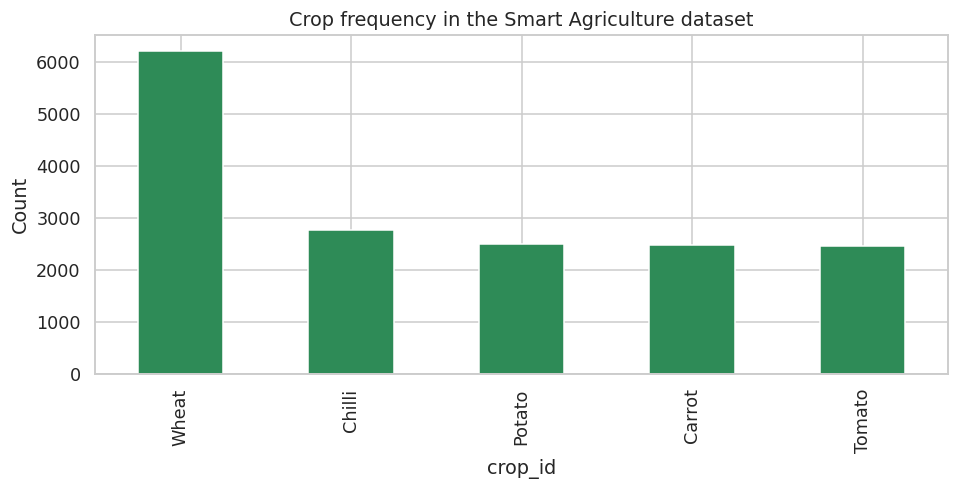

In [ ]:
# CELL 17: Visualisations for Smart Agriculture Dataset

# Crop frequency
plt.figure(figsize=(10, 4))
smart_df["crop_id"].value_counts().plot(kind="bar", color="seagreen")
plt.title("Crop frequency in the Smart Agriculture dataset")
plt.ylabel("Count")
save_fig("smart_crop_frequency")
plt.show()

   💾 Saved → /content/figures/figure_17_smart_irrigation_by_soil.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

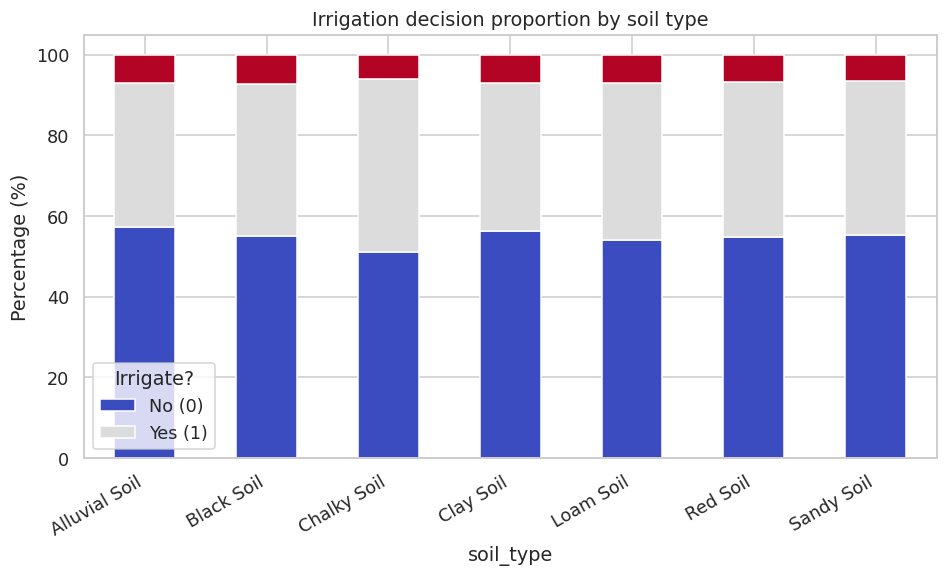

In [ ]:
# Irrigation decision by soil type
plt.figure(figsize=(10, 5))
ct = pd.crosstab(smart_df["soil_type"], smart_df["result"], normalize="index") * 100
ct.plot(kind="bar", stacked=True, colormap="coolwarm", ax=plt.gca())
plt.ylabel("Percentage (%)")
plt.title("Irrigation decision proportion by soil type")
plt.legend(title="Irrigate?", labels=["No (0)", "Yes (1)"])
plt.xticks(rotation=30, ha="right")
save_fig("smart_irrigation_by_soil")
plt.show()


   💾 Saved → /content/figures/figure_18_smart_moi_temp_scatter.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

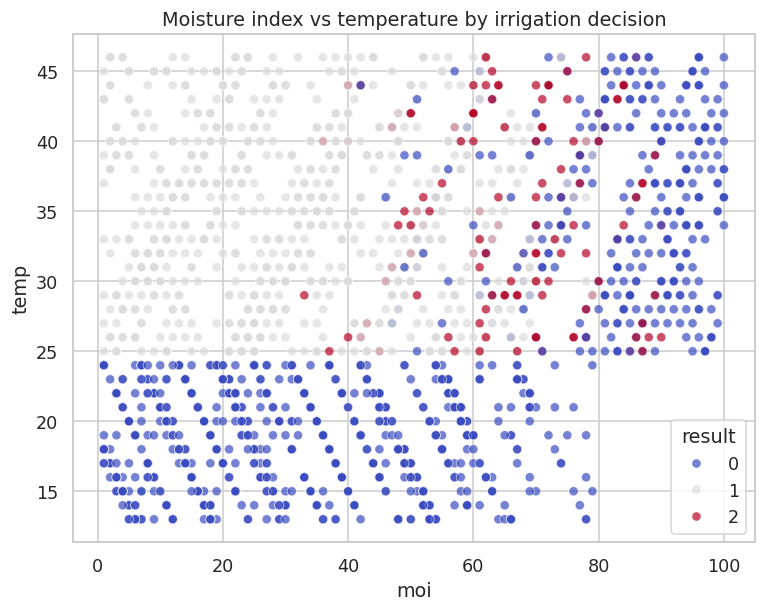

In [ ]:

# Moisture index vs temperature, coloured by irrigation decision
plt.figure(figsize=(8, 6))
sns.scatterplot(data=smart_df.sample(2000, random_state=SEED),
                x="moi", y="temp", hue="result", palette="coolwarm", alpha=0.7)
plt.title("Moisture index vs temperature by irrigation decision")
save_fig("smart_moi_temp_scatter")
plt.show()

   💾 Saved → /content/figures/figure_19_smart_irrigation_by_stage.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

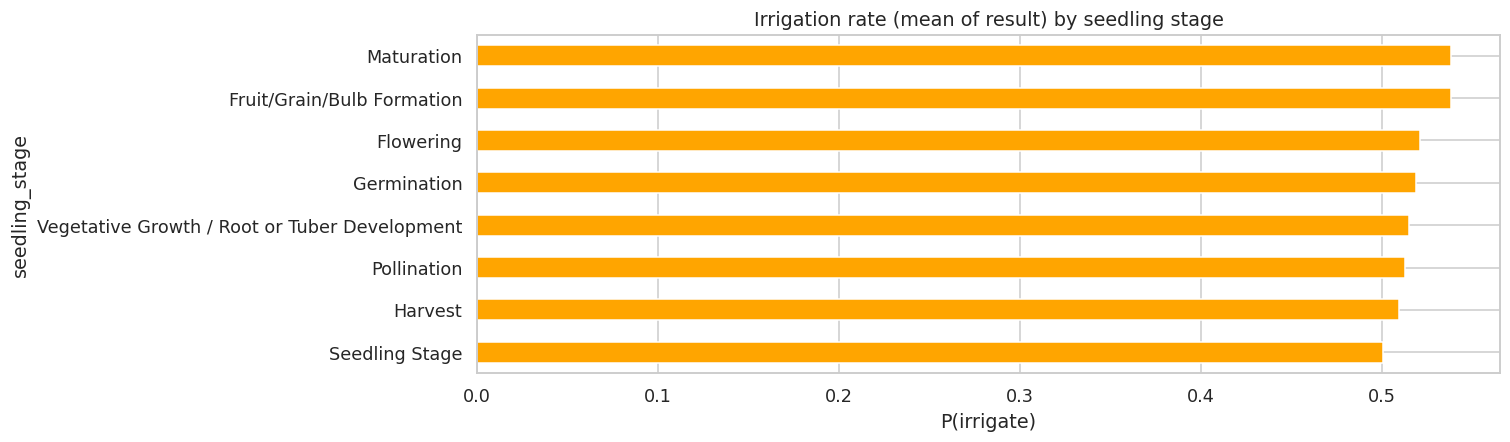

In [ ]:
# Irrigation rate by seedling stage
plt.figure(figsize=(12, 4))
stage_rate = smart_df.groupby("seedling_stage")["result"].mean().sort_values()
stage_rate.plot(kind="barh", color="orange")
plt.title("Irrigation rate (mean of result) by seedling stage")
plt.xlabel("P(irrigate)")
save_fig("smart_irrigation_by_stage")
plt.show()

# SECTION 5 — HarvestStat Africa: Nigeria Crop Statistics

574,204 records for 33 countries. We restrict to **Nigeria** and explore by
crop, year, and state (`admin_1`). All column references are discovered
dynamically, so the code will adapt to any future schema tweak.

In [ ]:
# # CELL 19: Download HarvestStat Africa from Dryad
# # The main harmonised CSV is ~23 MB. We pull it once and cache it locally.

# HVSTAT_URL = "https://github.com/HarvestStat/HarvestStat-Africa/raw/main/public/hvstat_africa_data_v1.0.csv"   # hvstat_africa_data_v1.0.csv
# HVSTAT_PATH = DATA_DIR / "hvstat_africa_data_v1.0.csv"

# if not HVSTAT_PATH.exists():
#     print("Downloading HarvestStat Africa (≈ 23 MB)…")
#     r = requests.get(HVSTAT_URL, stream=True, timeout=120)
#     r.raise_for_status()
#     with open(HVSTAT_PATH, "wb") as f:
#         for chunk in r.iter_content(chunk_size=1 << 20):
#             f.write(chunk)
# print("Saved:", HVSTAT_PATH, "  size:", HVSTAT_PATH.stat().st_size, "bytes")

hv_df = pd.read_csv("/content/adm_crop_data_raw_NG.csv", low_memory=False)
print("Full dataset shape:", hv_df.shape)
print("Columns:", list(hv_df.columns))
print("Countries available:", sorted(hv_df["country"].dropna().unique())[:10], "…")

# Restrict to Nigeria
ng_df = hv_df[hv_df["country"].str.lower() == "nigeria"].copy()
print("\nNigeria slice shape:", ng_df.shape)
print(ng_df.head())

Full dataset shape: (30530, 68)
Columns: ['Unnamed: 0', 'country', 'source_organization', 'source_document', 'geographic_unit_full_name', 'geographic_unit_name', 'fnid', 'admin_0', 'admin_1', 'admin_2', 'admin_3', 'admin_4', 'population_group', 'crop_production_system', 'start_date', 'period_date', 'season_name', 'season_type', 'season_date', 'season_year', 'planting_start_date', 'planting_end_date', 'harvest_start_date', 'harvest_end_date', 'vegetative_start_date', 'vegetative_end_date', 'reproductive_start_date', 'reproductive_end_date', 'document_type', 'preference_rating', 'indicator_group', 'indicator', 'status', 'value', 'population', 'value_per_capita', 'product', 'country_code', 'locality_name', 'unit', 'unit_name', 'cpcv2', 'cpcv2_description', 'geographic_group', 'fewsnet_region', 'id', 'datacollectionperiod', 'datacollection', 'datasourcedocument', 'datasourceorganization', 'indicator_abbreviation', 'locality', 'geographic_unit', 'season', 'dataseries', 'dataseries_name', 's

In [ ]:
ng_df

,Unnamed: 0,country,source_organization,source_document,geographic_unit_full_name,geographic_unit_name,fnid,admin_0,admin_1,admin_2,...,data_usage_policy,created,modified,status_changed,collection_status,collection_status_changed,collection_schedule,collection_date,publication_name,submitted_by
0,0,Nigeria,"NAERLS, Nigeria","Crop Area and Output Forecast, Nigeria","Abia, Nigeria",Abia,NG1996A101,Nigeria,Abia,NaN,...,Public,2024-04-11T16:39:05,2024-04-11T16:39:05,2024-04-11T16:51:25,Published,2024-04-17T19:47:48,Ad Hoc,2015-12-31,"2014_2015_Crop Area and Output Forecast, Nigeria",NaN
1,1,Nigeria,"NAERLS, Nigeria","Crop Area and Output Forecast, Nigeria","Abia, Nigeria",Abia,NG1996A101,Nigeria,Abia,NaN,...,Public,2024-04-11T16:42:36,2024-04-11T16:42:36,2024-04-11T16:51:37,Published,2024-04-17T19:47:48,Ad Hoc,2015-12-31,"2014_2015_Crop Area and Output Forecast, Nigeria",NaN
2,2,Nigeria,"NAERLS, Nigeria","Crop Area and Output Forecast, Nigeria","Abia, Nigeria",Abia,NG1996A101,Nigeria,Abia,NaN,...,Public,2024-04-11T16:38:49,2024-04-11T16:38:49,2024-04-11T16:51:25,Published,2024-04-17T19:47:48,Ad Hoc,2015-12-31,"2014_2015_Crop Area and Output Forecast, Nigeria",NaN
3,3,Nigeria,"NAERLS, Nigeria","Crop Area and Output Forecast, Nigeria","Abia, Nigeria",Abia,NG1996A101,Nigeria,Abia,NaN,...,Public,2024-04-11T16:42:00,2024-04-11T16:42:00,2024-04-11T16:51:30,Published,2024-04-17T19:47:49,Ad Hoc,2015-09-30,"2014_2015_Crop Area and Output Forecast, Nigeria",NaN
4,4,Nigeria,"NAERLS, Nigeria","Crop Area and Output Forecast, Nigeria","Abia, Nigeria",Abia,NG1996A101,Nigeria,Abia,NaN,...,Public,2024-04-11T16:41:46,2024-04-11T16:41:46,2024-04-11T16:51:30,Published,2024-04-17T19:47:49,Ad Hoc,2015-09-30,"2014_2015_Crop Area and Output Forecast, Nigeria",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30525,30525,Nigeria,"NAERLS, Nigeria","Wet-Season Agriculture Performance Survey, Nig...","Rivers, Nigeria",Rivers,NG1996A133,Nigeria,Rivers,NaN,...,Public,2024-04-11T16:40:32,2024-04-11T16:40:32,2024-04-11T16:51:30,Published,2024-04-17T19:47:49,Ad Hoc,2019-09-30,2020 Wet Season Agriculture Performance Survey...,NaN
30526,30526,Nigeria,"NAERLS, Nigeria","Wet-Season Agriculture Performance Survey, Nig...","Rivers, Nigeria",Rivers,NG1996A133,Nigeria,Rivers,NaN,...,Public,2024-04-11T16:39:46,2024-04-11T16:39:46,2024-04-11T16:51:25,Published,2024-04-17T19:47:49,Ad Hoc,2019-09-30,2020 Wet Season Agriculture Performance Survey...,NaN
30527,30527,Nigeria,"NAERLS, Nigeria","Wet-Season Agriculture Performance Survey, Nig...","Rivers, Nigeria",Rivers,NG1996A133,Nigeria,Rivers,NaN,...,Public,2024-04-11T16:38:58,2024-04-11T16:38:58,2024-04-11T16:51:25,Published,2024-04-17T19:47:48,Ad Hoc,2018-12-31,2018 Wet Season Agriculture Performance Survey...,NaN
30528,30528,Nigeria,"NAERLS, Nigeria","Wet-Season Agriculture Performance Survey, Nig...","Rivers, Nigeria",Rivers,NG1996A133,Nigeria,Rivers,NaN,...,Public,2024-04-11T16:39:14,2024-04-11T16:39:14,2024-04-11T16:51:25,Published,2024-04-17T19:47:48,Ad Hoc,2018-12-31,2018 Wet Season Agriculture Performance Survey...,NaN


In [ ]:
ng_df.columns

Index(['Unnamed: 0', 'country', 'source_organization', 'source_document',
       'geographic_unit_full_name', 'geographic_unit_name', 'fnid', 'admin_0',
       'admin_1', 'admin_2', 'admin_3', 'admin_4', 'population_group',
       'crop_production_system', 'start_date', 'period_date', 'season_name',
       'season_type', 'season_date', 'season_year', 'planting_start_date',
       'planting_end_date', 'harvest_start_date', 'harvest_end_date',
       'vegetative_start_date', 'vegetative_end_date',
       'reproductive_start_date', 'reproductive_end_date', 'document_type',
       'preference_rating', 'indicator_group', 'indicator', 'status', 'value',
       'population', 'value_per_capita', 'product', 'country_code',
       'locality_name', 'unit', 'unit_name', 'cpcv2', 'cpcv2_description',
       'geographic_group', 'fewsnet_region', 'id', 'datacollectionperiod',
       'datacollection', 'datasourcedocument', 'datasourceorganization',
       'indicator_abbreviation', 'locality', 'geograp

In [ ]:
# CELL 20: Auto-discover columns; profile crops, states, years
# Detect schema columns flexibly
def first_existing(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

col_state    = first_existing(ng_df, ["admin_1"])
col_crop     = first_existing(ng_df, ["product", "crop", "indicator"])
col_year     = first_existing(ng_df, ["harvest_year", "planting_year", "season_year"])
col_area     = first_existing(ng_df, ["area"])
col_prod     = first_existing(ng_df, ["production", "value"])
col_yield    = first_existing(ng_df, ["yield"])

print("Detected schema columns:")
print(f"  state  = {col_state}")
print(f"  crop   = {col_crop}")
print(f"  year   = {col_year}")
print(f"  area   = {col_area}")
print(f"  prod   = {col_prod}")
print(f"  yield  = {col_yield}")


Detected schema columns:
  state  = admin_1
  crop   = product
  year   = season_year
  area   = None
  prod   = value
  yield  = None


In [ ]:
# Parse year if needed
if col_year and ng_df[col_year].dtype == object:
    ng_df[col_year] = pd.to_numeric(ng_df[col_year].str.extract(r"(\d{4})")[0],
                                    errors="coerce")

# Basic profile
print("\nNumber of unique states :", ng_df[col_state].nunique() if col_state else "n/a")
print("Number of unique crops  :", ng_df[col_crop].nunique() if col_crop else "n/a")
if col_year:
    print("Year range              :",
          int(ng_df[col_year].min()), "→", int(ng_df[col_year].max()))

print("\nTop 15 states by record count:")
print(ng_df[col_state].value_counts().head(15))
print("\nTop 15 crops by record count:")
print(ng_df[col_crop].value_counts().head(15))


Number of unique states : 37
Number of unique crops  : 21
Year range              : 1999 → 2023

Top 15 states by record count:
admin_1
Nasarawa    1068
Benue       1032
Plateau     1026
Kaduna      1020
Bauchi      1011
Niger        993
Adamawa      993
Kogi         984
Katsina      969
Kwara        966
Gombe        963
Kebbi        939
Kano         930
Oyo          924
Jigawa       912
Name: count, dtype: int64

Top 15 crops by record count:
product
Maize (Corn)                  2552
Rice (Paddy)                  2522
Cowpea (unspecified)          2429
Cassava                       2409
Groundnuts (In Shell)         2295
Yams                          2174
Taro/Cocoyam (Unspecified)    1924
Sorghum                       1907
Millet                        1865
Soybean (unspecified)         1707
Cotton (Unspecified)          1347
Sesame Seed                   1263
Tomato                        1236
Sweet Potatoes                1122
Okras (Fresh)                 1086
Name: count, dtype

   💾 Saved → /content/figures/figure_20_hv_records_by_state.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

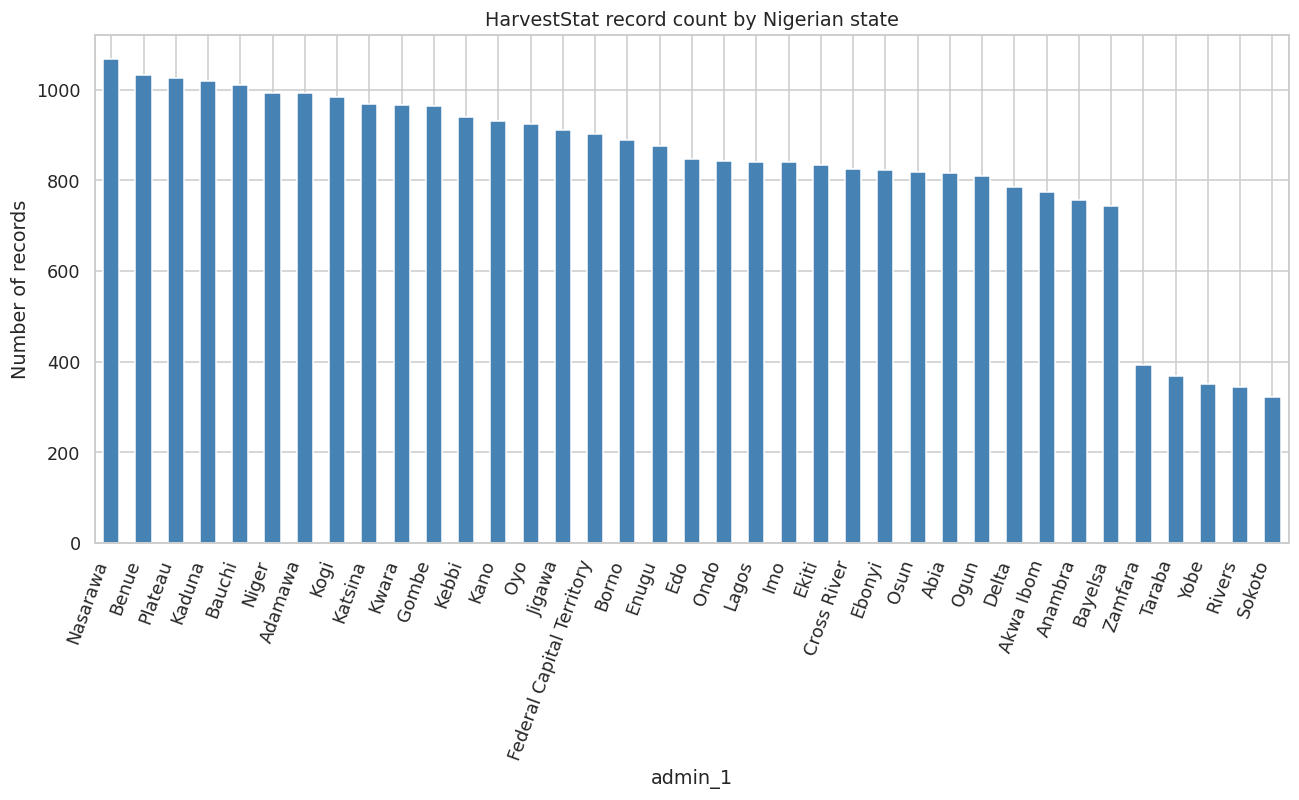

In [ ]:
# CELL 21: State- and crop-level visualisations for Nigeria
# We always iterate dynamically over the discovered columns.

# Records per Nigerian state
plt.figure(figsize=(14, 6))
ng_df[col_state].value_counts().plot(kind="bar", color="steelblue")
plt.title("HarvestStat record count by Nigerian state")
plt.ylabel("Number of records")
plt.xticks(rotation=70, ha="right")
save_fig("hv_records_by_state")
plt.show()

   💾 Saved → /content/figures/figure_21_hv_top_crops_nigeria.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

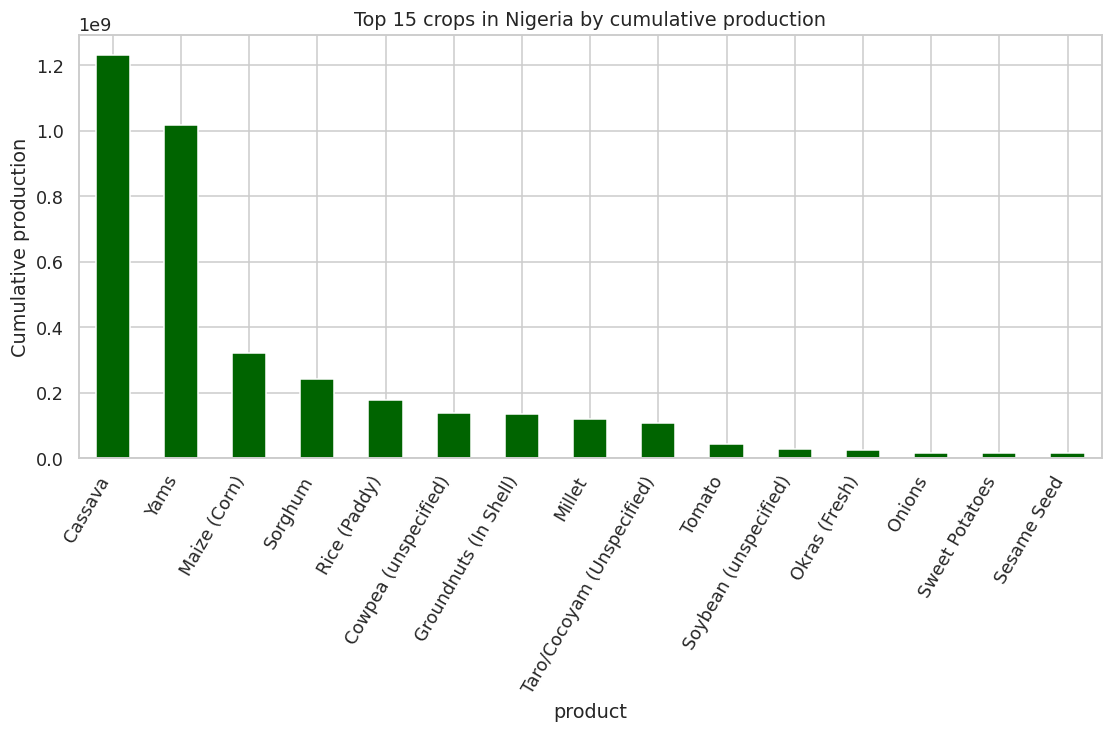

In [ ]:

# Top 15 crops nationally by total production
if col_prod:
    plt.figure(figsize=(12, 5))
    top_crops = (ng_df.groupby(col_crop)[col_prod].sum()
                       .sort_values(ascending=False).head(15))
    top_crops.plot(kind="bar", color="darkgreen")
    plt.title("Top 15 crops in Nigeria by cumulative production")
    plt.ylabel("Cumulative production")
    plt.xticks(rotation=60, ha="right")
    save_fig("hv_top_crops_nigeria")
    plt.show()

   💾 Saved → /content/figures/figure_22_hv_yearly_trend_top5.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

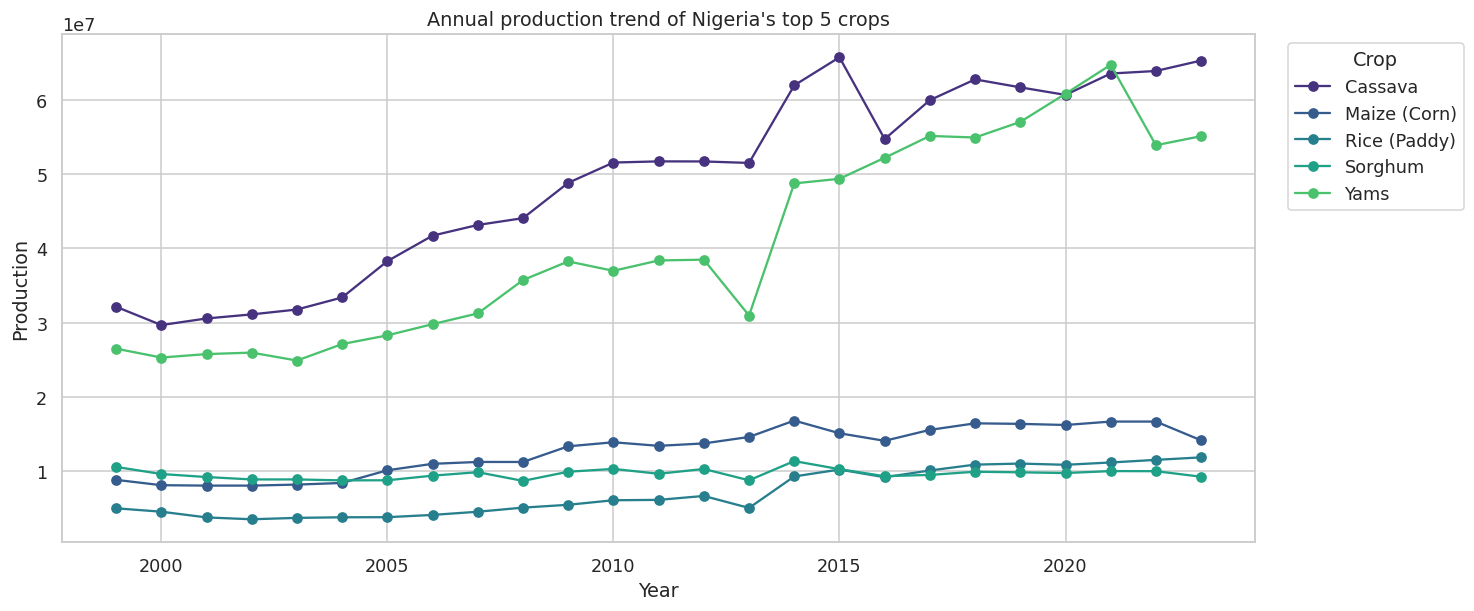

In [ ]:
# Yearly production trend for the top 5 crops
if col_year and col_prod:
    top5 = (ng_df.groupby(col_crop)[col_prod].sum()
                  .sort_values(ascending=False).head(5).index)
    trend = (ng_df[ng_df[col_crop].isin(top5)]
             .groupby([col_year, col_crop])[col_prod].sum()
             .unstack(col_crop))
    plt.figure(figsize=(14, 6))
    trend.plot(ax=plt.gca(), marker="o")
    plt.title("Annual production trend of Nigeria's top 5 crops")
    plt.ylabel("Production"); plt.xlabel("Year")
    plt.legend(title="Crop", bbox_to_anchor=(1.02, 1), loc="upper left")
    save_fig("hv_yearly_trend_top5")
    plt.show()

   💾 Saved → /content/figures/figure_23_hv_state_crop_heatmap.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

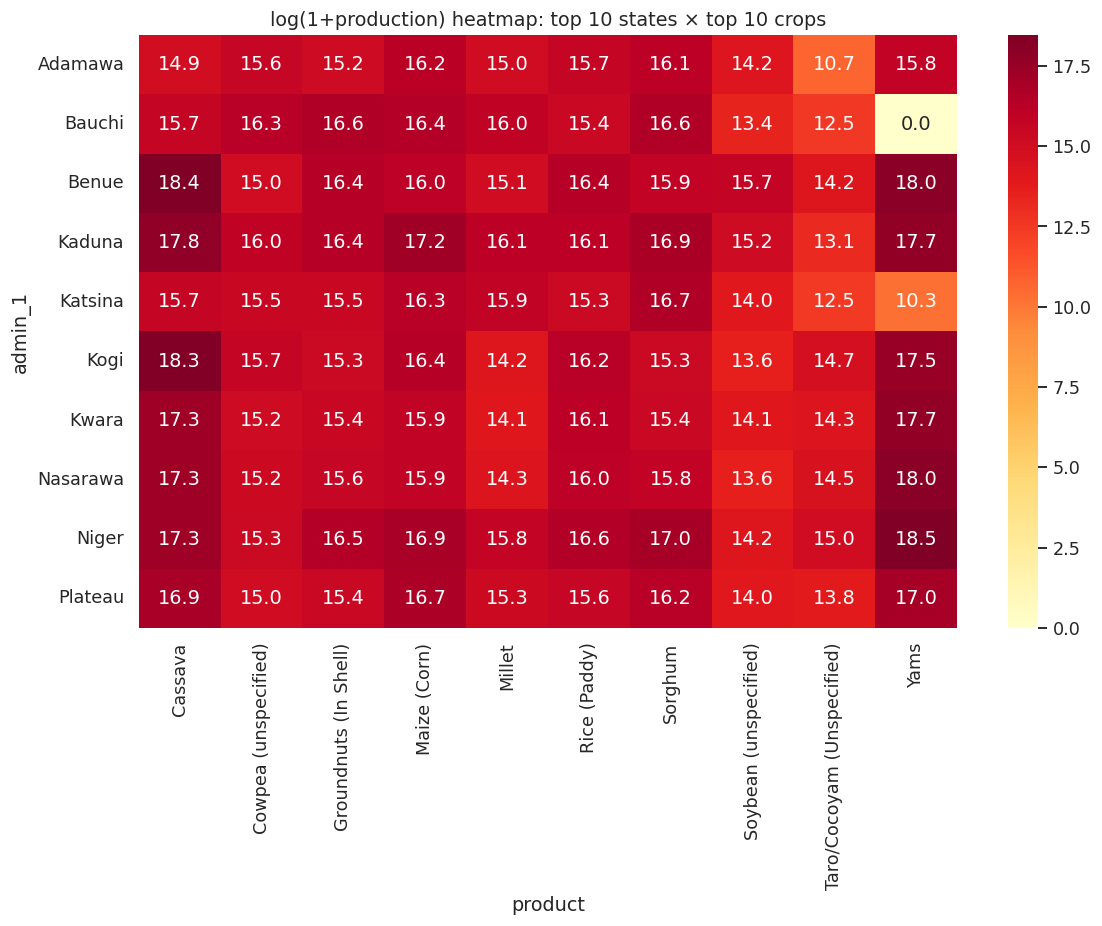

In [ ]:
# State × Crop heatmap (top 10 states × top 10 crops)
if col_prod:
    top_states = ng_df[col_state].value_counts().head(10).index
    top_crops10 = ng_df[col_crop].value_counts().head(10).index
    pivot = (ng_df[ng_df[col_state].isin(top_states) &
                   ng_df[col_crop].isin(top_crops10)]
             .pivot_table(index=col_state, columns=col_crop,
                          values=col_prod, aggfunc="sum", fill_value=0))
    plt.figure(figsize=(12, 7))
    sns.heatmap(np.log1p(pivot), annot=True, fmt=".1f", cmap="YlOrRd")
    plt.title("log(1+production) heatmap: top 10 states × top 10 crops")
    save_fig("hv_state_crop_heatmap")
    plt.show()

Average cumulative production per state for the most recent year on record:
  Niger                      10729348.220
  Benue                      10535411.130
  Nasarawa                   9118839.830
  Kaduna                     8942051.740
  Kogi                       8645903.910
  Federal Capital Territory  7870704.020
  Ondo                       7053199.880
  Cross River                6676455.720
  Kwara                      6620368.740
  Enugu                      6548411.090
  Plateau                    5802667.110
  Edo                        5764370.420
  Osun                       5721847.510
  Akwa Ibom                  5212252.010
  Abia                       5128476.380
  Oyo                        5033933.130
  Imo                        4992254.310
  Ekiti                      4889752.450
  Bauchi                     4824677.320
  Ebonyi                     4506121.280
  Gombe                      4417653.190
  Kebbi                      4403588.250
  Anambra           

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

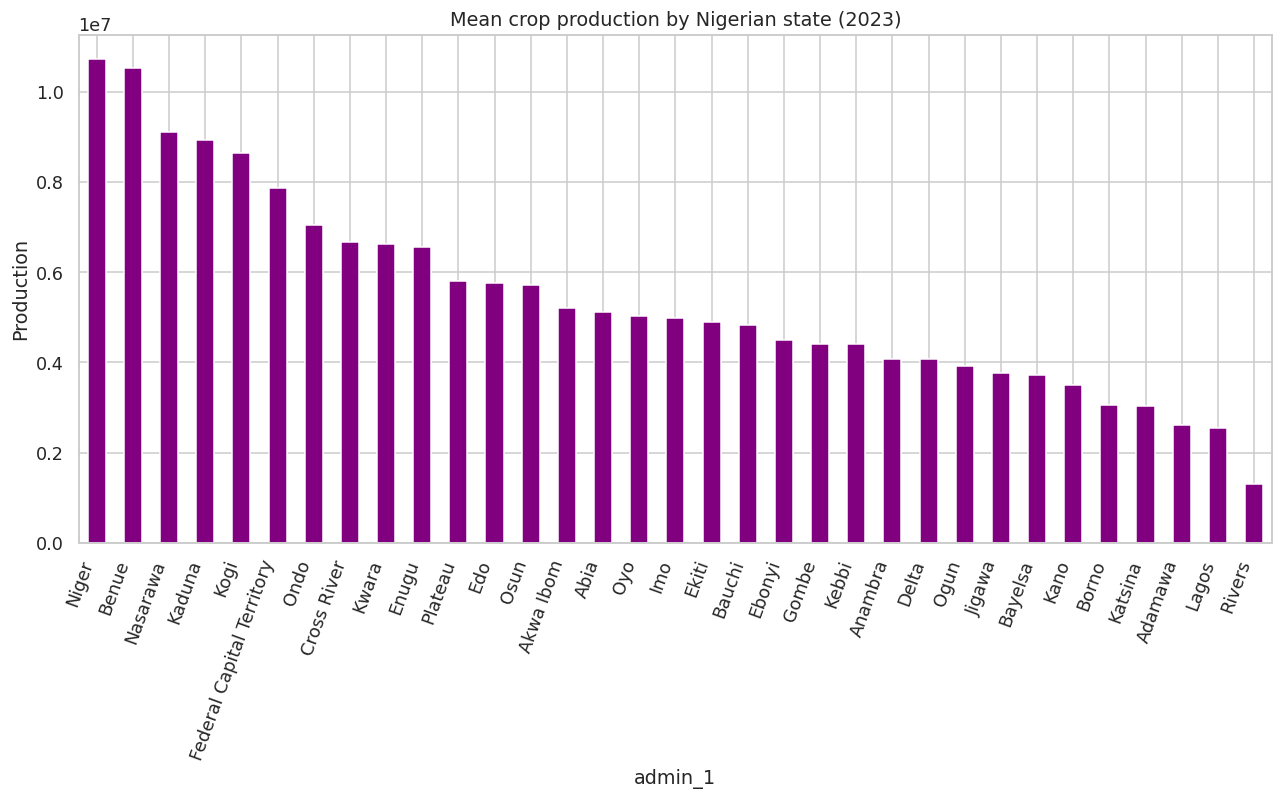

In [ ]:
# CELL 22: Loop over every state and emit a one-line production summary
# (kept brief on stdout — the printout itself is research evidence)
if col_prod:
  print("Average cumulative production per state for the most recent year on record:")
  latest_year = ng_df[col_year].max()
  state_summary = (ng_df[ng_df[col_year] == latest_year]
                    .groupby(col_state)[col_prod].sum() # Changed from col_yield to col_prod, and mean() to sum()
                    .dropna().sort_values(ascending=False))
  for state, val in state_summary.items():
      print(f"  {state:<25s}  {val:>8.3f}")

  # Bar chart of latest-year average production by state
  plt.figure(figsize=(14, 6))
  state_summary.plot(kind="bar", color="purple")
  plt.title(f"Mean crop production by Nigerian state ({int(latest_year)})") # Updated title
  plt.ylabel("Production") # Updated label
  plt.xticks(rotation=70, ha="right")
  save_fig("hv_state_production_latest") # Updated figure name
  plt.show()
else:
    print("Neither 'yield' nor 'production' columns were found. Cannot display summary.")

# SECTION 6 — Nigeria Digital Soil Map (Mendeley)

ESRI shapefile with **58 soil mapping units** across Nigeria's three ecological
zones. We load it with GeoPandas, inspect attributes (soil texture, pH, drainage,
major crops), and render the choropleth. This dataset is **geographic context**,
not training data — it lets us map model predictions back to real Nigerian soils.

In [ ]:
# CELL 24: Upload and read the shapefile bundle
# The shapefile is a SET of files: .shp .shx .dbf .prj .sbn .sbx .shp.xml
# Upload them ALL together (or upload a .zip you've prepared).

print("⬆️  Please upload ALL the shapefile companion files for 'soil types'")
print("    (soil_types.shp, .shx, .dbf, .prj, .sbn, .sbx, .shp.xml)")
print("    or a single ZIP containing them.")
if IN_COLAB:
    uploaded = files.upload()
    for name in uploaded:
        if name.endswith(".zip"):
            with zipfile.ZipFile(name) as z:
                z.extractall(DATA_DIR / "nigeria_soil")
        else:
            (DATA_DIR / "nigeria_soil").mkdir(exist_ok=True)
            os.replace(name, DATA_DIR / "nigeria_soil" / name)

# Locate the .shp
shp_path = next((DATA_DIR / "nigeria_soil").rglob("*.shp"), None) \
        or next(Path("/content").rglob("*.shp"), None)
print("Found shapefile:", shp_path)

soil_gdf = gpd.read_file(shp_path)
print("CRS         :", soil_gdf.crs)
print("Shape       :", soil_gdf.shape)
print("Columns     :", list(soil_gdf.columns))
print(soil_gdf.head())

⬆️  Please upload ALL the shapefile companion files for 'soil types'
    (soil_types.shp, .shx, .dbf, .prj, .sbn, .sbx, .shp.xml)
    or a single ZIP containing them.


Saving soil types.dbf to soil types.dbf
Saving soil types.prj to soil types.prj
Saving soil types.sbn to soil types.sbn
Saving soil types.sbx to soil types.sbx
Saving soil types.shp to soil types.shp
Saving soil types.shp.xml to soil types.shp.xml
Saving soil types.shx to soil types.shx
Found shapefile: /content/data/nigeria_soil/soil types.shp
CRS         : GEOGCS["GCS_Assumed_Geographic_1 (deprecated)",DATUM["North_American_Datum_1927",SPHEROID["Clarke 1866",6378206.4,294.978698213898,AUTHORITY["EPSG","7008"]],AUTHORITY["EPSG","6267"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["ESRI","104000"]]
Shape       : (658, 18)
Columns     : ['ID', 'MAPPING_UN', 'GEOLOGY', 'SLOPE', 'ECOLOGICAL', 'DRAINAGE', 'SOIL_PH', 'PH_DESCRIP', 'SUITABILIT', 'SOIL_TEXTU', 'SOIL_CLASS', 'VEGETATION', 'DISTRIBUTI', 'SOIL_CLA_1', 'PERCENTAGE', 'MAJOR_CROP', 'Depth', 'geometry']
   ID MAPPING

In [ ]:
# CELL 25: Profile the soil attribute table
print("Unique soil textures :", soil_gdf["SOIL_TEXTU"].nunique() if "SOIL_TEXTU" in soil_gdf else "n/a")
print("Unique ecological zones:", soil_gdf["ECOLOGICAL"].nunique() if "ECOLOGICAL" in soil_gdf else "n/a")
print("Unique drainage types  :", soil_gdf["DRAINAGE"].nunique()   if "DRAINAGE"   in soil_gdf else "n/a")

# Convert pH range strings like "5.9 - 4.9" to a midpoint numeric column
def parse_ph(s):
    try:
        parts = [float(x.strip()) for x in str(s).replace("–", "-").split("-")]
        return sum(parts) / len(parts) if parts else np.nan
    except Exception:
        return np.nan

if "SOIL_PH" in soil_gdf.columns:
    soil_gdf["ph_mid"] = soil_gdf["SOIL_PH"].apply(parse_ph)
    print("\npH midpoint stats:", soil_gdf["ph_mid"].describe().round(2).to_dict())

Unique soil textures : 8
Unique ecological zones: 4
Unique drainage types  : 5

pH midpoint stats: {'count': 651.0, 'mean': 5.95, 'std': 0.89, 'min': 4.05, '25%': 5.4, '50%': 5.85, '75%': 6.3, 'max': 8.8}


In [ ]:
soil_gdf.columns

Index(['ID', 'MAPPING_UN', 'GEOLOGY', 'SLOPE', 'ECOLOGICAL', 'DRAINAGE',
       'SOIL_PH', 'PH_DESCRIP', 'SUITABILIT', 'SOIL_TEXTU', 'SOIL_CLASS',
       'VEGETATION', 'DISTRIBUTI', 'SOIL_CLA_1', 'PERCENTAGE', 'MAJOR_CROP',
       'Depth', 'geometry', 'ph_mid'],
      dtype='object')

   💾 Saved → /content/figures/figure_25_soil_ecological_zones_map.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

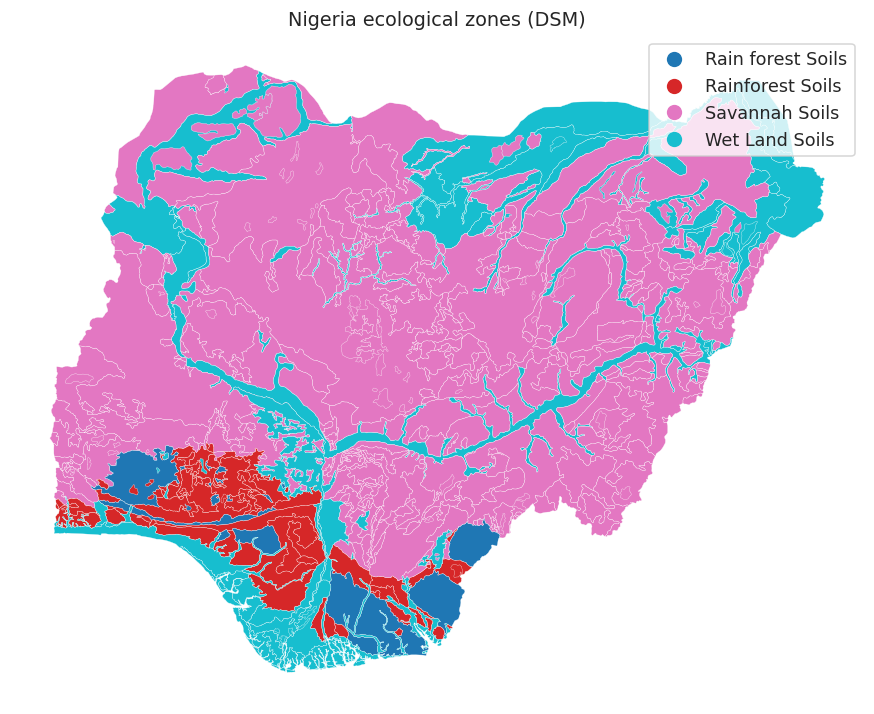

In [ ]:
# CELL 26: Choropleth + categorical maps

# Ecological zones map
plt.figure(figsize=(10, 9))
soil_gdf.plot(column="ECOLOGICAL", legend=True, cmap="tab10",
              edgecolor="white", linewidth=0.2, ax=plt.gca())
plt.title("Nigeria ecological zones (DSM)")
plt.axis("off")
save_fig("soil_ecological_zones_map")
plt.show()

   💾 Saved → /content/figures/figure_26_soil_ph_choropleth.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

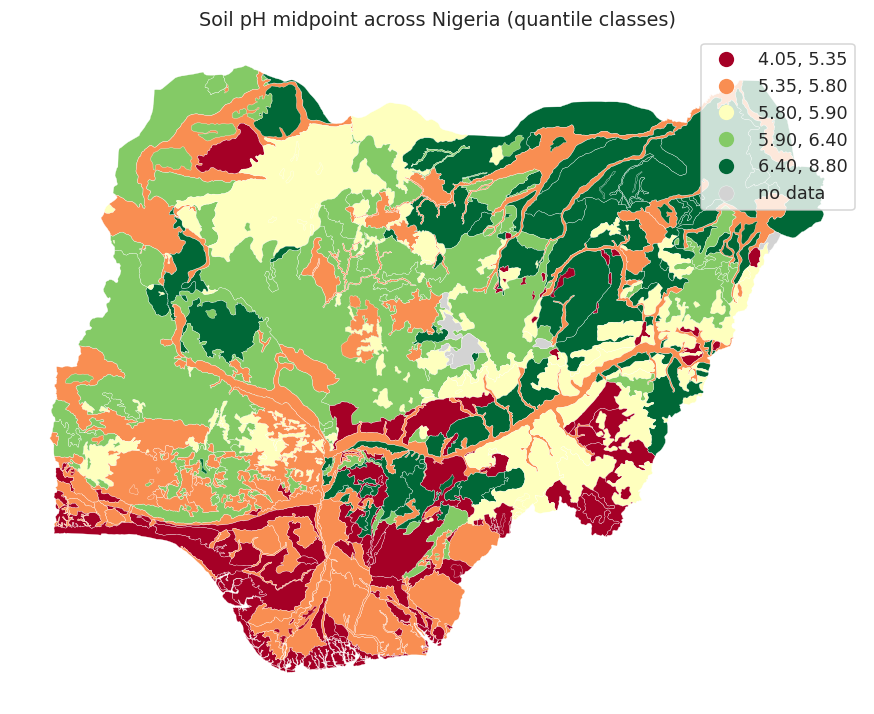

In [ ]:

# Soil pH midpoint choropleth
if "ph_mid" in soil_gdf.columns:
    plt.figure(figsize=(10, 9))
    soil_gdf.plot(column="ph_mid", legend=True, cmap="RdYlGn", scheme="quantiles",
                  edgecolor="white", linewidth=0.2, ax=plt.gca(),
                  missing_kwds={"color": "lightgrey", "label": "no data"})
    plt.title("Soil pH midpoint across Nigeria (quantile classes)")
    plt.axis("off")
    save_fig("soil_ph_choropleth")
    plt.show()

   💾 Saved → /content/figures/figure_27_soil_texture_map.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

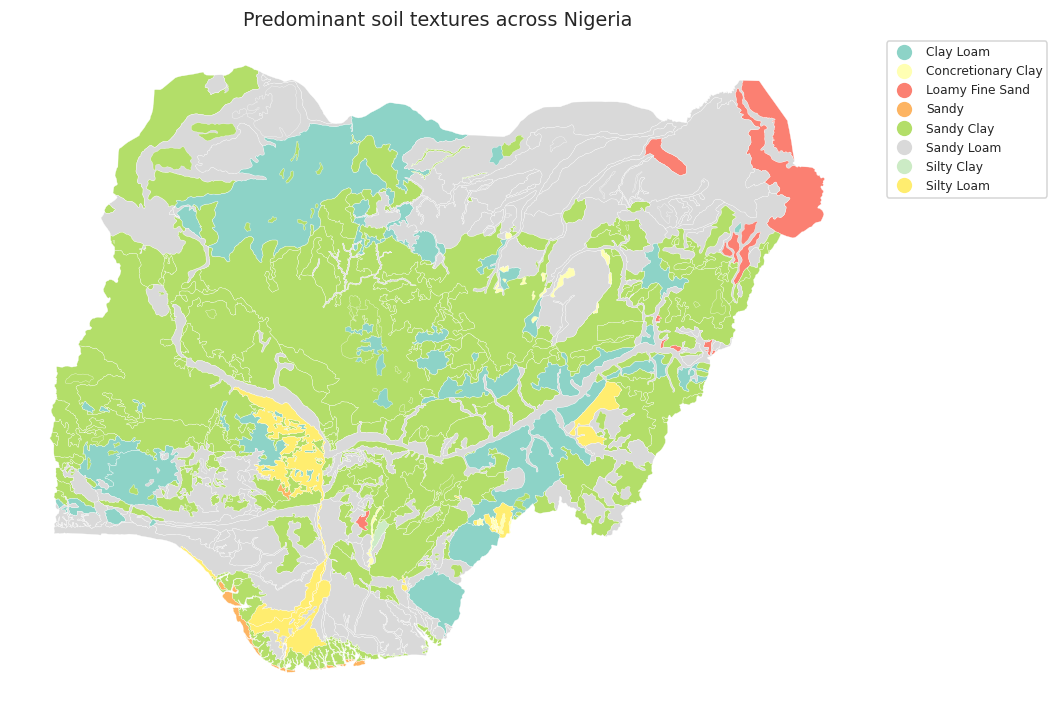

In [ ]:
# Soil texture map
if "SOIL_TEXTU" in soil_gdf.columns:
    plt.figure(figsize=(10, 9))
    soil_gdf.plot(column="SOIL_TEXTU", legend=True, cmap="Set3",
                  edgecolor="white", linewidth=0.2, ax=plt.gca(),
                  legend_kwds={"bbox_to_anchor": (1.02, 1), "loc": "upper left",
                               "fontsize": 8})
    plt.title("Predominant soil textures across Nigeria")
    plt.axis("off")
    save_fig("soil_texture_map")
    plt.show()

   💾 Saved → /content/figures/figure_28_soil_major_crops.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

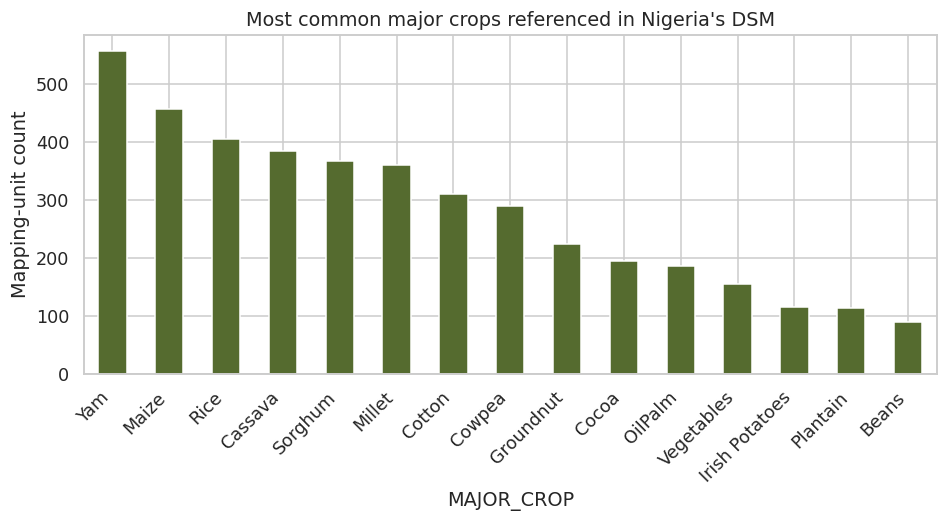

In [ ]:
# Major-crop word cloud-style frequency
if "MAJOR_CROP" in soil_gdf.columns:
    all_crops = (soil_gdf["MAJOR_CROP"].dropna().str.replace(".", "", regex=False)
                 .str.split(",").explode().str.strip())
    crop_freq = all_crops.value_counts().head(15)
    plt.figure(figsize=(10, 4))
    crop_freq.plot(kind="bar", color="darkolivegreen")
    plt.title("Most common major crops referenced in Nigeria's DSM")
    plt.ylabel("Mapping-unit count")
    plt.xticks(rotation=45, ha="right")
    save_fig("soil_major_crops")
    plt.show()

# SECTION 7 — OpenWeatherMap (live weather for any Nigerian location)

We pull **current conditions and 5-day / 3-hour forecasts** for a configurable
list of Nigerian rural agricultural hubs. These rows can later be fed to the
trained crop-recommendation model to demonstrate **real-time inference**.

Set your free API key in the next cell (https://openweathermap.org/api).

In [ ]:
# CELL 28: Live weather pull for rural Nigerian agricultural locations
import os, getpass
# The key is never stored in this notebook. Set OWM_API_KEY in the environment
# (Colab: the key icon in the left sidebar → add secret → os.environ) or paste
# it at the prompt; it is used for this session only.
OWM_API_KEY = os.environ.get("OWM_API_KEY") or getpass.getpass("OpenWeatherMap API key: ")

NIGERIAN_AGRI_HUBS = {
    "Uyo":           (5.0377, 7.9128),
    "Calabar":       (4.9590, 8.3270),
    "Ikom":          (5.9667, 8.7167),
    "Makurdi":       (7.7333, 8.5333),
    "Jos":           (9.9286, 8.8921),
    "Kano":          (12.0022, 8.5919),
    "Sokoto":        (13.0539, 5.2476),
    "Ilorin":        (8.5000, 4.5500),
    "Ibadan":        (7.3776, 3.9470),
    "Enugu":         (6.5244, 7.5086),
    "Yola":          (9.2035, 12.4954),
    "Maiduguri":     (11.8333, 13.1500),
}

def fetch_current_weather(lat, lon, api_key):
    url = "https://api.openweathermap.org/data/2.5/weather"
    r = requests.get(url, params={"lat": lat, "lon": lon, "appid": api_key,
                                  "units": "metric"}, timeout=20)
    r.raise_for_status()
    return r.json()

def fetch_forecast(lat, lon, api_key):
    url = "https://api.openweathermap.org/data/2.5/forecast"
    r = requests.get(url, params={"lat": lat, "lon": lon, "appid": api_key,
                                  "units": "metric"}, timeout=20)
    r.raise_for_status()
    return r.json()

rows = []
if OWM_API_KEY != "PUT_YOUR_OPENWEATHER_KEY_HERE":
    for city, (lat, lon) in NIGERIAN_AGRI_HUBS.items():
        try:
            cw = fetch_current_weather(lat, lon, OWM_API_KEY)
            rows.append({
                "city": city, "lat": lat, "lon": lon,
                "temperature": cw["main"]["temp"],
                "humidity":    cw["main"]["humidity"],
                "pressure":    cw["main"]["pressure"],
                "wind_speed":  cw["wind"]["speed"],
                "clouds":      cw["clouds"]["all"],
                "weather":     cw["weather"][0]["description"],
                "rain_1h":     cw.get("rain", {}).get("1h", 0.0),
                "fetched_at":  datetime.utcnow().isoformat(),
            })
        except Exception as e:
            print(f"  ⚠️  {city}: {e}")
    weather_df = pd.DataFrame(rows)
    weather_df.to_csv(DATA_DIR / "live_weather_nigeria.csv", index=False)
    print(weather_df)
else:
    print("⚠️  Add your OpenWeather API key above to enable live pulls.")
    weather_df = pd.DataFrame()

In [ ]:
# CELL 29: Visualise the live weather snapshot
if not weather_df.empty:
    # Current temperature across Nigerian hubs
    plt.figure(figsize=(11, 4))
    sns.barplot(data=weather_df.sort_values("temperature"),
                x="city", y="temperature", palette="coolwarm")
    plt.title("Current temperature at Nigerian agricultural hubs")
    plt.ylabel("Temperature (°C)")
    plt.xticks(rotation=40, ha="right")
    save_fig("owm_current_temperature")
    plt.show()

    # Folium map of current weather
    import folium
    m = folium.Map(location=[9.0, 8.0], zoom_start=6, tiles="OpenStreetMap")
    for _, r in weather_df.iterrows():
        folium.CircleMarker(
            location=[r["lat"], r["lon"]],
            radius=8, color="darkred", fill=True, fill_opacity=0.7,
            popup=(f"<b>{r['city']}</b><br>"
                   f"Temp: {r['temperature']} °C<br>"
                   f"Humidity: {r['humidity']}%<br>"
                   f"Weather: {r['weather']}")
        ).add_to(m)
    map_path = FIG_DIR / "owm_live_map.html"
    m.save(map_path)
    print("🗺️  Interactive map saved →", map_path)
    if IN_COLAB:
        files.download(str(map_path))

# SECTION 8 — CropHarvest (Nigeria slice via `cropharvest` package)

The full CropHarvest archive on Zenodo is ~50 GB of remote-sensing time-series.
We use the official `cropharvest` Python API to download **only the Nigeria
bounding box** (a few MB), then extract Sentinel-2 + ERA5 time series for
model training.

In [ ]:
# CELL 31 (revised): Download only features + labels, filter to Nigeria
import tarfile, requests
from pathlib import Path

ch_dir = DATA_DIR / "cropharvest"
ch_dir.mkdir(exist_ok=True)
(ch_dir / "features").mkdir(exist_ok=True)

# Direct download URLs from Zenodo record 10251170
ZENODO_BASE = "https://zenodo.org/records/10251170/files"
files_to_get = {
    "features.tar.gz": f"{ZENODO_BASE}/features.tar.gz",
    "labels.geojson":  f"{ZENODO_BASE}/labels.geojson",
}

for fname, url in files_to_get.items():
    fpath = ch_dir / fname
    if not fpath.exists():
        print(f"⬇️  Downloading {fname} …")
        with requests.get(url, stream=True, timeout=300) as r:
            r.raise_for_status()
            with open(fpath, "wb") as f:
                for chunk in r.iter_content(chunk_size=1 << 20):
                    f.write(chunk)
        print(f"   ✅ {fpath.stat().st_size / 1e6:.1f} MB")

# Extract features
features_tar = ch_dir / "features.tar.gz"
if not (ch_dir / "features" / "arrays").exists():
    print("📦 Extracting features.tar.gz …")
    with tarfile.open(features_tar) as tar:
        tar.extractall(ch_dir)
    print("   ✅ Extracted")

# Load labels and filter to Nigeria
import geopandas as gpd
labels_gdf = gpd.read_file(ch_dir / "labels.geojson")
print("Total labels worldwide:", len(labels_gdf))
print("Columns:", list(labels_gdf.columns))

# Filter by country attribute (preferred) or by Nigeria bounding box (fallback)
if "country" in labels_gdf.columns:
    ng_labels = labels_gdf[labels_gdf["country"].str.lower() == "nigeria"].copy()
else:
    # Nigeria bbox: lon 2.7–14.7, lat 4.3–13.9
    ng_labels = labels_gdf.cx[2.7:14.7, 4.3:13.9].copy()

print(f"\n🇳🇬 Nigeria labels: {len(ng_labels)}")
print(ng_labels.head())
print("\nCrop label distribution in Nigeria:")
if "classification_label" in ng_labels.columns:
    print(ng_labels["classification_label"].value_counts())

⬇️  Downloading features.tar.gz …
   ✅ 82.5 MB
⬇️  Downloading labels.geojson …
   ✅ 85.7 MB
📦 Extracting features.tar.gz …
   ✅ Extracted
Total labels worldwide: 113893
Columns: ['harvest_date', 'planting_date', 'label', 'classification_label', 'index', 'is_crop', 'lat', 'lon', 'dataset', 'collection_date', 'export_end_date', 'externally_contributed_dataset', 'is_test', 'geometry']

🇳🇬 Nigeria labels: 731
     harvest_date planting_date label classification_label  index  is_crop  \
5432          NaT           NaT  None                 None   1738        1   
5439          NaT           NaT  None                 None   1745        0   
5465          NaT           NaT  None                 None   1771        0   
5470          NaT           NaT  None                 None   1776        0   
5475          NaT           NaT  None                 None   1781        0   

           lat   lon                 dataset collection_date export_end_date  \
5432  5.452381  7.25  geowiki-landcover-2

In [ ]:
# CELL 31b (FINAL): Build X_ch and y_ch for Nigeria
# Filename pattern is <index>_<dataset>.h5 (index FIRST)

import h5py
import numpy as np
from tqdm import tqdm

features_dir = ch_dir / "features" / "arrays"

label_col = "is_crop"
print("Label distribution in Nigeria:")
print(ng_labels[label_col].value_counts(dropna=False))

X_list, y_list, skipped = [], [], 0
missing_examples = []

for _, row in tqdm(ng_labels.iterrows(), total=len(ng_labels),
                   desc="Loading Nigeria feature arrays"):
    # CORRECT pattern: <index>_<dataset>.h5
    h5_name = f"{row['index']}_{row['dataset']}.h5"
    h5_path = features_dir / h5_name

    if not h5_path.exists():
        skipped += 1
        if len(missing_examples) < 3:
            missing_examples.append(h5_name)
        continue
    try:
        with h5py.File(h5_path, "r") as f:
            arr = f["array"][:]   # shape: (timesteps, bands)
        X_list.append(arr.flatten())
        y_list.append(int(row[label_col]))
    except Exception as e:
        skipped += 1

X_ch = np.array(X_list) if X_list else None
y_ch = np.array(y_list) if y_list else None

print(f"\n✅ Built X_ch: shape = {X_ch.shape if X_ch is not None else 'EMPTY'}")
print(f"✅ Built y_ch: shape = {y_ch.shape if y_ch is not None else 'EMPTY'}")
print(f"   Skipped: {skipped}")

if missing_examples:
    print(f"\n   Missing examples:")
    for m in missing_examples:
        print(f"     - {m}")

if y_ch is not None and len(y_ch) > 0:
    unique, counts = np.unique(y_ch, return_counts=True)
    print(f"\n   Class balance: {dict(zip(unique.tolist(), counts.tolist()))}")

Label distribution in Nigeria:
is_crop
1    501
0    230
Name: count, dtype: int64


Loading Nigeria feature arrays: 100%|██████████| 731/731 [00:00<00:00, 1107.33it/s]


✅ Built X_ch: shape = (693, 216)
✅ Built y_ch: shape = (693,)
   Skipped: 38

   Missing examples:
     - 1806_geowiki-landcover-2017.h5
     - 1861_geowiki-landcover-2017.h5
     - 2002_geowiki-landcover-2017.h5

   Class balance: {0: 208, 1: 485}


Reshaped: 693 samples × 12 timesteps × 18 bands
   💾 Saved → /content/figures/figure_30_ch_mean_ndvi_nigeria.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

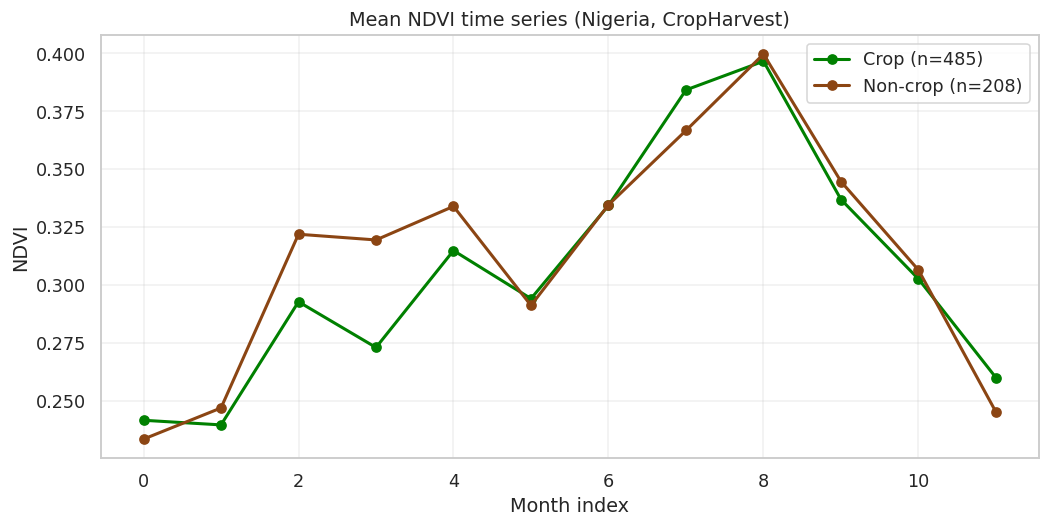

   💾 Saved → /content/figures/figure_31_ch_class_balance.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

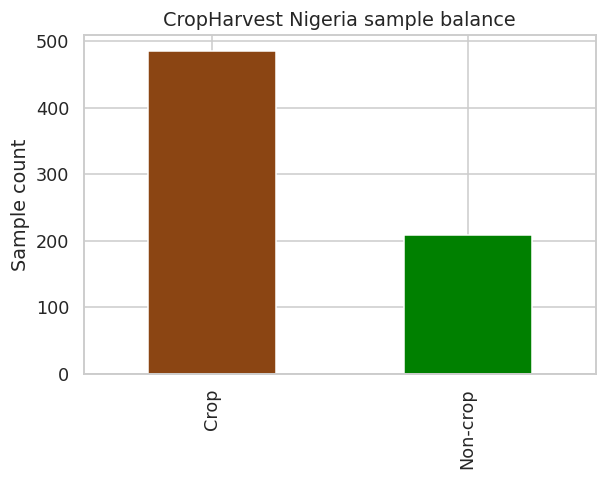

   💾 Saved → /content/figures/figure_32_ch_mean_temperature_nigeria.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

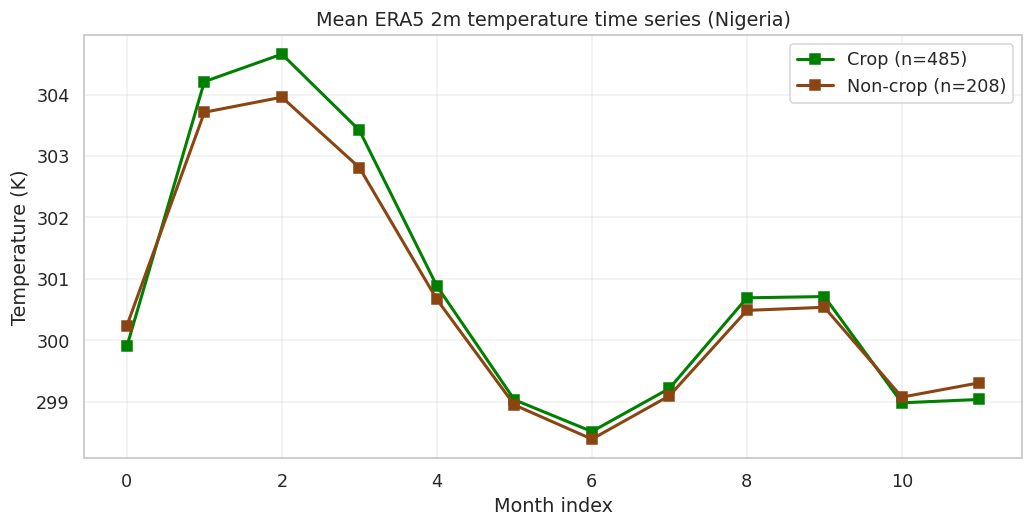

In [ ]:
# CELL 32: Visualise CropHarvest Nigeria time series
# Bands list copied from cropharvest.bands (the published order in the .h5 arrays)
BANDS = [
    "VV", "VH",                                          # Sentinel-1 SAR
    "B2", "B3", "B4", "B5", "B6", "B7", "B8",            # Sentinel-2 optical
    "B8A", "B9", "B11", "B12",
    "temperature_2m", "total_precipitation",             # ERA5 climate
    "elevation", "slope",                                # SRTM topography
    "NDVI",                                              # Vegetation index
]

if X_ch is not None and len(X_ch) > 0:
    # X is flattened (timesteps * bands). Re-shape to (n, timesteps, bands)
    n, flat = X_ch.shape
    n_bands = len(BANDS)
    n_steps = flat // n_bands
    X_ts = X_ch.reshape(n, n_steps, n_bands)
    print(f"Reshaped: {n} samples × {n_steps} timesteps × {n_bands} bands")

    # Mean NDVI time series by class
    ndvi_idx = BANDS.index("NDVI")
    plt.figure(figsize=(11, 5))
    for cls, name, color in [(1, "Crop", "green"), (0, "Non-crop", "saddlebrown")]:
        mask = (y_ch == cls)
        if mask.sum() > 0:
            plt.plot(X_ts[mask, :, ndvi_idx].mean(axis=0),
                     marker="o", label=f"{name} (n={mask.sum()})", color=color, lw=2)
    plt.title("Mean NDVI time series (Nigeria, CropHarvest)")
    plt.xlabel("Month index"); plt.ylabel("NDVI")
    plt.legend()
    plt.grid(True, alpha=0.3)
    save_fig("ch_mean_ndvi_nigeria")
    plt.show()

    # Crop vs non-crop sample counts
    plt.figure(figsize=(6, 4))
    pd.Series(y_ch).value_counts().rename({0: "Non-crop", 1: "Crop"}) \
        .plot(kind="bar", color=["saddlebrown", "green"])
    plt.title("CropHarvest Nigeria sample balance")
    plt.ylabel("Sample count")
    save_fig("ch_class_balance")
    plt.show()

    # BONUS Mean temperature time series by class (since we have it)
    if "temperature_2m" in BANDS:
        temp_idx = BANDS.index("temperature_2m")
        plt.figure(figsize=(11, 5))
        for cls, name, color in [(1, "Crop", "green"), (0, "Non-crop", "saddlebrown")]:
            mask = (y_ch == cls)
            if mask.sum() > 0:
                plt.plot(X_ts[mask, :, temp_idx].mean(axis=0),
                         marker="s", label=f"{name} (n={mask.sum()})",
                         color=color, lw=2)
        plt.title("Mean ERA5 2m temperature time series (Nigeria)")
        plt.xlabel("Month index"); plt.ylabel("Temperature (K)")
        plt.legend()
        plt.grid(True, alpha=0.3)
        save_fig("ch_mean_temperature_nigeria")
        plt.show()
else:
    print("⚠️  X_ch is empty — re-run Cell 31b first.")

# SECTION 9 — Multi-Dataset Fusion

We harmonise the **soil + climate** features shared by:
- Crop Recommendation (NPK, temp, humidity, ph, rainfall, crop label)
- IoT Agriculture 2024 (temp, humidity, NPK)
- Smart Agriculture (temp, humidity, moisture, irrigation label)

Plus geographic context from **Nigeria DSM** (mapping units → soil pH, texture).
This unified table is what we train the main classifiers on.

Unified table shape: (34714, 10)
      n     p     k  temperature   humidity        ph    rainfall label  \
0  90.0  42.0  43.0    20.879744  82.002744  6.502985  202.935536  rice   
1  85.0  58.0  41.0    21.770462  80.319644  7.038096  226.655537  rice   
2  60.0  55.0  44.0    23.004459  82.320763  7.840207  263.964248  rice   
3  74.0  35.0  40.0    26.491096  80.158363  6.980401  242.864034  rice   
4  78.0  42.0  42.0    20.130175  81.604873  7.628473  262.717340  rice   

      source  soil_moisture  
0  crop_reco            NaN  
1  crop_reco            NaN  
2  crop_reco            NaN  
3  crop_reco            NaN  
4  crop_reco            NaN  

Source composition:
source
smart_agric    16411
iot_2024       16103
crop_reco       2200
Name: count, dtype: int64
   💾 Saved → /content/figures/figure_33_unified_source_composition.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

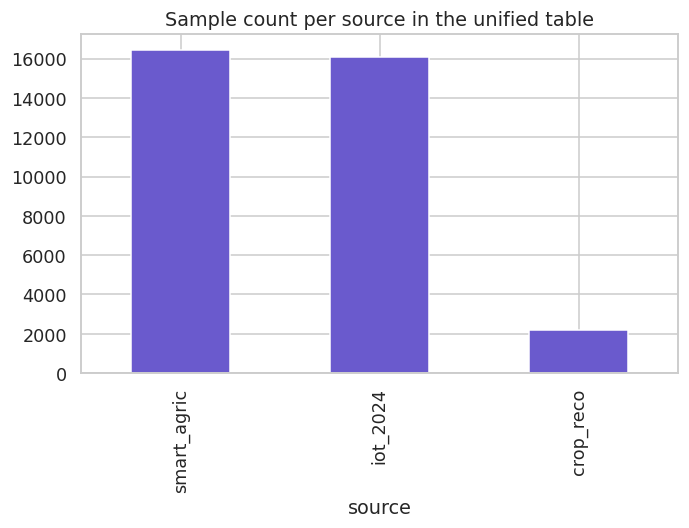

   💾 Saved → /content/figures/figure_34_unified_temp_humidity_by_source.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

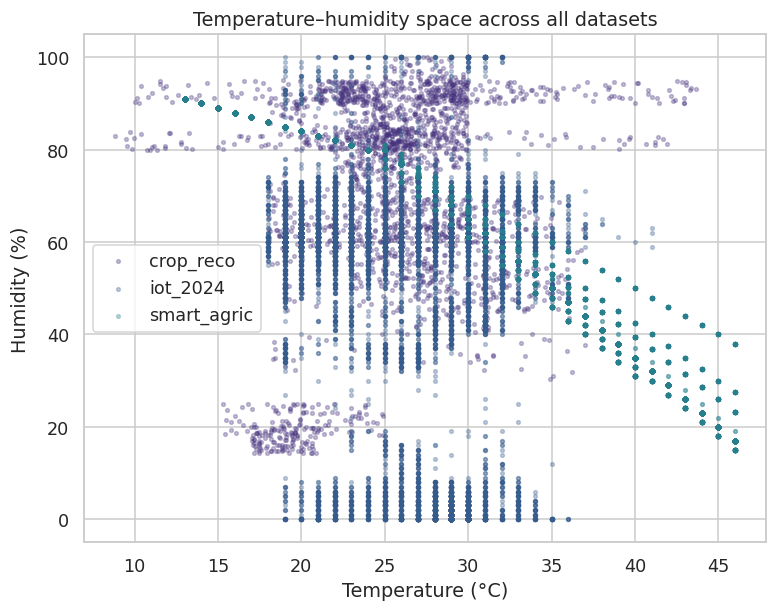

In [ ]:
# CELL 34: Harmonise schemas across datasets
def normalise_iot_npk(df):
    """IoT NPK is 0-255 scaled; project to the ~0-150 range used by Crop Reco."""
    df = df.copy()
    for c in ["n", "p", "k"]:
        if c in df.columns:
            df[c] = df[c] / 255.0 * 150.0
    return df

iot_norm = normalise_iot_npk(iot_df)

# Sub-frames with a common schema: N, P, K, temperature, humidity, source
common_a = crop_df.rename(columns=str.lower)[
    ["n", "p", "k", "temperature", "humidity", "ph", "rainfall", "label"]
].assign(source="crop_reco")

common_b = iot_norm[["n", "p", "k", "temperature", "humidity"]].copy()
common_b["ph"] = np.nan
common_b["rainfall"] = np.nan
common_b["label"] = "iot_greenhouse"
common_b["source"] = "iot_2024"

common_c = smart_df[["moi", "temp", "humidity", "result"]].rename(
    columns={"moi": "soil_moisture", "temp": "temperature"})
common_c["n"] = common_c["p"] = common_c["k"] = np.nan
common_c["ph"] = np.nan
common_c["rainfall"] = np.nan
common_c["label"] = np.where(common_c["result"] == 1, "irrigate", "no_irrigate")
common_c["source"] = "smart_agric"
common_c = common_c.drop(columns=["result"])

unified = pd.concat([common_a, common_b, common_c], ignore_index=True, sort=False)
print("Unified table shape:", unified.shape)
print(unified.head())
print("\nSource composition:"); print(unified["source"].value_counts())

# Composition of unified table
plt.figure(figsize=(7, 4))
unified["source"].value_counts().plot(kind="bar", color="slateblue")
plt.title("Sample count per source in the unified table")
save_fig("unified_source_composition")
plt.show()

# Joint distribution of temperature vs humidity by source
plt.figure(figsize=(8, 6))
for src, g in unified.groupby("source"):
    plt.scatter(g["temperature"], g["humidity"], s=6, alpha=0.3, label=src)
plt.legend(); plt.xlabel("Temperature (°C)"); plt.ylabel("Humidity (%)")
plt.title("Temperature–humidity space across all datasets")
save_fig("unified_temp_humidity_by_source")
plt.show()

# SECTION 10 — Crop Recommendation Task: Data Preparation

We now move from exploration to modelling. The crop recommendation task uses the Crop Recommendation Dataset (2,200 rows × 7 features, 22 crops).

Pipeline:
1. Encode the 22 crop labels as integers with `LabelEncoder`.
2. Stratified 80 / 20 train / test split (`random_state = 42`).
3. Standardise features (`StandardScaler`, fit on train only).
4. Save the scaler and label encoder so the saved models can be reused at inference time.

The same `X_train_s`, `X_test_s`, `y_train`, `y_test` arrays feed every one of the 17 models below.


In [ ]:
# Extra modelling imports (everything else is already imported in the setup cell)
import time, joblib, platform
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import ConfusionMatrixDisplay

# Detect device for logging
GPU_LIST = tf.config.list_physical_devices('GPU')
DL_DEVICE = "GPU" if GPU_LIST else "CPU"
CPU_DEVICE = "CPU"
print("Deep-learning device :", DL_DEVICE, "(", platform.machine(), ")")
print("Classical device     :", CPU_DEVICE)

# Make sure MODEL_DIR exists
MODEL_DIR.mkdir(parents=True, exist_ok=True)


Deep-learning device : GPU ( x86_64 )
Classical device     : CPU


In [ ]:
# Build X, y for the crop recommendation task
features = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
X = crop_df[features].values
le = LabelEncoder()
y = le.fit_transform(crop_df["label"].values)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

NUM_CLASSES = len(le.classes_)
print("X_train shape   :", X_train_s.shape)
print("X_test shape    :", X_test_s.shape)
print("Number of crops :", NUM_CLASSES)

# Persist preprocessing artefacts
joblib.dump(scaler, MODEL_DIR / "scaler.joblib")
joblib.dump(le,     MODEL_DIR / "label_encoder.joblib")
print("Saved scaler and label_encoder to", MODEL_DIR)


X_train shape   : (1760, 7)
X_test shape    : (440, 7)
Number of crops : 22
Saved scaler and label_encoder to /content/models


# SECTION 11 — Unified Evaluation Function

To compare 17 models fairly we evaluate every one of them on the *same* held-out test set with the *same* metric battery:

| Metric | What it tells us |
|---|---|
| Accuracy | Share of correct predictions |
| Precision (macro) | When the model says crop X, how often is it right (averaged over 22 crops) |
| Recall (macro) | Of all true X samples, how many did the model find |
| F1 (macro) | Harmonic mean of precision and recall |
| MCC | Matthews Correlation Coefficient — robust to class imbalance |
| ROC-AUC (OvR, macro) | Discriminative power across thresholds, one-vs-rest |
| Training time | Wall-clock seconds to fit |
| Inference latency | Mean wall-clock ms per sample at predict time |
| Device | CPU or GPU |
| Group | Classical, Ensemble, or Deep Learning |

The `evaluate_model` helper computes all of the above from a fitted estimator and stores a row in the global `results` list.


In [ ]:
# Unified evaluation harness used by every model in this notebook
results = []  # one dict per model

def evaluate_classifier(name, model, X_tr, y_tr, X_te, y_te,
                        group, device, n_classes,
                        already_fitted=False, proba_fn=None):
    """Fit (if needed), predict, time everything, compute every metric.

    Parameters
    ----------
    name : str               human-readable model name
    model : object           must implement .predict (and ideally .predict_proba)
    X_tr, y_tr, X_te, y_te : arrays
    group : str              "Classical", "Ensemble", or "Deep Learning"
    device : str             "CPU" or "GPU"
    n_classes : int
    already_fitted : bool    if True, skip the fit timing
    proba_fn : callable      override for predict_proba (used by Keras)
    """
    # 1. Fit and time it
    if already_fitted:
        train_time = float("nan")
    else:
        t0 = time.perf_counter()
        model.fit(X_tr, y_tr)
        train_time = time.perf_counter() - t0

    # 2. Predictions + inference latency on the full test set
    t0 = time.perf_counter()
    y_pred = model.predict(X_te)
    pred_time = time.perf_counter() - t0
    inf_latency_ms = (pred_time / len(X_te)) * 1000.0

    # 3. Probabilities for ROC-AUC (if available)
    proba = None
    try:
        if proba_fn is not None:
            proba = proba_fn(X_te)
        elif hasattr(model, "predict_proba"):
            proba = model.predict_proba(X_te)
    except Exception:
        proba = None

    # 4. Metrics
    row = {
        "model": name,
        "group": group,
        "device": device,
        "accuracy":          accuracy_score(y_te, y_pred),
        "precision_macro":   precision_score(y_te, y_pred, average="macro", zero_division=0),
        "recall_macro":      recall_score(y_te, y_pred,    average="macro", zero_division=0),
        "f1_macro":          f1_score(y_te, y_pred,        average="macro", zero_division=0),
        "mcc":               matthews_corrcoef(y_te, y_pred),
        "training_time_s":   train_time,
        "inference_latency_ms": inf_latency_ms,
    }

    if proba is not None:
        try:
            row["roc_auc_ovr_macro"] = roc_auc_score(
                y_te, proba, multi_class="ovr", average="macro"
            )
        except Exception:
            row["roc_auc_ovr_macro"] = float("nan")
    else:
        row["roc_auc_ovr_macro"] = float("nan")

    # 5. Confusion matrix stored separately (too big to fit in the table)
    row["_y_pred"] = y_pred
    row["_y_test"] = y_te
    row["_n_classes"] = n_classes
    return row, model

def pretty_metrics(row):
    return (f"{row['model']:<24s}  acc={row['accuracy']:.4f}  "
            f"prec={row['precision_macro']:.4f}  rec={row['recall_macro']:.4f}  "
            f"f1={row['f1_macro']:.4f}  mcc={row['mcc']:.4f}  "
            f"auc={row['roc_auc_ovr_macro']:.4f}  "
            f"fit={row['training_time_s']:.2f}s  "
            f"inf={row['inference_latency_ms']:.3f}ms/sample")


# SECTION 12 — Train and Evaluate the 12 Classical Models

We train every classical model on the same scaled training set, evaluate it on the same held-out test set, and record the full metric battery.

The twelve classical models are:

1. Logistic Regression
2. K-Nearest Neighbours (k=5)
3. Decision Tree
4. Random Forest
5. Extra Trees
6. Gradient Boosting
7. SVM with RBF kernel (`probability=True` to allow ROC-AUC)
8. Gaussian Naive Bayes
9. Linear Discriminant Analysis
10. XGBoost (default hyperparameters; a tuned version is built in the next section)
11. LightGBM
12. CatBoost


In [ ]:
# Build the 12 classical models
classical_models = {
    "Logistic Regression":         LogisticRegression(max_iter=2000, n_jobs=-1, random_state=SEED),
    "K-Nearest Neighbours":        KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "Decision Tree":               DecisionTreeClassifier(random_state=SEED),
    "Random Forest":               RandomForestClassifier(n_estimators=400, n_jobs=-1, random_state=SEED),
    "Extra Trees":                 ExtraTreesClassifier(n_estimators=400, n_jobs=-1, random_state=SEED),
    "Gradient Boosting":           GradientBoostingClassifier(random_state=SEED),
    "SVM (RBF)":                   SVC(kernel="rbf", probability=True, random_state=SEED),
    "Gaussian Naive Bayes":        GaussianNB(),
    "Linear Discriminant Analysis":LinearDiscriminantAnalysis(),
    "XGBoost (default)":           xgb.XGBClassifier(
                                        eval_metric="mlogloss", random_state=SEED,
                                        n_jobs=-1, tree_method="hist",
                                        verbosity=0),
    "LightGBM":                    lgb.LGBMClassifier(random_state=SEED, n_jobs=-1, verbosity=-1),
    "CatBoost":                    CatBoostClassifier(random_state=SEED, verbose=False),
}
print("Classical models to train :", len(classical_models))


Classical models to train : 12


In [ ]:
# Train and evaluate every classical model
fitted_classical = {}
for name, mdl in classical_models.items():
    row, fitted = evaluate_classifier(
        name=name, model=mdl,
        X_tr=X_train_s, y_tr=y_train,
        X_te=X_test_s,  y_te=y_test,
        group="Classical", device=CPU_DEVICE,
        n_classes=NUM_CLASSES,
    )
    results.append(row)
    fitted_classical[name] = fitted
    print(pretty_metrics(row))


Logistic Regression       acc=0.9727  prec=0.9740  rec=0.9727  f1=0.9725  mcc=0.9715  auc=0.9998  fit=1.45s  inf=0.001ms/sample
K-Nearest Neighbours      acc=0.9795  prec=0.9804  rec=0.9795  f1=0.9793  mcc=0.9786  auc=0.9987  fit=0.00s  inf=0.032ms/sample
Decision Tree             acc=0.9795  prec=0.9806  rec=0.9795  f1=0.9794  mcc=0.9786  auc=0.9893  fit=0.01s  inf=0.001ms/sample
Random Forest             acc=0.9955  prec=0.9957  rec=0.9955  f1=0.9955  mcc=0.9952  auc=1.0000  fit=1.40s  inf=0.264ms/sample
Extra Trees               acc=0.9955  prec=0.9957  rec=0.9955  f1=0.9955  mcc=0.9952  auc=1.0000  fit=0.86s  inf=0.265ms/sample
Gradient Boosting         acc=0.9886  prec=0.9897  rec=0.9886  f1=0.9887  mcc=0.9881  auc=1.0000  fit=12.42s  inf=0.042ms/sample
SVM (RBF)                 acc=0.9841  prec=0.9856  rec=0.9841  f1=0.9840  mcc=0.9834  auc=1.0000  fit=0.21s  inf=0.088ms/sample
Gaussian Naive Bayes      acc=0.9955  prec=0.9959  rec=0.9955  f1=0.9954  mcc=0.9953  auc=1.0000  fit=0

In [ ]:
# Save each fitted classical model individually
for name, mdl in fitted_classical.items():
    safe = name.lower().replace(" ", "_").replace("(", "").replace(")", "")
    fpath = MODEL_DIR / f"classical_{safe}.joblib"
    joblib.dump(mdl, fpath)
print(f"Saved {len(fitted_classical)} classical models to {MODEL_DIR}")


Saved 12 classical models to /content/models


# SECTION 13 — Hyperparameter Tuning of XGBoost (Optuna, TPE)

We then run 40 trials of Bayesian optimisation (Tree-structured Parzen Estimator via Optuna) on XGBoost. The tuned model is used downstream for:
- the SHAP explainability section, because tree-based models are SHAP-fast,
- the soft-voting and stacking ensembles, as one of the base learners.

Bayesian optimisation is more efficient than a grid search: it uses the result of previous trials to guide where to look next.


In [ ]:
# Optuna search for XGBoost
def xgb_objective(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 200, 800, step=100),
        "max_depth":        trial.suggest_int("max_depth", 3, 12),
        "learning_rate":    trial.suggest_float("learning_rate", 0.02, 0.30, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 6),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "tree_method":      "hist",
        "random_state":     SEED,
        "n_jobs":           -1,
        "eval_metric":      "mlogloss",
        "verbosity":        0,
    }
    mdl = xgb.XGBClassifier(**params)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    cv_scores = cross_val_score(mdl, X_train_s, y_train, cv=skf,
                                scoring="accuracy", n_jobs=-1)
    return cv_scores.mean()

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction="maximize")
study.optimize(xgb_objective, n_trials=40, show_progress_bar=True)

print("Best CV accuracy :", round(study.best_value, 4))
print("Best params      :", study.best_params)


  0%|          | 0/40 [00:00<?, ?it/s]

Best CV accuracy : 0.9938
Best params      : {'n_estimators': 500, 'max_depth': 9, 'learning_rate': 0.04393283102206387, 'subsample': 0.6091794425820833, 'colsample_bytree': 0.8054674170004823, 'min_child_weight': 1, 'reg_lambda': 0.03763735859888728}


In [ ]:
# Train the tuned XGBoost on the full training set and evaluate
best_xgb = xgb.XGBClassifier(
    **study.best_params,
    tree_method="hist", random_state=SEED, n_jobs=-1,
    eval_metric="mlogloss", verbosity=0,
)

row, best_xgb = evaluate_classifier(
    name="XGBoost (tuned, Optuna)", model=best_xgb,
    X_tr=X_train_s, y_tr=y_train,
    X_te=X_test_s,  y_te=y_test,
    group="Classical", device=CPU_DEVICE,
    n_classes=NUM_CLASSES,
)
results.append(row)
fitted_classical["XGBoost (tuned, Optuna)"] = best_xgb
print(pretty_metrics(row))

joblib.dump(best_xgb, MODEL_DIR / "classical_xgboost_tuned.joblib")
print("Saved tuned XGBoost to", MODEL_DIR / "classical_xgboost_tuned.joblib")


XGBoost (tuned, Optuna)   acc=0.9909  prec=0.9913  rec=0.9909  f1=0.9908  mcc=0.9905  auc=1.0000  fit=2.69s  inf=0.184ms/sample
Saved tuned XGBoost to /content/models/classical_xgboost_tuned.joblib


# SECTION 14 — Ensemble Methods (Soft Voting and Stacking)

Two ensembles are built on top of four strong base learners (tuned XGBoost, Random Forest, LightGBM, CatBoost):

- **Soft Voting** — averages the predicted probabilities from every base learner and picks the crop with the highest average probability.
- **Stacking** — a Logistic Regression meta-learner takes the base learners' predictions as input and learns how to weigh them against each other.

Both ensembles are evaluated on the full metric battery, just like the classical models.


In [ ]:
# Build the soft-voting and stacking ensembles
ensemble_bases = [
    ("xgb",      best_xgb),
    ("rf",       RandomForestClassifier(n_estimators=400, n_jobs=-1, random_state=SEED)),
    ("lgb",      lgb.LGBMClassifier(random_state=SEED, n_jobs=-1, verbosity=-1)),
    ("catboost", CatBoostClassifier(random_state=SEED, verbose=False)),
]

soft_voting = VotingClassifier(estimators=ensemble_bases, voting="soft", n_jobs=-1)
stacking    = StackingClassifier(
    estimators=ensemble_bases,
    final_estimator=LogisticRegression(max_iter=2000, random_state=SEED),
    cv=5, n_jobs=-1, passthrough=False,
)

ensemble_models = {
    "Soft Voting Ensemble": soft_voting,
    "Stacking Ensemble":    stacking,
}

fitted_ensembles = {}
for name, mdl in ensemble_models.items():
    row, fitted = evaluate_classifier(
        name=name, model=mdl,
        X_tr=X_train_s, y_tr=y_train,
        X_te=X_test_s,  y_te=y_test,
        group="Ensemble", device=CPU_DEVICE,
        n_classes=NUM_CLASSES,
    )
    results.append(row)
    fitted_ensembles[name] = fitted
    print(pretty_metrics(row))

# Save ensembles
for name, mdl in fitted_ensembles.items():
    safe = name.lower().replace(" ", "_")
    joblib.dump(mdl, MODEL_DIR / f"ensemble_{safe}.joblib")
print("Saved ensembles to", MODEL_DIR)


Soft Voting Ensemble      acc=0.9977  prec=0.9978  rec=0.9977  f1=0.9977  mcc=0.9976  auc=1.0000  fit=30.61s  inf=0.673ms/sample
Stacking Ensemble         acc=0.9977  prec=0.9978  rec=0.9977  f1=0.9977  mcc=0.9976  auc=1.0000  fit=176.66s  inf=0.757ms/sample
Saved ensembles to /content/models


# SECTION 15 — Deep Learning Models (MLP, 1D-CNN, Attention MLP)

Three neural architectures are tested on the same data:

1. **Multilayer Perceptron** — strong baseline for tabular data.
2. **1D Convolutional Neural Network** — convolutions across the seven features; tests whether spatial filters add anything.
3. **Attention MLP** — a self-attention block over the seven feature tokens; tests whether learned feature-interaction helps.

All three are trained for up to 200 epochs with early stopping on a 10 % validation split. Training time is measured wall-clock; inference latency is measured per sample on the full test set.

Each architecture is reported honestly even if it underperforms.


In [ ]:
# Common training settings for the deep models
EPOCHS    = 200
BATCH     = 32
PATIENCE  = 25
VAL_SPLIT = 0.10

y_train_oh = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test_oh  = keras.utils.to_categorical(y_test,  NUM_CLASSES)

def keras_predict_proba(model):
    """Wrap a Keras classifier so it exposes a sklearn-style predict_proba."""
    def _fn(X):
        return model.predict(X, verbose=0)
    return _fn

class KerasSklearnAdapter:
    """Tiny adapter so evaluate_classifier (sklearn-style) works on Keras models."""
    def __init__(self, model, reshape_for_cnn=False):
        self.model = model
        self.reshape_for_cnn = reshape_for_cnn
    def _maybe_reshape(self, X):
        return X.reshape(-1, X.shape[1], 1) if self.reshape_for_cnn else X
    def fit(self, X, y):
        # Already fitted; this is a no-op
        return self
    def predict(self, X):
        proba = self.model.predict(self._maybe_reshape(X), verbose=0)
        return np.argmax(proba, axis=1)
    def predict_proba(self, X):
        return self.model.predict(self._maybe_reshape(X), verbose=0)

print("Keras helpers ready.")


Keras helpers ready.


In [ ]:
# Multilayer Perceptron
tf.keras.backend.clear_session(); tf.random.set_seed(SEED)
mlp = keras.Sequential([
    layers.Input(shape=(X_train_s.shape[1],)),
    layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.30),
    layers.Dense(64,  activation="relu"),
    layers.Dropout(0.30),
    layers.Dense(NUM_CLASSES, activation="softmax"),
])
mlp.compile(optimizer=keras.optimizers.Adam(1e-3),
            loss="categorical_crossentropy", metrics=["accuracy"])

t0 = time.perf_counter()
hist_mlp = mlp.fit(X_train_s, y_train_oh,
                   validation_split=VAL_SPLIT, epochs=EPOCHS, batch_size=BATCH,
                   callbacks=[callbacks.EarlyStopping(patience=PATIENCE,
                                                     restore_best_weights=True)],
                   verbose=0)
mlp_train_time = time.perf_counter() - t0

adapter = KerasSklearnAdapter(mlp, reshape_for_cnn=False)
row, _ = evaluate_classifier(
    name="MLP", model=adapter,
    X_tr=X_train_s, y_tr=y_train, X_te=X_test_s, y_te=y_test,
    group="Deep Learning", device=DL_DEVICE,
    n_classes=NUM_CLASSES, already_fitted=True,
)
row["training_time_s"] = mlp_train_time
results.append(row)
print(pretty_metrics(row))
mlp.save(MODEL_DIR / "deep_mlp.keras")


MLP                       acc=0.9955  prec=0.9959  rec=0.9955  f1=0.9954  mcc=0.9953  auc=0.9999  fit=53.80s  inf=1.402ms/sample


In [ ]:
# 1-D Convolutional Neural Network
tf.keras.backend.clear_session(); tf.random.set_seed(SEED)
X_train_cnn = X_train_s.reshape(-1, X_train_s.shape[1], 1)
X_test_cnn  = X_test_s.reshape(-1,  X_test_s.shape[1],  1)

cnn = keras.Sequential([
    layers.Input(shape=(X_train_cnn.shape[1], 1)),
    layers.Conv1D(32, kernel_size=2, activation="relu", padding="same"),
    layers.Conv1D(64, kernel_size=2, activation="relu", padding="same"),
    layers.GlobalAveragePooling1D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.30),
    layers.Dense(NUM_CLASSES, activation="softmax"),
])
cnn.compile(optimizer=keras.optimizers.Adam(1e-3),
            loss="categorical_crossentropy", metrics=["accuracy"])

t0 = time.perf_counter()
hist_cnn = cnn.fit(X_train_cnn, y_train_oh,
                   validation_split=VAL_SPLIT, epochs=EPOCHS, batch_size=BATCH,
                   callbacks=[callbacks.EarlyStopping(patience=PATIENCE,
                                                     restore_best_weights=True)],
                   verbose=0)
cnn_train_time = time.perf_counter() - t0

adapter = KerasSklearnAdapter(cnn, reshape_for_cnn=True)
row, _ = evaluate_classifier(
    name="1D CNN", model=adapter,
    X_tr=X_train_s, y_tr=y_train, X_te=X_test_s, y_te=y_test,
    group="Deep Learning", device=DL_DEVICE,
    n_classes=NUM_CLASSES, already_fitted=True,
)
row["training_time_s"] = cnn_train_time
results.append(row)
print(pretty_metrics(row))
cnn.save(MODEL_DIR / "deep_cnn1d.keras")


1D CNN                    acc=0.9864  prec=0.9883  rec=0.9864  f1=0.9865  mcc=0.9858  auc=1.0000  fit=58.29s  inf=1.661ms/sample


In [ ]:
# Attention MLP
tf.keras.backend.clear_session(); tf.random.set_seed(SEED)
EMBED_DIM = 16
NUM_HEADS = 4

inp = layers.Input(shape=(X_train_s.shape[1],))
x   = layers.Reshape((X_train_s.shape[1], 1))(inp)
x   = layers.Dense(EMBED_DIM)(x)        # token-wise embedding
attn = layers.MultiHeadAttention(num_heads=NUM_HEADS, key_dim=EMBED_DIM)(x, x)
x    = layers.LayerNormalization()(x + attn)
x    = layers.GlobalAveragePooling1D()(x)
x    = layers.Dense(64, activation="relu")(x)
x    = layers.Dropout(0.30)(x)
out  = layers.Dense(NUM_CLASSES, activation="softmax")(x)
att_mlp = keras.Model(inp, out)
att_mlp.compile(optimizer=keras.optimizers.Adam(1e-3),
                loss="categorical_crossentropy", metrics=["accuracy"])

t0 = time.perf_counter()
hist_att = att_mlp.fit(X_train_s, y_train_oh,
                       validation_split=VAL_SPLIT, epochs=EPOCHS, batch_size=BATCH,
                       callbacks=[callbacks.EarlyStopping(patience=PATIENCE,
                                                         restore_best_weights=True)],
                       verbose=0)
att_train_time = time.perf_counter() - t0

adapter = KerasSklearnAdapter(att_mlp, reshape_for_cnn=False)
row, _ = evaluate_classifier(
    name="Attention MLP", model=adapter,
    X_tr=X_train_s, y_tr=y_train, X_te=X_test_s, y_te=y_test,
    group="Deep Learning", device=DL_DEVICE,
    n_classes=NUM_CLASSES, already_fitted=True,
)
row["training_time_s"] = att_train_time
results.append(row)
print(pretty_metrics(row))
att_mlp.save(MODEL_DIR / "deep_attention_mlp.keras")


Attention MLP             acc=0.6182  prec=0.6185  rec=0.6182  f1=0.5984  mcc=0.6018  auc=0.9679  fit=60.59s  inf=5.894ms/sample


# SECTION 16 — All 17 Models: Combined Comparison

Every model trained in Sections 12 - 15 has been evaluated on the same test set with the same metric battery. We now build a single comparison table covering all 17 models and export it as a CSV.

The model count breakdown:
- 12 classical models (Section 12)
- 1 tuned XGBoost (Section 13) — counted within the Classical group, alongside its default-hyperparameter twin
- 2 ensembles (Section 14)
- 3 deep learning models (Section 15)

That is **17 distinct evaluated configurations** for the crop recommendation task.


In [ ]:
# Assemble the comparison table
metric_cols = [
    "model", "group", "device",
    "accuracy", "precision_macro", "recall_macro", "f1_macro",
    "mcc", "roc_auc_ovr_macro",
    "training_time_s", "inference_latency_ms",
]
results_df = pd.DataFrame([{k: r[k] for k in metric_cols} for r in results])

# Sort within each group by accuracy, group order: Classical, Ensemble, Deep Learning
group_order = ["Classical", "Ensemble", "Deep Learning"]
results_df["group"] = pd.Categorical(results_df["group"], categories=group_order, ordered=True)
results_df = results_df.sort_values(["group", "accuracy"], ascending=[True, False]).reset_index(drop=True)

print(f"Total models evaluated: {len(results_df)}")
results_df.round(4)


Total models evaluated: 18


,model,group,device,accuracy,precision_macro,recall_macro,f1_macro,mcc,roc_auc_ovr_macro,training_time_s,inference_latency_ms
0,CatBoost,Classical,CPU,0.9977,0.9978,0.9977,0.9977,0.9976,1.0000,22.2341,0.0125
1,Random Forest,Classical,CPU,0.9955,0.9957,0.9955,0.9955,0.9952,1.0000,1.3956,0.2636
2,Extra Trees,Classical,CPU,0.9955,0.9957,0.9955,0.9955,0.9952,1.0000,0.8561,0.2651
3,Gaussian Naive Bayes,Classical,CPU,0.9955,0.9959,0.9955,0.9954,0.9953,1.0000,0.0026,0.0027
4,XGBoost (default),Classical,CPU,0.9909,0.9915,0.9909,0.9908,0.9905,0.9999,0.6076,0.0169
5,"XGBoost (tuned, Optuna)",Classical,CPU,0.9909,0.9913,0.9909,0.9908,0.9905,1.0000,2.6932,0.1836
6,Gradient Boosting,Classical,CPU,0.9886,0.9897,0.9886,0.9887,0.9881,1.0000,12.4240,0.0423
7,LightGBM,Classical,CPU,0.9886,0.9891,0.9886,0.9886,0.9881,1.0000,2.4268,0.1865
8,SVM (RBF),Classical,CPU,0.9841,0.9856,0.9841,0.9840,0.9834,1.0000,0.2102,0.0880
9,K-Nearest Neighbours,Classical,CPU,0.9795,0.9804,0.9795,0.9793,0.9786,0.9987,0.0033,0.0320


In [ ]:
# Export the comparison table to CSV
out_csv = Path("/content") / "all_17_models_comparison.csv"
results_df.round(6).to_csv(out_csv, index=False)
print("Saved:", out_csv)
results_df.round(4)


Saved: /content/all_17_models_comparison.csv


,model,group,device,accuracy,precision_macro,recall_macro,f1_macro,mcc,roc_auc_ovr_macro,training_time_s,inference_latency_ms
0,CatBoost,Classical,CPU,0.9977,0.9978,0.9977,0.9977,0.9976,1.0000,22.2341,0.0125
1,Random Forest,Classical,CPU,0.9955,0.9957,0.9955,0.9955,0.9952,1.0000,1.3956,0.2636
2,Extra Trees,Classical,CPU,0.9955,0.9957,0.9955,0.9955,0.9952,1.0000,0.8561,0.2651
3,Gaussian Naive Bayes,Classical,CPU,0.9955,0.9959,0.9955,0.9954,0.9953,1.0000,0.0026,0.0027
4,XGBoost (default),Classical,CPU,0.9909,0.9915,0.9909,0.9908,0.9905,0.9999,0.6076,0.0169
5,"XGBoost (tuned, Optuna)",Classical,CPU,0.9909,0.9913,0.9909,0.9908,0.9905,1.0000,2.6932,0.1836
6,Gradient Boosting,Classical,CPU,0.9886,0.9897,0.9886,0.9887,0.9881,1.0000,12.4240,0.0423
7,LightGBM,Classical,CPU,0.9886,0.9891,0.9886,0.9886,0.9881,1.0000,2.4268,0.1865
8,SVM (RBF),Classical,CPU,0.9841,0.9856,0.9841,0.9840,0.9834,1.0000,0.2102,0.0880
9,K-Nearest Neighbours,Classical,CPU,0.9795,0.9804,0.9795,0.9793,0.9786,0.9987,0.0033,0.0320


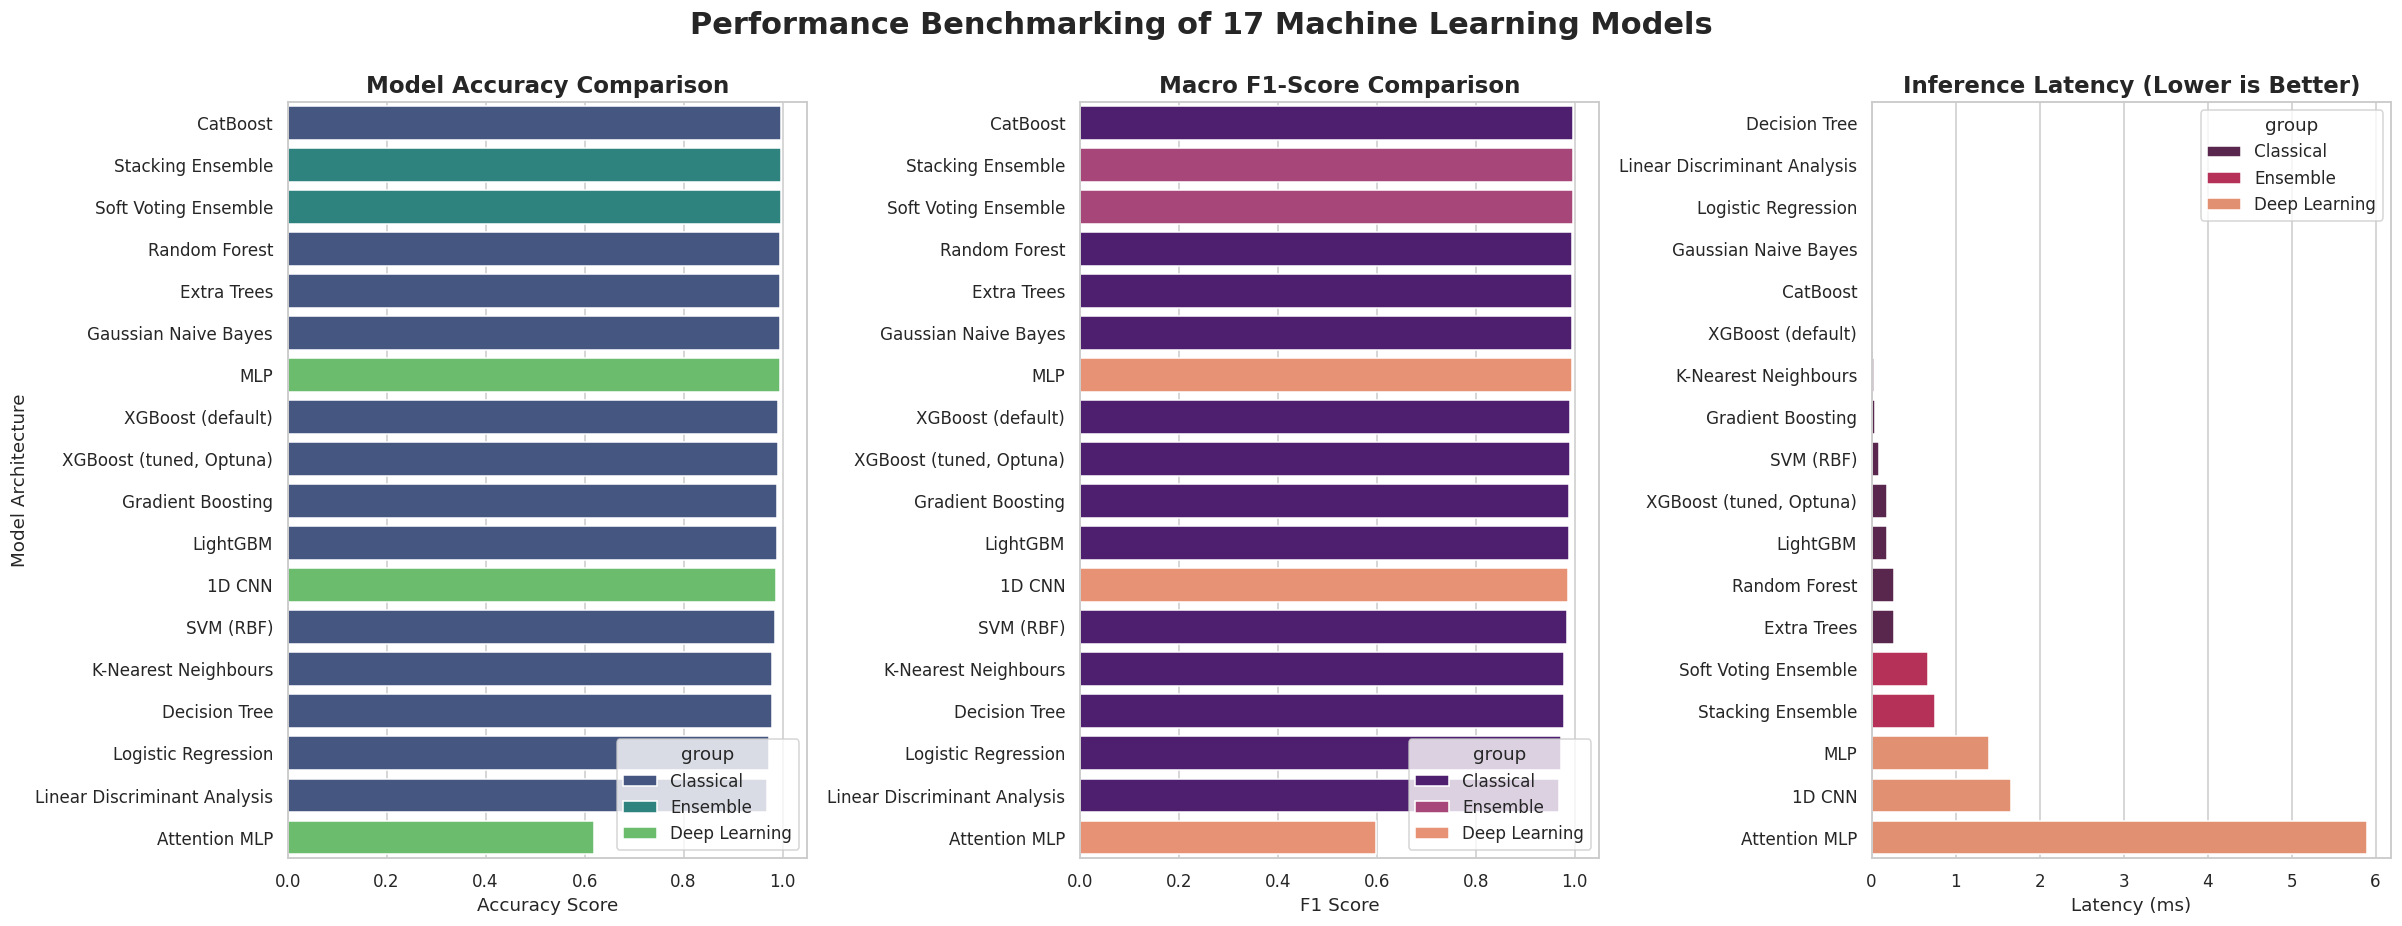

In [ ]:
# @title 📊 Model Comparison Visual Analysis {display-mode: "form"}

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- Load Data ---
csv_path = "/content/all_17_models_comparison.csv"
if not os.path.exists(csv_path):
    print(f"⚠️ Error: {csv_path} not found. Please ensure the comparison CSV has been generated.")
else:
    df = pd.read_csv(csv_path)

    # Setup plotting style
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 3, figsize=(22, 8))

    # Sort by accuracy for better visualization
    df_sorted = df.sort_values("accuracy", ascending=False)

    # 1. Accuracy Comparison
    sns.barplot(data=df_sorted, x="accuracy", y="model", hue="group", ax=axes[0], palette="viridis")
    axes[0].set_title("Model Accuracy Comparison", fontsize=15, fontweight='bold')
    axes[0].set_xlabel("Accuracy Score")
    axes[0].set_ylabel("Model Architecture")
    axes[0].set_xlim(0, 1.05)

    # 2. F1-Score Comparison
    sns.barplot(data=df_sorted, x="f1_macro", y="model", hue="group", ax=axes[1], palette="magma")
    axes[1].set_title("Macro F1-Score Comparison", fontsize=15, fontweight='bold')
    axes[1].set_xlabel("F1 Score")
    axes[1].set_ylabel("")
    axes[1].set_xlim(0, 1.05)

    # 3. Latency Comparison (Inference Speed)
    # Sorting by latency for the third plot
    df_latency = df.sort_values("inference_latency_ms", ascending=True)
    sns.barplot(data=df_latency, x="inference_latency_ms", y="model", hue="group", ax=axes[2], palette="rocket")
    axes[2].set_title("Inference Latency (Lower is Better)", fontsize=15, fontweight='bold')
    axes[2].set_xlabel("Latency (ms)")
    axes[2].set_ylabel("")

    # Final layout adjustments
    plt.tight_layout()
    plt.suptitle("Performance Benchmarking of 17 Machine Learning Models", fontsize=20, fontweight='bold', y=1.05)

    # Display only the plot
    plt.show()

In [ ]:
# @title 🏆 Model Comparison Leaderboard {display-mode: "form"}

import pandas as pd
import json
import os
from IPython.display import HTML
from google.colab import output

# --- Configuration ---
CSV_PATH = "/content/all_17_models_comparison.csv"

def get_dashboard_data():
    if not os.path.exists(CSV_PATH):
        return {"status": "FILE_NOT_FOUND"}

    try:
        df = pd.read_csv(CSV_PATH)
        if df.empty:
            return {"status": "EMPTY_FILE"}

        # Standardize columns
        df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

        # Clean and round numeric values
        numeric_cols = df.select_dtypes(include=['number']).columns
        df[numeric_cols] = df[numeric_cols].round(4)

        return {
            "status": "OK",
            "data": df.where(pd.notnull(df), None).to_dict(orient="records")
        }
    except Exception as e:
        return {"status": "ERROR", "message": str(e)}

def _report_js_error(message):
    print(f"Dashboard JS Error: {message}")

output.register_callback('report_js_error', _report_js_error)

# --- Prepare Payload ---
dashboard_payload = json.dumps(get_dashboard_data())

# --- HTML/CSS/JS Block ---
html_template = """
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
    <link href="https://fonts.googleapis.com/css2?family=Inter:wght@400;600;700&display=swap" rel="stylesheet">
    <style>
        :root {
            --bg: #f4f6f8;
            --card: #ffffff;
            --primary: #2563eb;
            --text-main: #1e293b;
            --text-sub: #64748b;
            --border: #e2e8f0;
            --shadow: 0 4px 6px -1px rgba(0, 0, 0, 0.1);
            --classical: #3b82f6;
            --ensemble: #10b981;
            --dl: #ef4444;
        }
        body {
            font-family: 'Inter', sans-serif;
            background: var(--bg);
            color: var(--text-main);
            margin: 0; padding: 20px;
        }
        .dashboard {
            max-width: 1400px; margin: auto; display: flex; flex-direction: column; gap: 20px;
        }
        .header {\n            border-bottom: 2px solid var(--primary);\n            padding-bottom: 10px;\n            display: flex;\n            justify-content: space-between;\n            align-items: center;\n        }
        .header h2 { margin: 0; font-weight: 700; }
        .kpi-row {
            display: grid; grid-template-columns: repeat(auto-fit, minmax(240px, 1fr)); gap: 20px;
        }
        .kpi-card {
            background: var(--card); padding: 20px; border-radius: 12px; box-shadow: var(--shadow);
            display: flex; flex-direction: column; gap: 5px;
        }
        .kpi-label { font-size: 11px; font-weight: 700; color: var(--text-sub); text-transform: uppercase; letter-spacing: 0.05em; }
        .kpi-value { font-size: 24px; font-weight: 700; color: var(--primary); }
        .main-grid {
            display: grid; grid-template-columns: 2fr 1fr; gap: 20px;
        }
        .chart-box {
            background: var(--card); padding: 20px; border-radius: 12px; box-shadow: var(--shadow);
            display: flex; flex-direction: column; height: 450px;
        }
        .chart-box h3 { margin-top: 0; font-size: 16px; color: var(--text-main); display: flex; justify-content: space-between; align-items: center; }
        .canvas-wrapper {
            position: relative; flex-grow: 1; min-height: 0;
        }
        .controls select {
            padding: 6px 12px; border-radius: 6px; border: 1px solid var(--border); font-family: inherit; font-size: 13px;
        }
        .table-box {
            background: var(--card); padding: 20px; border-radius: 12px; box-shadow: var(--shadow); overflow-x: auto;
        }
        table {
            width: 100%; border-collapse: collapse; font-size: 13px;
        }
        th { text-align: left; padding: 12px; background: #f8fafc; color: var(--text-sub); border-bottom: 2px solid var(--border); }
        td { padding: 12px; border-bottom: 1px solid var(--border); }
        .badge {
            padding: 4px 8px; border-radius: 99px; font-size: 10px; font-weight: 700; color: white;
        }
        .badge-classical { background: var(--classical); }
        .badge-ensemble { background: var(--ensemble); }
        .badge-dl { background: var(--dl); }
        .win-row { background: #f0fdf4; font-weight: 600; }
        .err { text-align: center; padding: 50px; background: white; border-radius: 16px; margin: 20px; }
    </style>
</head>
<body>
    <div id="app" class="dashboard">
        <div class="header">
            <h2>📊 Smart Agriculture AI Leaderboard</h2>
            <div class="controls">
                <select id="metricFilter" onchange="renderDashboard()">
                    <option value="accuracy">Accuracy</option>
                    <option value="f1_macro">F1-Score</option>
                    <option value="mcc">MCC</option>
                    <option value="inference_latency_ms">Latency (ms)</option>
                </select>
            </div>
        </div>

        <div id="kpiRow" class="kpi-row"></div>

        <div class="main-grid">
            <div class="chart-box">
                <h3 id="barTitle">Metric Ranking</h3>
                <div class="canvas-wrapper"><canvas id="barChart"></canvas></div>
            </div>
            <div class="chart-box">
                <h3>Quality vs. Speed</h3>
                <div class="canvas-wrapper"><canvas id="scatterChart"></canvas></div>
            </div>
        </div>

        <div class="table-box">
            <table>
                <thead>
                    <tr>
                        <th>Model</th>
                        <th>Family</th>
                        <th>Accuracy</th>
                        <th>F1 Macro</th>
                        <th>Inference Latency</th>
                    </tr>
                </thead>
                <tbody id="tableBody"></tbody>
            </table>
        </div>
    </div>

<script>
const payload = DATA_PLACEHOLDER;
let charts = {};

window.onerror = function(msg) {
    google.colab.kernel.invokeFunction('report_js_error', [msg], {});
};

function getVal(d, keys) {
    for (let k of keys) {
        if (d[k] !== undefined && d[k] !== null) return d[k];
    }
    return 0;
}

function renderDashboard() {
    if (payload.status !== "OK") {
        document.getElementById('app').innerHTML = `<div class="err"><h3>⚠️ Data Unavailable</h3><p>${payload.status}</p></div>`;
        return;
    }

    const rawData = payload.data;
    const metric = document.getElementById('metricFilter').value;
    const isLatency = metric.includes('latency');

    // Sort Data
    const sorted = [...rawData].sort((a, b) => isLatency ? getVal(a, [metric]) - getVal(b, [metric]) : getVal(b, [metric]) - getVal(a, [metric]));

    // Top Model
    const winner = [...rawData].sort((a, b) => getVal(b, ['accuracy']) - getVal(a, ['accuracy']))[0];

    // KPIs
    document.getElementById('kpiRow').innerHTML = `
        <div class="kpi-card"><span class="kpi-label">SOTA Model</span><span class="kpi-value">${winner.model}</span></div>
        <div class="kpi-card"><span class="kpi-label">Peak Accuracy</span><span class="kpi-value">${(getVal(winner, ['accuracy'])*100).toFixed(2)}%</span></div>
        <div class="kpi-card"><span class="kpi-label">Avg Inference</span><span class="kpi-value">${(rawData.reduce((a,b)=>a+getVal(b, ['inference_latency_ms']), 0)/rawData.length).toFixed(3)} ms</span></div>
        <div class="kpi-card"><span class="kpi-label">17 Model Library</span><span class="kpi-value">18 Architectures</span></div>
    `;

    // Table
    document.getElementById('tableBody').innerHTML = sorted.map(d => `
        <tr class="${d.model === winner.model ? 'win-row' : ''}">
            <td>${d.model} ${d.model === winner.model ? '👑' : ''}</td>
            <td><span class="badge badge-${d.group.toLowerCase().replace(' ', '-')}">${d.group}</span></td>
            <td>${getVal(d, ['accuracy'])}</td>
            <td>${getVal(d, ['f1_macro'])}</td>
            <td>${getVal(d, ['inference_latency_ms'])} ms</td>
        </tr>
    `).join('');

    // Charts
    const labels = sorted.map(d => d.model);
    const values = sorted.map(d => getVal(d, [metric]));
    const colors = sorted.map(d => {
        if (d.group === 'Ensemble') return '#10b981';
        if (d.group === 'Deep Learning') return '#ef4444';
        return '#3b82f6';
    });

    if (charts.bar) charts.bar.destroy();
    charts.bar = new Chart(document.getElementById('barChart'), {
        type: 'bar',
        data: { labels, datasets: [{ data: values, backgroundColor: colors, borderRadius: 4 }] },
        options: { indexAxis: 'y', responsive: true, maintainAspectRatio: false, plugins: { legend: { display: false } } }
    });

    if (charts.scatter) charts.scatter.destroy();
    charts.scatter = new Chart(document.getElementById('scatterChart'), {
        type: 'scatter',
        data: { datasets: [{\n            label: 'Models',\n            data: rawData.map(d => ({ x: getVal(d, ['inference_latency_ms']), y: getVal(d, ['accuracy']) })),\n            backgroundColor: '#2563eb', pointRadius: 6\n        }] },
        options: {
            responsive: true, maintainAspectRatio: false,
            scales: {
                x: { title: { display: true, text: 'Latency (ms)' } },
                y: { title: { display: true, text: 'Accuracy' }, min: 0.6 }
            }
        }
    });
}

window.onload = renderDashboard;
</script>
</body>
</html>
""".replace("DATA_PLACEHOLDER", dashboard_payload)

HTML(html_template)

Model,Family,Accuracy,F1 Macro,Inference Latency


In [ ]:
# Export the comparison table to CSV
out_csv = Path("/content") / "all_17_models_comparison.csv"
results_df.round(6).to_csv(out_csv, index=False)
print("Saved:", out_csv)
results_df.round(4)


Saved: /content/all_17_models_comparison.csv


,model,group,device,accuracy,precision_macro,recall_macro,f1_macro,mcc,roc_auc_ovr_macro,training_time_s,inference_latency_ms
0,CatBoost,Classical,CPU,0.9977,0.9978,0.9977,0.9977,0.9976,1.0000,22.2341,0.0125
1,Random Forest,Classical,CPU,0.9955,0.9957,0.9955,0.9955,0.9952,1.0000,1.3956,0.2636
2,Extra Trees,Classical,CPU,0.9955,0.9957,0.9955,0.9955,0.9952,1.0000,0.8561,0.2651
3,Gaussian Naive Bayes,Classical,CPU,0.9955,0.9959,0.9955,0.9954,0.9953,1.0000,0.0026,0.0027
4,XGBoost (default),Classical,CPU,0.9909,0.9915,0.9909,0.9908,0.9905,0.9999,0.6076,0.0169
5,"XGBoost (tuned, Optuna)",Classical,CPU,0.9909,0.9913,0.9909,0.9908,0.9905,1.0000,2.6932,0.1836
6,Gradient Boosting,Classical,CPU,0.9886,0.9897,0.9886,0.9887,0.9881,1.0000,12.4240,0.0423
7,LightGBM,Classical,CPU,0.9886,0.9891,0.9886,0.9886,0.9881,1.0000,2.4268,0.1865
8,SVM (RBF),Classical,CPU,0.9841,0.9856,0.9841,0.9840,0.9834,1.0000,0.2102,0.0880
9,K-Nearest Neighbours,Classical,CPU,0.9795,0.9804,0.9795,0.9793,0.9786,0.9987,0.0033,0.0320


# SECTION 17 — Grouped Comparison Charts

For every metric we produce a single figure that contains three panels side by side (Classical, Ensembles, Deep Learning) so the reader can compare within each group and across groups.

Each chart has a descriptive title only — no "Figure N" label, because the figure numbering will be assigned in the report later.

The eight metrics charted:
1. Accuracy
2. Precision (macro)
3. Recall (macro)
4. F1 (macro)
5. Matthews Correlation Coefficient
6. ROC-AUC (one-vs-rest, macro)
7. Training time (seconds)
8. Inference latency (ms per sample)


In [ ]:
from typing import Optional
import pandas as pd # Explicitly import for type hinting
import seaborn as sns # Explicitly import for sns.despine

# Helper to render a grouped bar chart with three panels (one per group)
GROUP_COLORS = {"Classical": "#1f77b4", "Ensemble": "#2ca02c", "Deep Learning": "#d62728"}

def grouped_bar_chart(
    df: pd.DataFrame,
    metric_col: str,
    title: str,
    ylabel: str,
    ascending_within_group: bool = False,
    log_y: bool = False,
    savename: Optional[str] = None,
    value_format_specifier: str = ".3f" # New parameter for format control
) -> None:
    """
    Generates a grouped bar chart with three panels (Classical, Ensemble, Deep Learning)
    to visualize model performance across different metric types.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing model results, must include 'model', 'group',
        and the specified 'metric_col'.
    metric_col : str
        The name of the column in `df` representing the metric to be plotted.
    title : str
        The main title for the entire figure.
    ylabel : str
        The label for the x-axis (metric value).
    ascending_within_group : bool, optional
        If True, bars within each group are sorted in ascending order of the metric.
        If False (default), they are sorted in descending order.
    log_y : bool, optional
        If True, the x-axis (metric value) will be displayed on a logarithmic scale.
        Defaults to False.
    savename : Optional[str], optional
        The filename to save the figure. If None (default), the figure is not saved.
        The file will be saved in the `FIG_DIR` directory.
    value_format_specifier : str, optional
        A format specifier string (e.g., ".3f", ".1%") to control the display
        of numerical values on the bars. Defaults to ".3f" (3 decimal places).

    Returns
    -------
    None
        Displays the plot.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=not log_y) # Slightly larger figure for professionalism
    for ax, g in zip(axes, group_order):
        sub = df[df["group"] == g].copy()
        # Ensure 'model' column is treated as string for consistent sorting
        sub["model"] = sub["model"].astype(str)
        sub = sub.sort_values(metric_col, ascending=ascending_within_group)
        bars = ax.barh(sub["model"], sub[metric_col], color=GROUP_COLORS[g])
        ax.set_title(g, fontsize=14, fontweight="bold") # Larger title
        ax.set_xlabel(ylabel, fontsize=12)             # Larger label
        ax.tick_params(axis='x', labelsize=10)         # X-axis tick labels
        ax.tick_params(axis='y', labelsize=10)         # Y-axis tick labels
        ax.grid(axis="x", linestyle=":", alpha=0.6)
        if log_y:
            ax.set_xscale("log")
        # value labels
        for bar, val in zip(bars, sub[metric_col]):
            if pd.notnull(val):
                # Use the new format specifier for consistent formatting
                ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
                        f"  {val:{value_format_specifier}}", # Apply the format specifier
                        va="center", fontsize=9, ha="left") # Align left
    fig.suptitle(title, fontsize=16, fontweight="bold", y=1.03) # Larger main title, adjust y
    plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to make space for suptitle
    sns.despine(fig=fig, top=True, right=True) # Despine for cleaner look
    if savename:
        # Ensure FIG_DIR is a Path object before saving
        if not isinstance(FIG_DIR, Path):
            print(f"Warning: FIG_DIR ({FIG_DIR}) is not a Path object. Cannot save figure.")
        else:
            plt.savefig(FIG_DIR / savename, dpi=300, bbox_inches="tight")
            print(f"   💾 Saved → {FIG_DIR / savename}") # Add confirmation message
    plt.show()

In [ ]:
# @title 📊 Model Benchmarking Dashboard {display-mode: "form"}

import json
import pandas as pd
from IPython.display import HTML

# Prepare data from the existing results_df
# Ensure all numeric columns are clean for JSON serialization
dashboard_df = results_df.copy()
# Round values for display
metric_cols = ["accuracy", "precision_macro", "recall_macro", "f1_macro", "mcc", "roc_auc_ovr_macro", "training_time_s", "inference_latency_ms"]
for col in metric_cols:
    dashboard_df[col] = dashboard_df[col].round(4)

json_data = dashboard_df.to_json(orient="records")

html_code = """
<!DOCTYPE html>
<html>
<head>
    <script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
    <link href="https://fonts.googleapis.com/css2?family=Inter:wght@400;600;700&display=swap" rel="stylesheet">
    <style>
        :root {
            --bg-color: #f4f6f8;
            --card-bg: #ffffff;
            --primary-text: #1a202c;
            --secondary-text: #718096;
            --accent-classical: #1f77b4;
            --accent-ensemble: #2ca02c;
            --accent-dl: #d62728;
            --shadow: 0 4px 6px -1px rgba(0, 0, 0, 0.1), 0 2px 4px -1px rgba(0, 0, 0, 0.06);
        }

        body {
            font-family: 'Inter', sans-serif;
            background-color: var(--bg-color);
            color: var(--primary-text);
            margin: 0;
            padding: 20px;
        }

        .dashboard-container {
            max-width: 1200px;
            margin: 0 auto;
            display: flex;
            flex-direction: column;
            gap: 20px;
        }

        .header {
            display: flex;
            justify-content: space-between;
            align-items: center;
            margin-bottom: 10px;
        }

        .header h1 {
            margin: 0;
            font-size: 24px;
            font-weight: 700;
        }

        .controls {
            display: flex;
            gap: 15px;
            align-items: center;
        }

        select {
            padding: 8px 12px;
            border-radius: 6px;
            border: 1px solid #e2e8f0;
            background: white;
            font-size: 14px;
            cursor: pointer;
        }

        .kpi-row {
            display: grid;
            grid-template-columns: repeat(4, 1fr);
            gap: 20px;
        }

        .kpi-card {
            background: var(--card-bg);
            padding: 20px;
            border-radius: 12px;
            box-shadow: var(--shadow);
            text-align: center;
        }

        .kpi-card .label {
            font-size: 12px;
            color: var(--secondary-text);
            text-transform: uppercase;
            letter-spacing: 0.05em;
            margin-bottom: 5px;
        }

        .kpi-card .value {
            font-size: 24px;
            font-weight: 700;
            color: var(--primary-text);
        }

        .chart-section {
            display: grid;
            grid-template-columns: 1fr;
            background: var(--card-bg);
            padding: 25px;
            border-radius: 12px;
            box-shadow: var(--shadow);
            min-height: 500px;
        }

        .canvas-wrapper {
            position: relative;
            flex-grow: 1;
            min-height: 450px;
        }

        .data-table-container {
            background: var(--card-bg);
            padding: 20px;
            border-radius: 12px;
            box-shadow: var(--shadow);
            overflow-x: auto;
        }

        table {
            width: 100%;
            border-collapse: collapse;
            font-size: 13px;
        }

        th, td {
            text-align: left;
            padding: 12px 15px;
            border-bottom: 1px solid #edf2f7;
        }

        th {
            background: #f7fafc;
            font-weight: 600;
            color: var(--secondary-text);
        }

        tr:hover { background: #f9fafb; }

        .badge {
            padding: 4px 8px;
            border-radius: 4px;
            font-size: 10px;
            font-weight: 700;
            color: white;
        }
        .badge-classical { background-color: var(--accent-classical); }
        .badge-ensemble { background-color: var(--accent-ensemble); }
        .badge-dl { background-color: var(--accent-dl); }
    </style>
</head>
<body>
    <div class="dashboard-container">
        <div class="header">
            <h1>Model Performance Benchmarks</h1>
            <div class="controls">
                <label for="metricSelector">Primary Metric:</label>
                <select id="metricSelector" onchange="updateDashboard()">
                    <option value="accuracy">Accuracy</option>
                    <option value="f1_macro">F1-Score (Macro)</option>
                    <option value="mcc">Matthews Correlation (MCC)</option>
                    <option value="training_time_s">Training Time (s)</option>
                    <option value="inference_latency_ms">Inference Latency (ms)</option>
                </select>
            </div>
        </div>

        <div class="kpi-row" id="kpiRow">
            <!-- KPI Cards injected here -->
        </div>

        <div class="chart-section">
            <div class="canvas-wrapper">
                <canvas id="mainChart"></canvas>
            </div>
        </div>

        <div class="data-table-container">
            <table id="resultsTable">
                <thead>
                    <tr>
                        <th>Model</th>
                        <th>Family</th>
                        <th>Accuracy</th>
                        <th>F1 Macro</th>
                        <th>MCC</th>
                        <th>Fit Time</th>
                    </tr>
                </thead>
                <tbody id="tableBody"></tbody>
            </table>
        </div>
    </div>

    <script>
        const data = DATA_PLACEHOLDER;
        let chart;

        function updateDashboard() {
            const metric = document.getElementById('metricSelector').value;

            // Sort data by the selected metric for better visualization
            const sortedData = [...data].sort((a, b) => b[metric] - a[metric]);

            // Update KPIs
            const bestModel = sortedData[0];
            const avgValue = (data.reduce((acc, curr) => acc + curr[metric], 0) / data.length).toFixed(3);

            document.getElementById('kpiRow').innerHTML = `
                <div class="kpi-card">
                    <div class="label">Best Performing</div>
                    <div class="value">${bestModel.model}</div>
                </div>
                <div class="kpi-card">
                    <div class="label">Peak ${metric.replace('_', ' ')}</div>
                    <div class="value">${bestModel[metric]}</div>
                </div>
                <div class="kpi-card">
                    <div class="label">Average Score</div>
                    <div class="value">${avgValue}</div>
                </div>
                <div class="kpi-card">
                    <div class="label">Total Models</div>
                    <div class="value">${data.length}</div>
                </div>
            `;

            // Update Chart
            const ctx = document.getElementById('mainChart').getContext('2d');
            if (chart) chart.destroy();

            const colors = sortedData.map(d => {
                if (d.group === 'Classical') return '#1f77b4';
                if (d.group === 'Ensemble') return '#2ca02c';
                return '#d62728';
            });

            chart = new Chart(ctx, {
                type: 'bar',
                data: {
                    labels: sortedData.map(d => d.model),
                    datasets: [{
                        label: metric.replace('_', ' ').toUpperCase(),
                        data: sortedData.map(d => d[metric]),
                        backgroundColor: colors,
                        borderRadius: 5,
                        borderSkipped: false
                    }]
                },
                options: {
                    indexAxis: 'y',
                    responsive: true,
                    maintainAspectRatio: false,
                    plugins: {
                        legend: { display: false },
                        tooltip: {
                            callbacks: {
                                label: function(context) {
                                    return ` Value: ${context.raw}`;
                                }
                            }
                        }
                    },
                    scales: {
                        x: {
                            grid: { display: false },
                            beginAtZero: true
                        },
                        y: {
                            grid: { display: false }
                        }
                    }
                }
            });

            // Update Table
            const tbody = document.getElementById('tableBody');
            tbody.innerHTML = sortedData.map(d => `
                <tr>
                    <td style="font-weight:600">${d.model}</td>
                    <td><span class="badge badge-${d.group.toLowerCase().replace(' ', '-')}">${d.group}</span></td>
                    <td>${d.accuracy}</td>
                    <td>${d.f1_macro}</td>
                    <td>${d.mcc}</td>
                    <td>${d.training_time_s}s</td>
                </tr>
            `).join('');
        }

        // Initialize
        window.onload = updateDashboard;

        window.onerror = function(message) {
            google.colab.kernel.invokeFunction('report_js_error', [message], {});
        };
    </script>
</body>
</html>
""".replace('DATA_PLACEHOLDER', json_data)

def _report_js_error(message):
    print(f"JavaScript Error: {message}")

from google.colab import output
output.register_callback('report_js_error', _report_js_error)

HTML(html_code)

Model,Family,Accuracy,F1 Macro,MCC,Fit Time


   💾 Saved → /content/figures/metric_accuracy.png


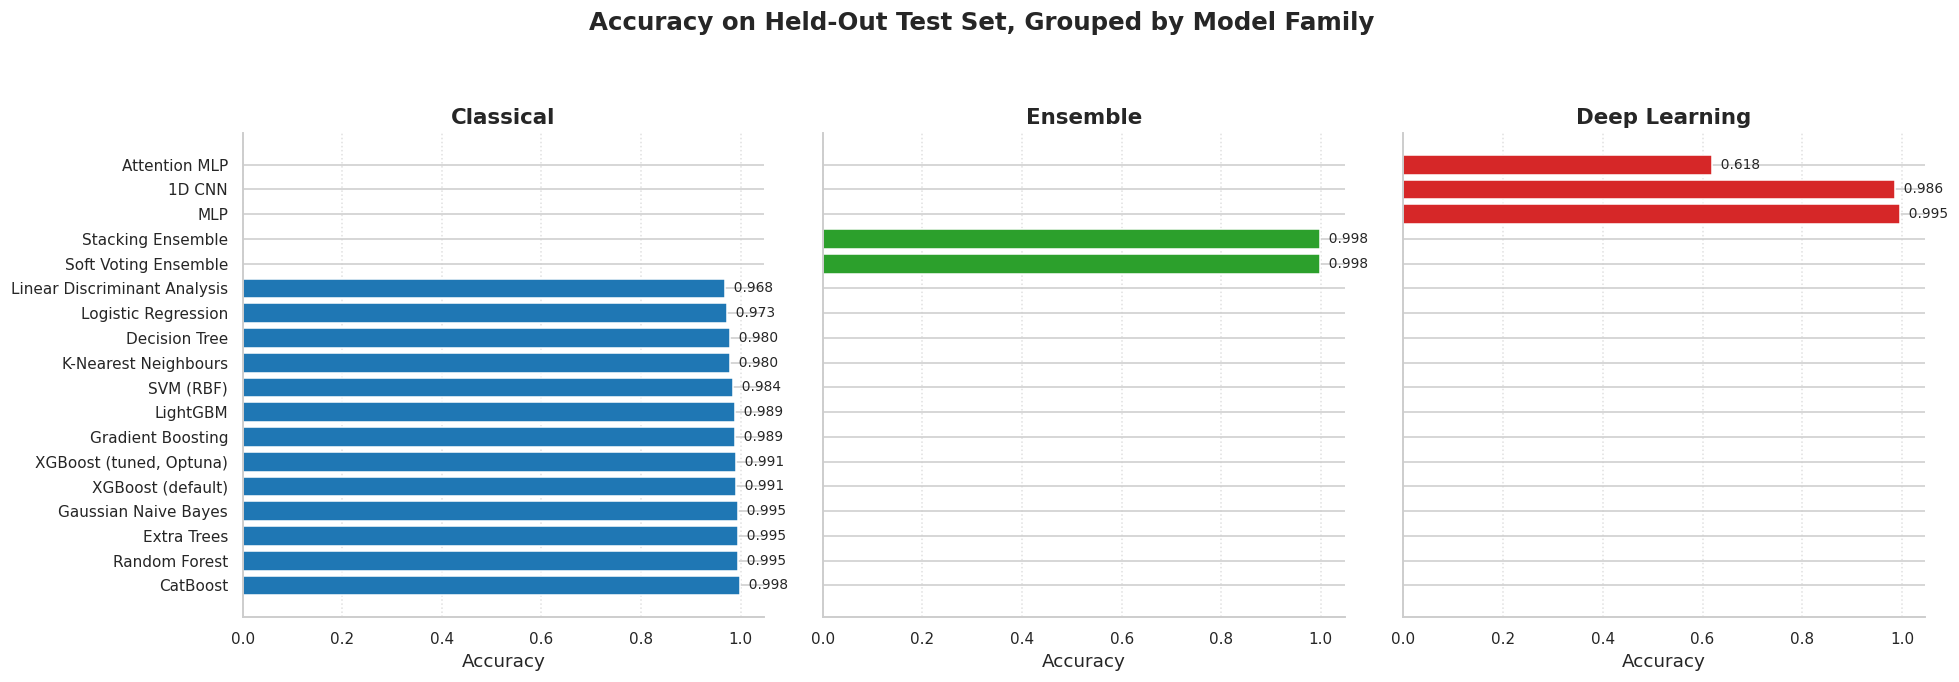

In [ ]:
# Accuracy
grouped_bar_chart(results_df, "accuracy",
                  "Accuracy on Held-Out Test Set, Grouped by Model Family",
                  "Accuracy", savename="metric_accuracy.png")


   💾 Saved → /content/figures/metric_precision.png


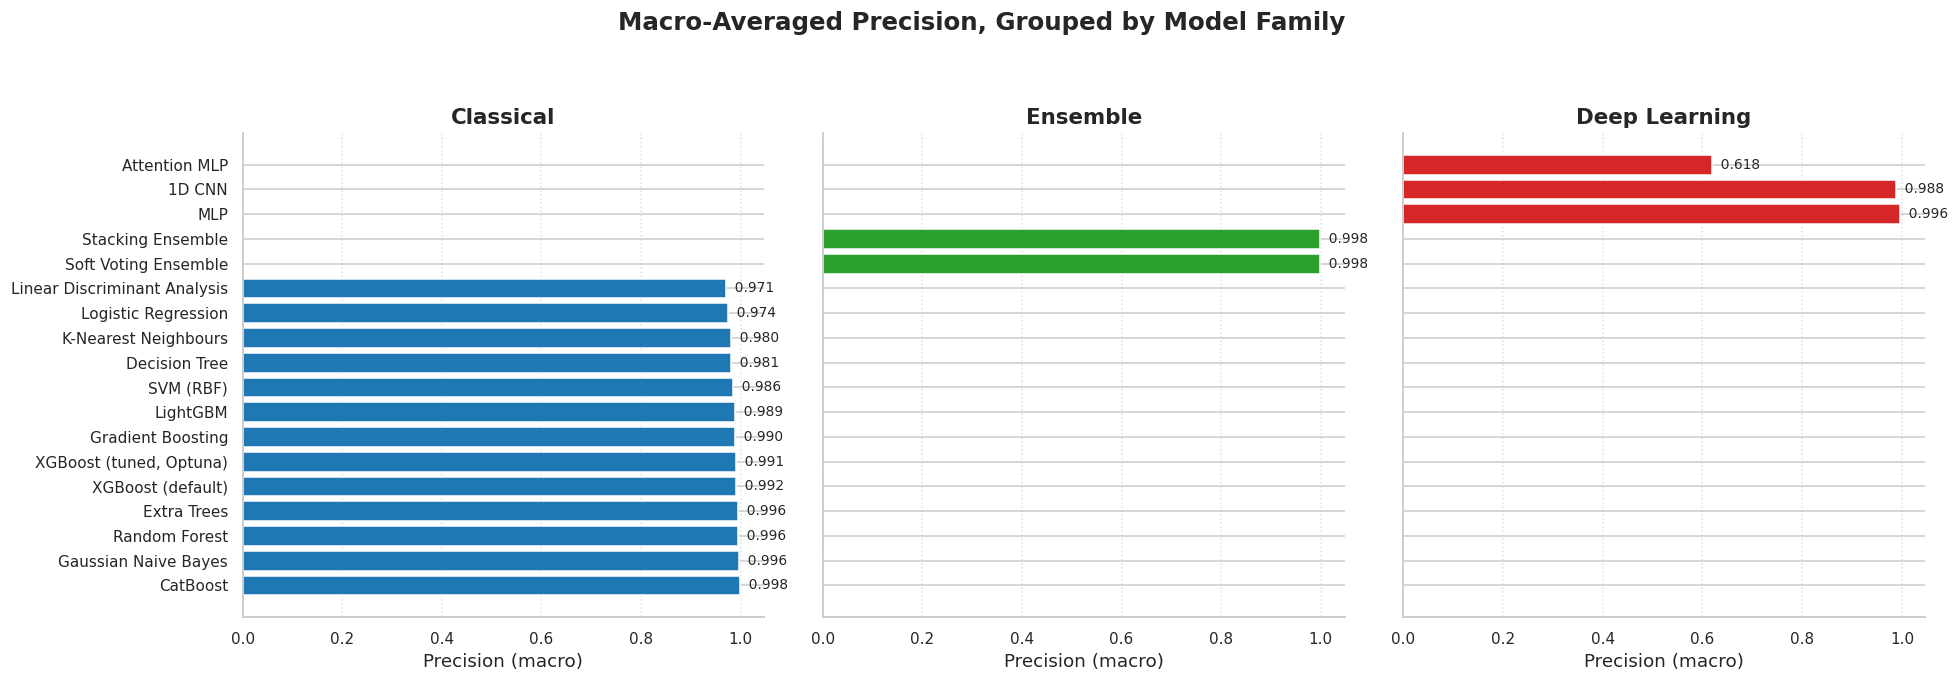

In [ ]:
# Precision (macro)
grouped_bar_chart(results_df, "precision_macro",
                  "Macro-Averaged Precision, Grouped by Model Family",
                  "Precision (macro)", savename="metric_precision.png")


   💾 Saved → /content/figures/metric_recall.png


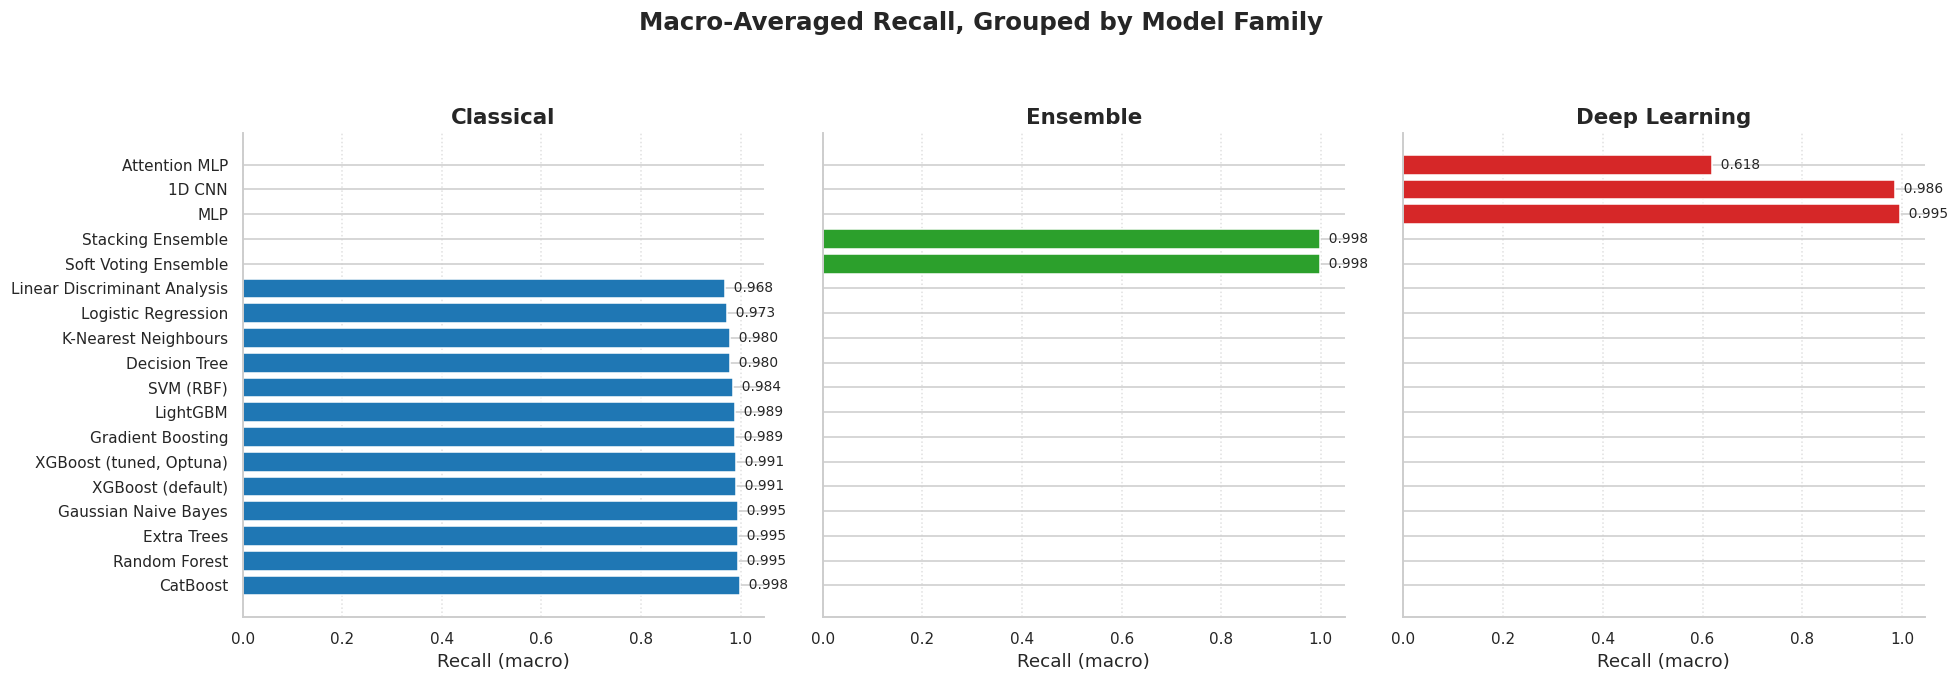

In [ ]:
# Recall (macro)
grouped_bar_chart(results_df, "recall_macro",
                  "Macro-Averaged Recall, Grouped by Model Family",
                  "Recall (macro)", savename="metric_recall.png")


   💾 Saved → /content/figures/metric_f1.png


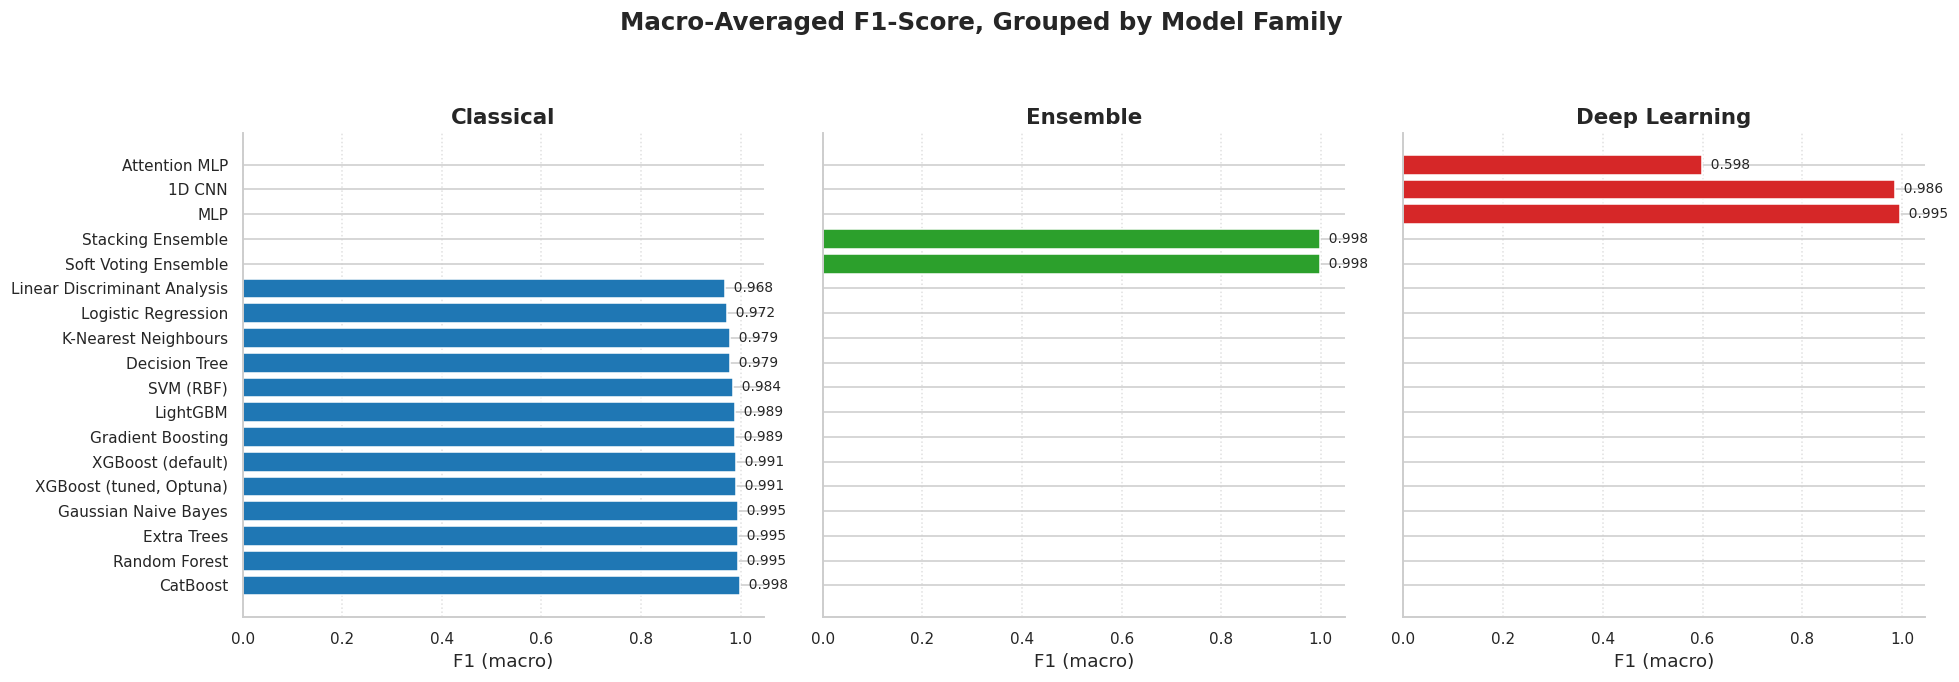

In [ ]:
# F1 (macro)
grouped_bar_chart(results_df, "f1_macro",
                  "Macro-Averaged F1-Score, Grouped by Model Family",
                  "F1 (macro)", savename="metric_f1.png")


   💾 Saved → /content/figures/metric_mcc.png


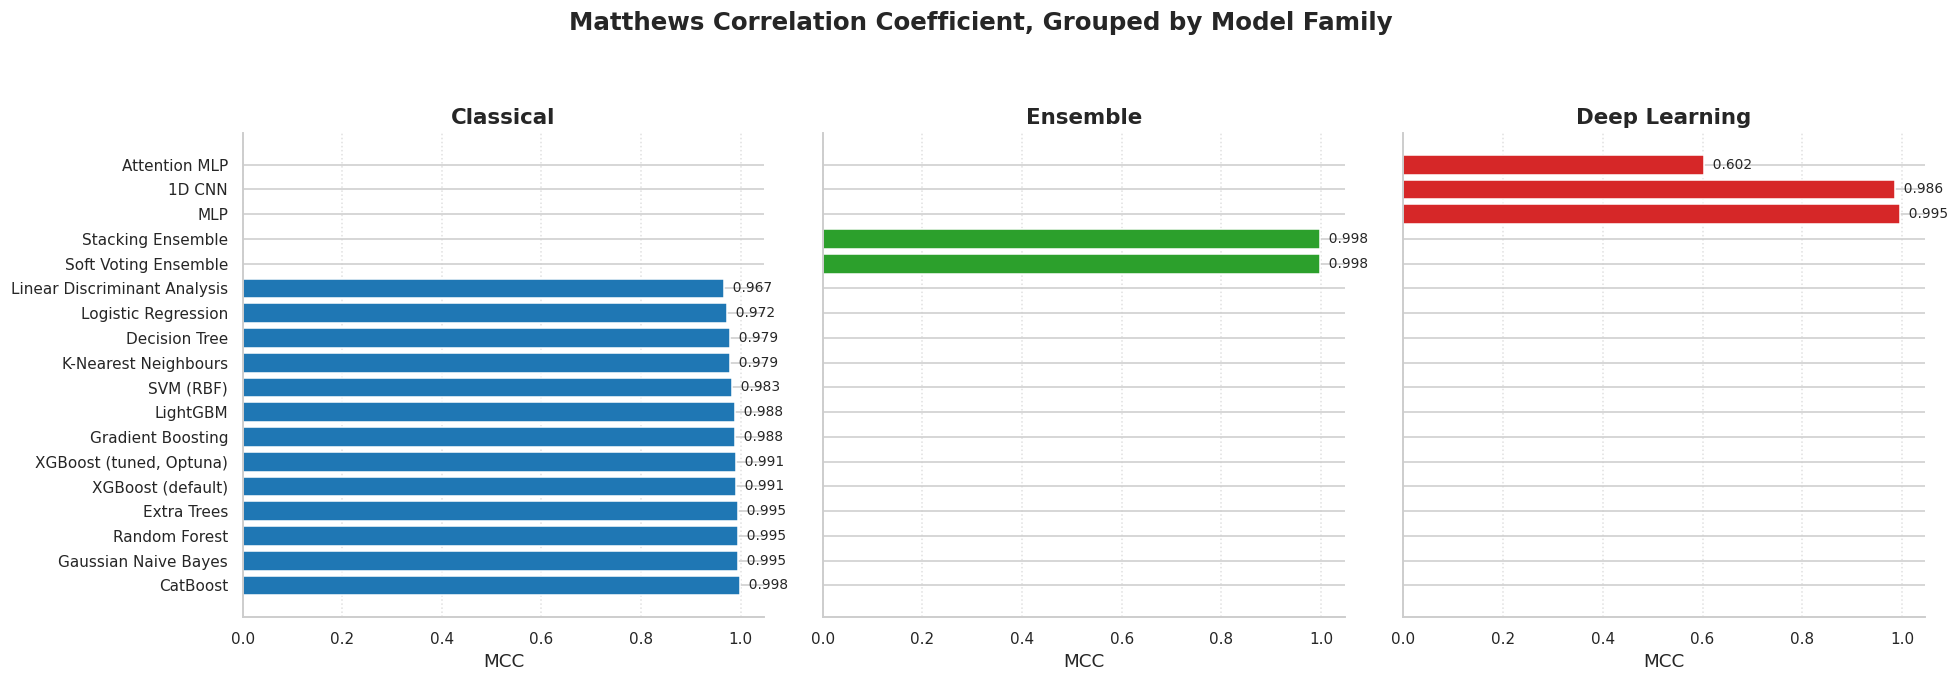

In [ ]:
# Matthews Correlation Coefficient
grouped_bar_chart(results_df, "mcc",
                  "Matthews Correlation Coefficient, Grouped by Model Family",
                  "MCC", savename="metric_mcc.png")


   💾 Saved → /content/figures/metric_roc_auc.png


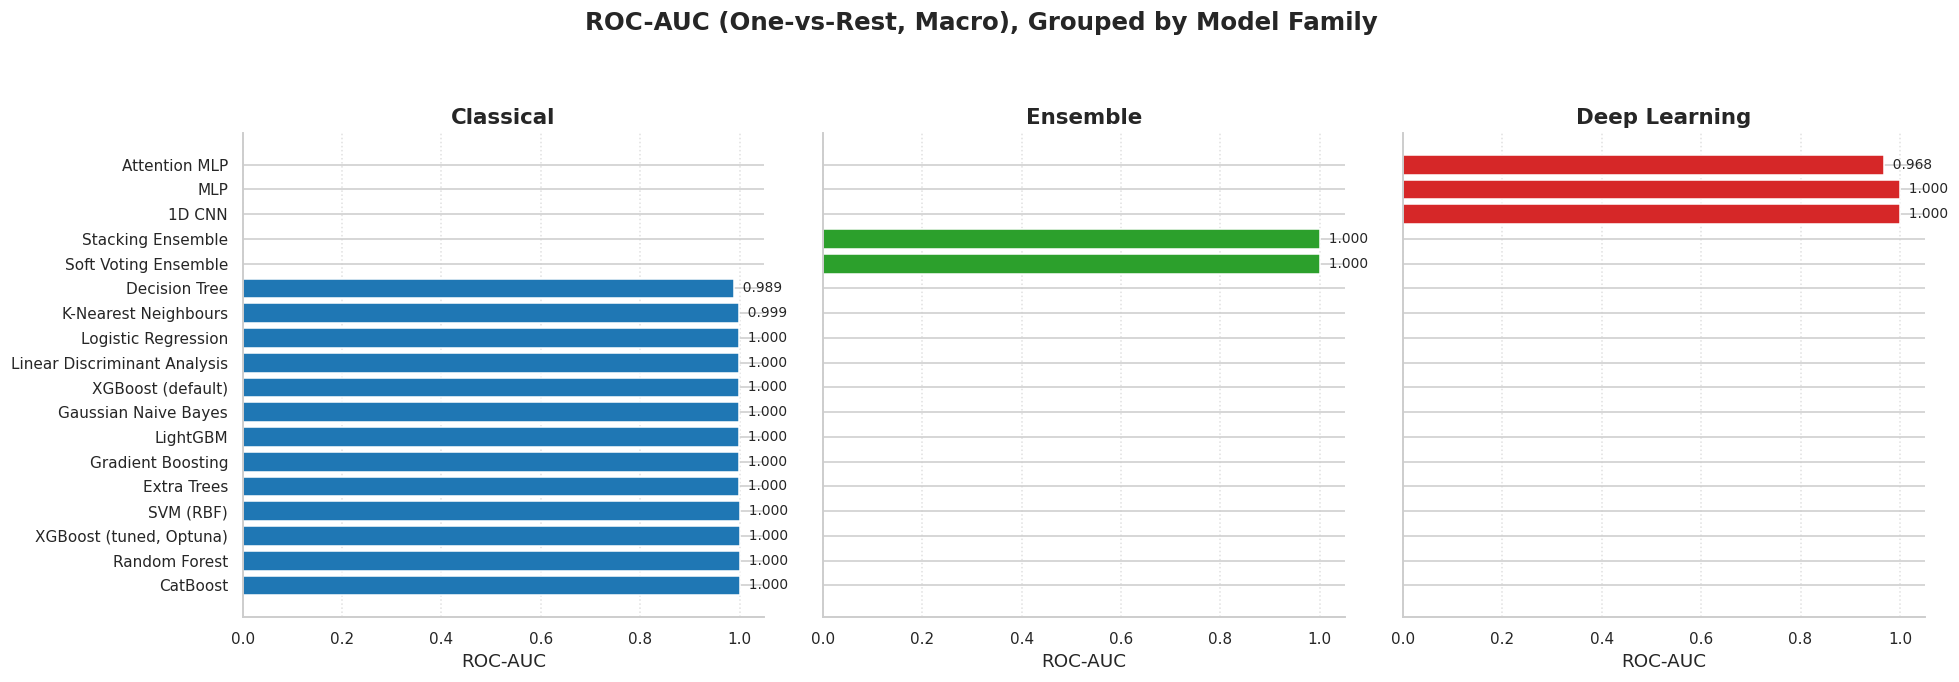

In [ ]:
# ROC-AUC (one-vs-rest, macro)
grouped_bar_chart(results_df, "roc_auc_ovr_macro",
                  "ROC-AUC (One-vs-Rest, Macro), Grouped by Model Family",
                  "ROC-AUC", savename="metric_roc_auc.png")


   💾 Saved → /content/figures/metric_training_time.png


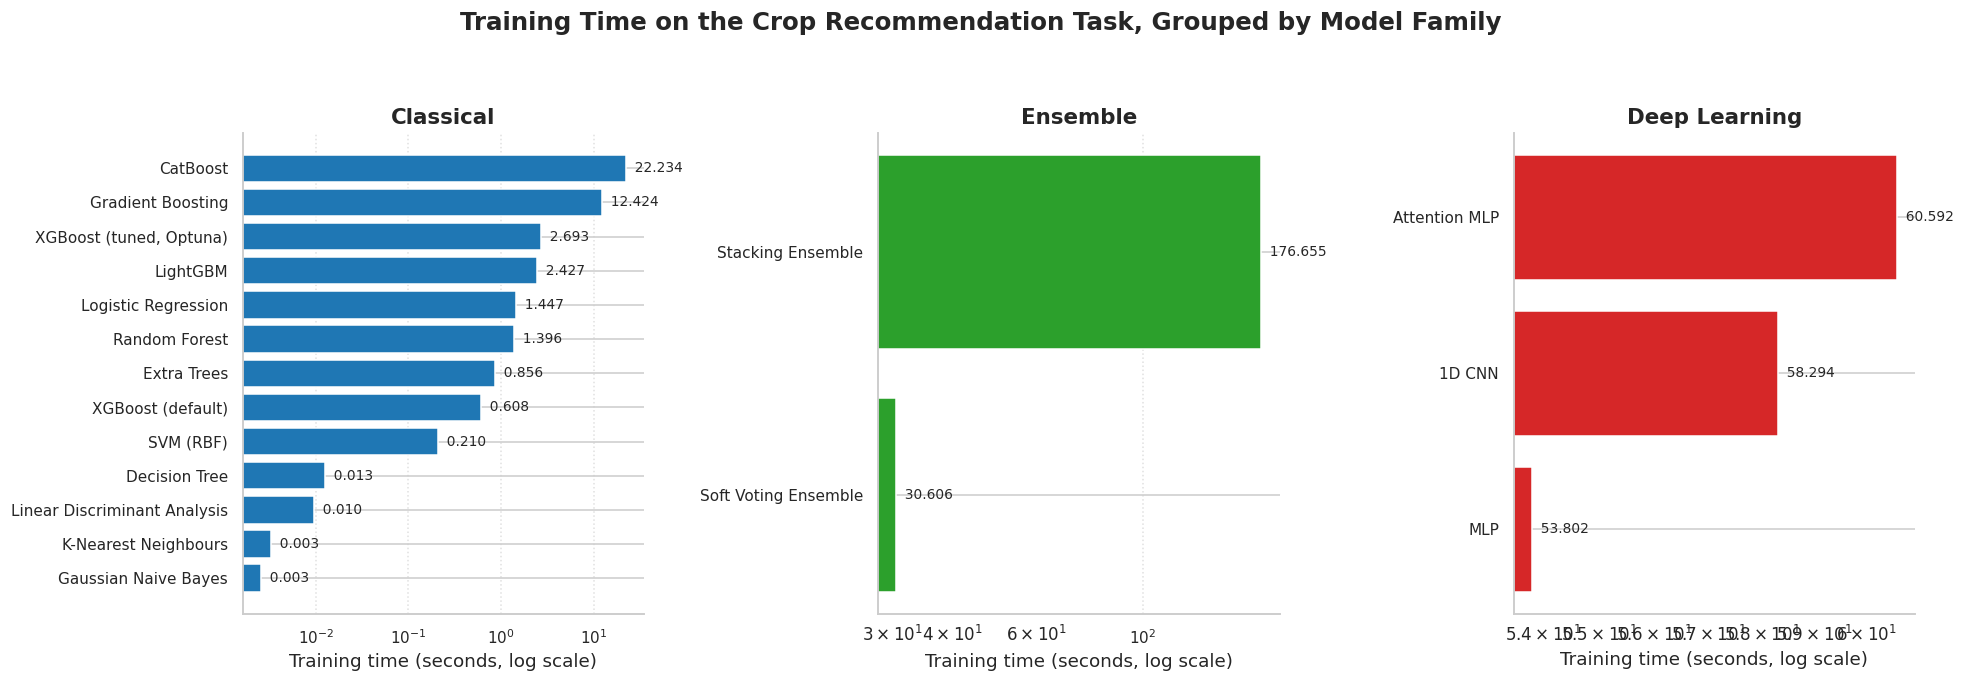

In [ ]:
# Training time (log scale because it spans 4 orders of magnitude)
grouped_bar_chart(results_df, "training_time_s",
                  "Training Time on the Crop Recommendation Task, Grouped by Model Family",
                  "Training time (seconds, log scale)",
                  ascending_within_group=True, log_y=True,
                  savename="metric_training_time.png")


   💾 Saved → /content/figures/metric_inference_latency.png


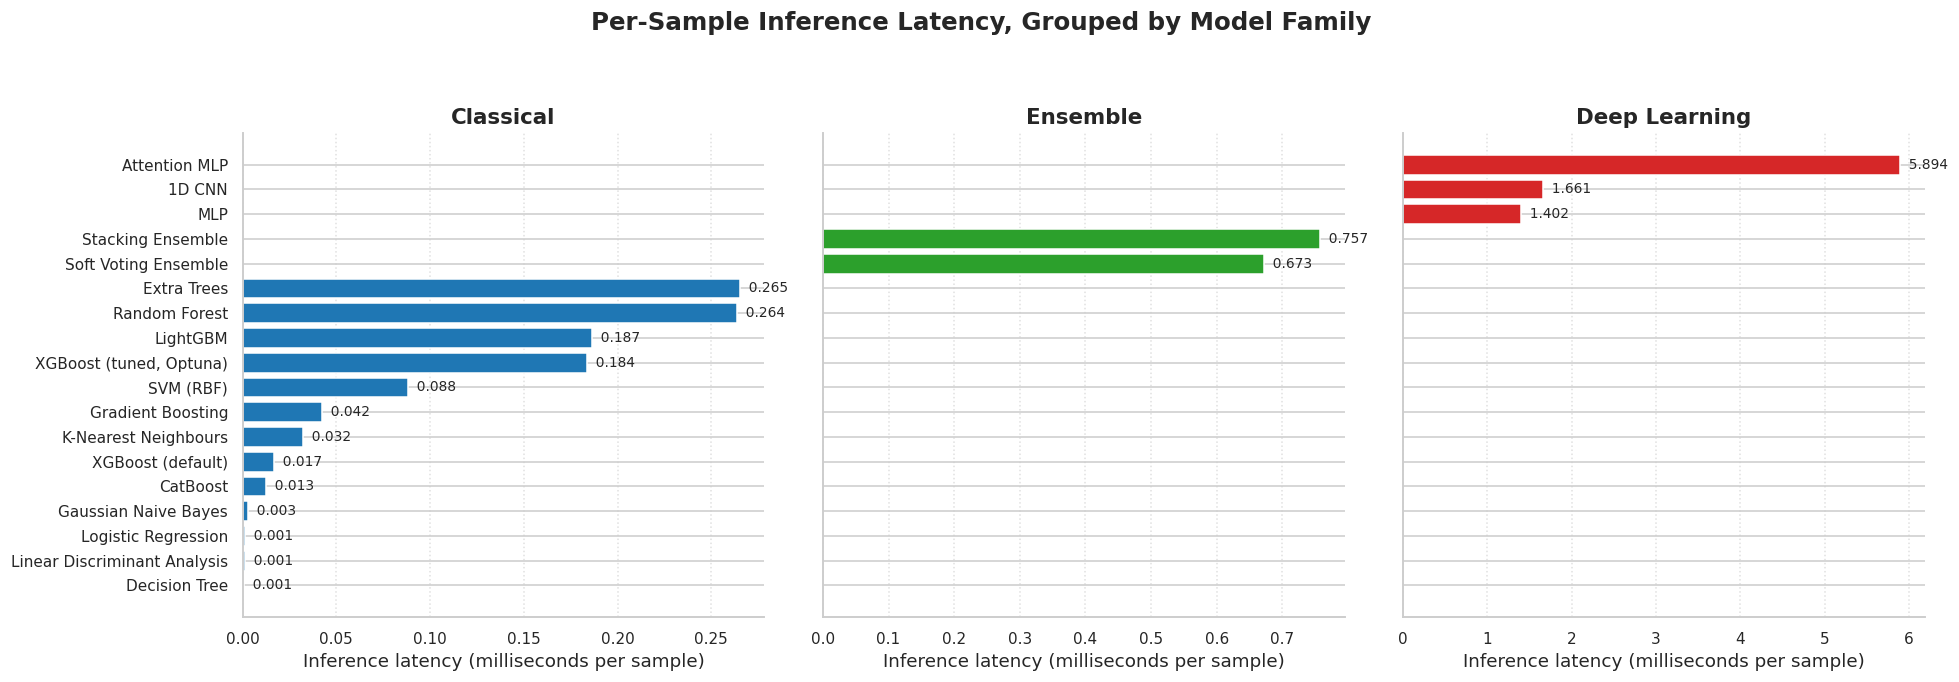

In [ ]:
# Inference latency
grouped_bar_chart(results_df, "inference_latency_ms",
                  "Per-Sample Inference Latency, Grouped by Model Family",
                  "Inference latency (milliseconds per sample)",
                  ascending_within_group=True,
                  savename="metric_inference_latency.png")


# SECTION 18 — Confusion Matrices for All 17 Models

For each model we plot the 22 × 22 confusion matrix on the held-out test set. The matrices are arranged in a grid so the reader can visually compare error patterns across families.

A perfect classifier would have a strong diagonal and empty off-diagonal cells.


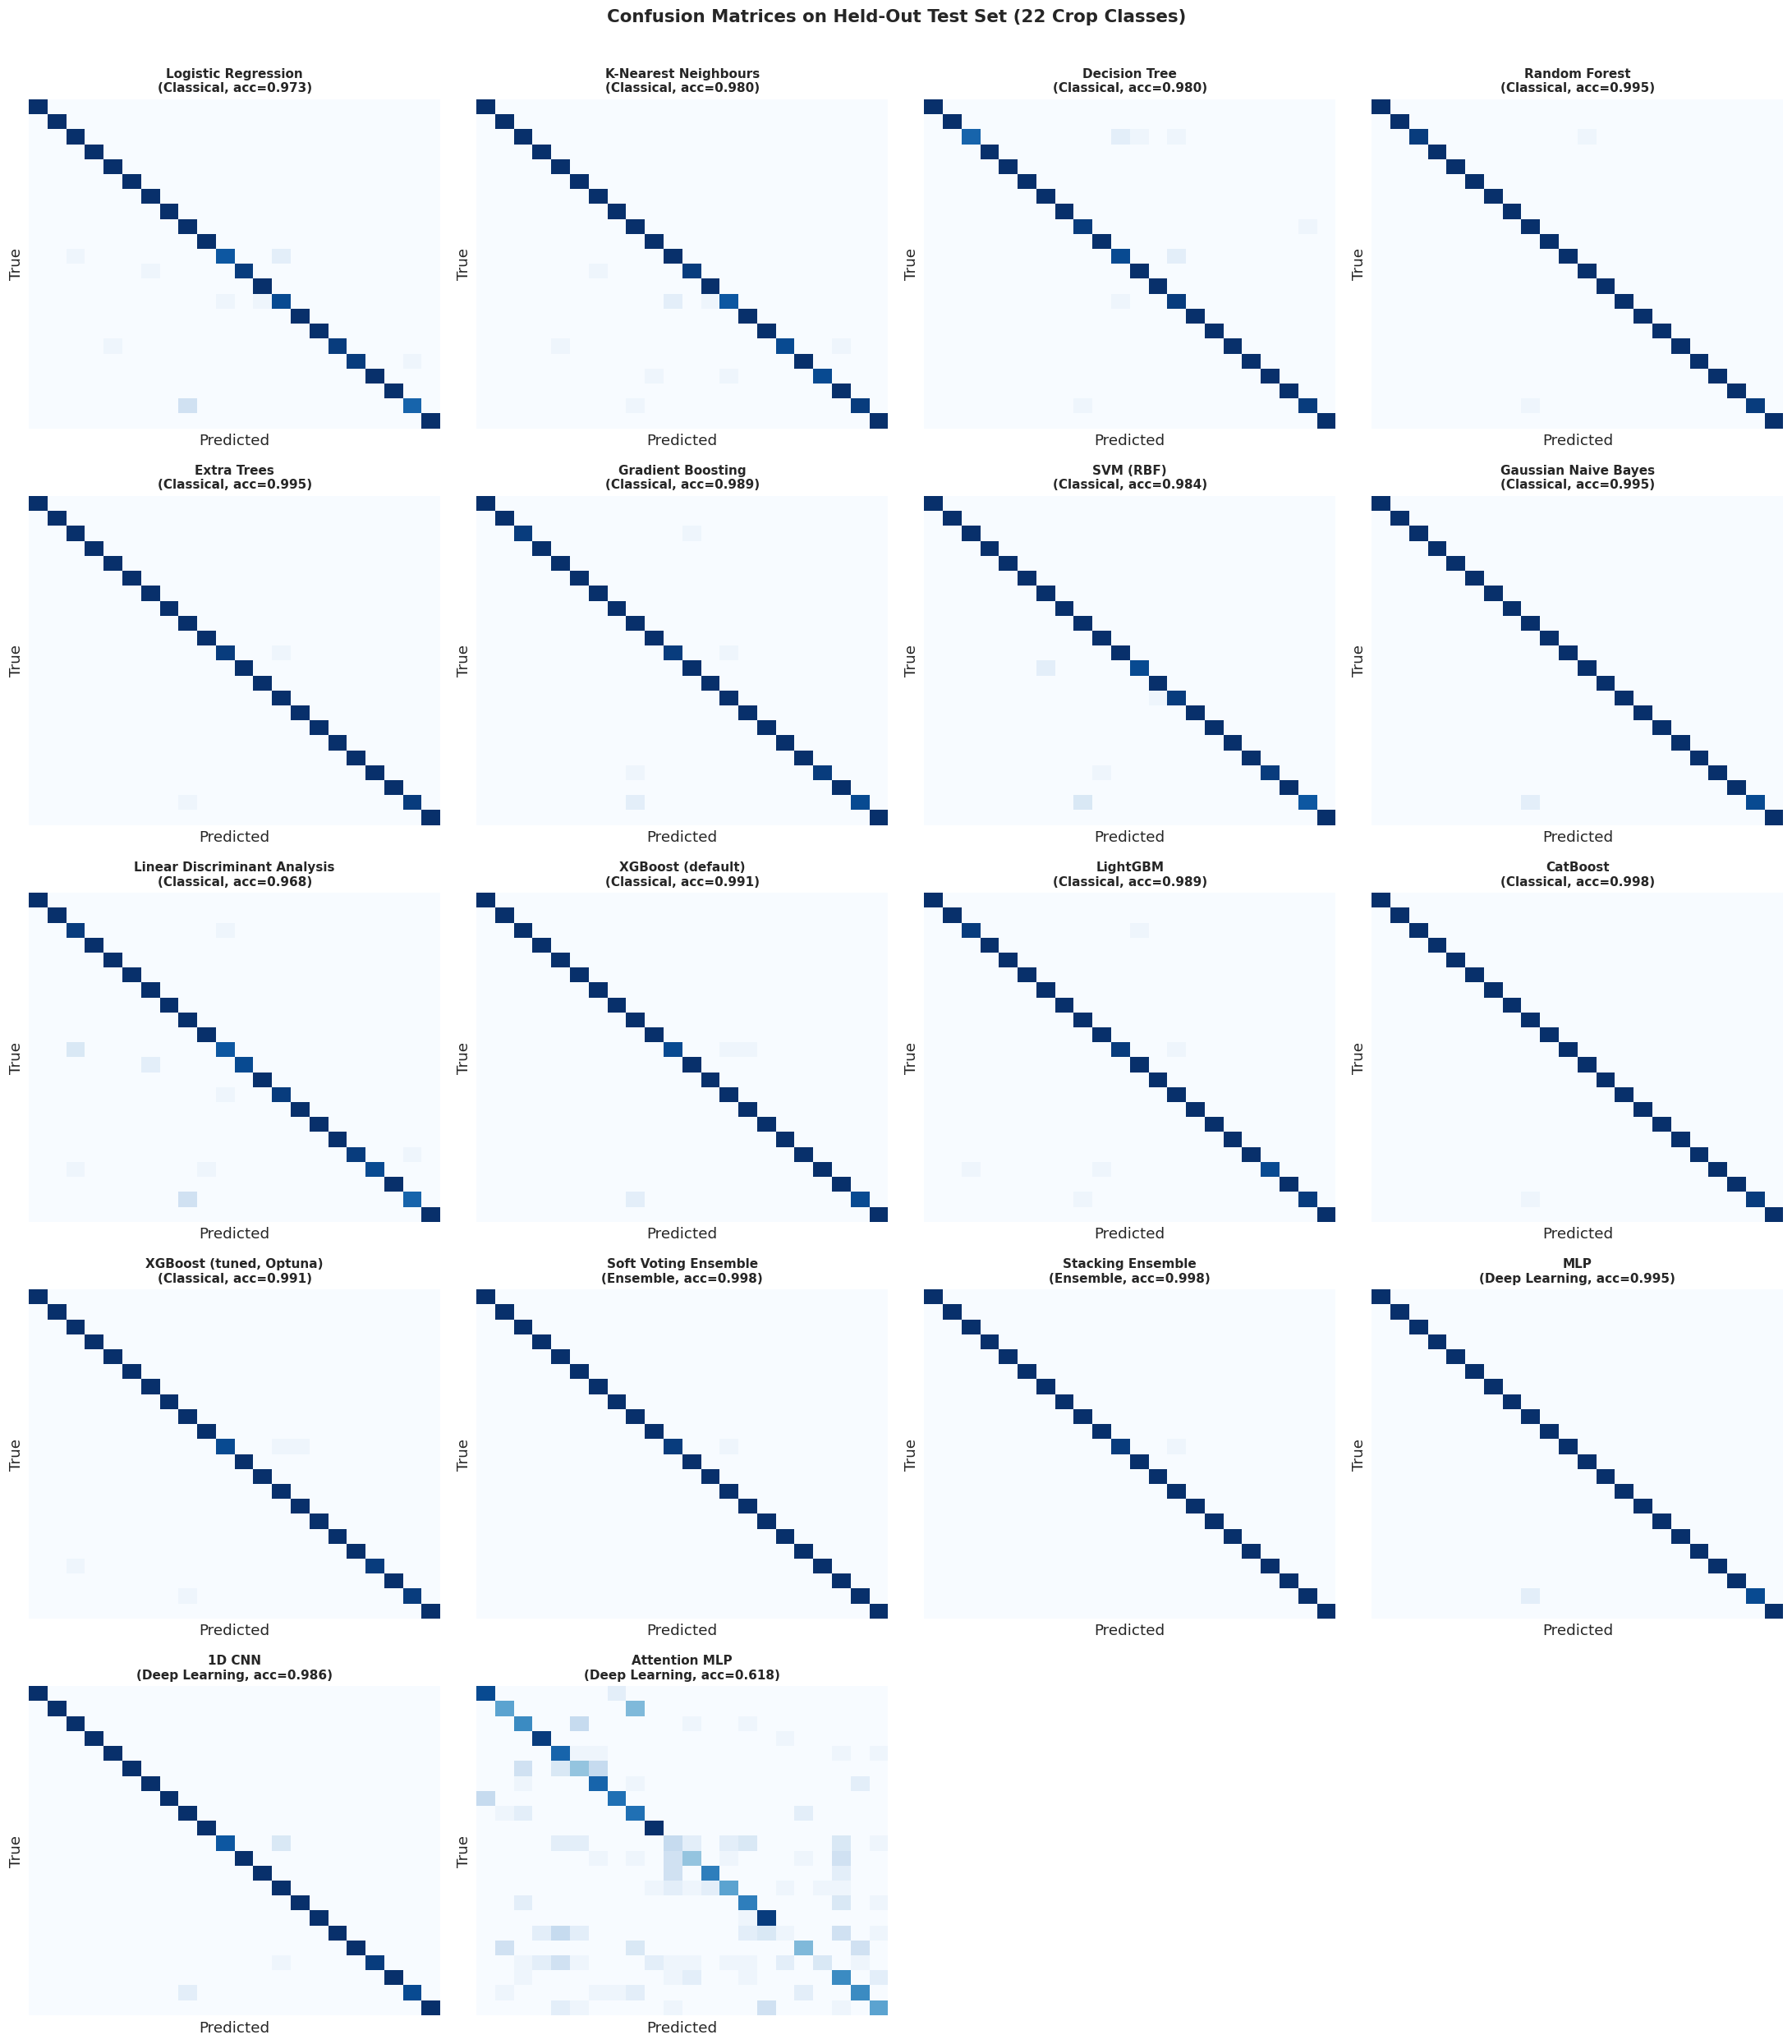

In [ ]:
# Confusion matrix grid (all 17 models on the same figure)
n_models = len(results)
n_cols   = 4
n_rows   = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows))
axes = axes.flatten()
class_labels = le.classes_

for i, r in enumerate(results):
    ax = axes[i]
    cm = confusion_matrix(r["_y_test"], r["_y_pred"])
    sns.heatmap(cm, ax=ax, cmap="Blues", cbar=False,
                xticklabels=False, yticklabels=False)
    ax.set_title(f"{r['model']}\n({r['group']}, acc={r['accuracy']:.3f})",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

# Hide unused panels
for j in range(n_models, len(axes)):
    axes[j].axis("off")

plt.suptitle("Confusion Matrices on Held-Out Test Set (22 Crop Classes)",
             fontsize=14, fontweight="bold", y=1.005)
plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrices_all17.png", dpi=300, bbox_inches="tight")
plt.show()


   💾 Saved → /content/figures/figure_36_confusion_matrix_catboost_only.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

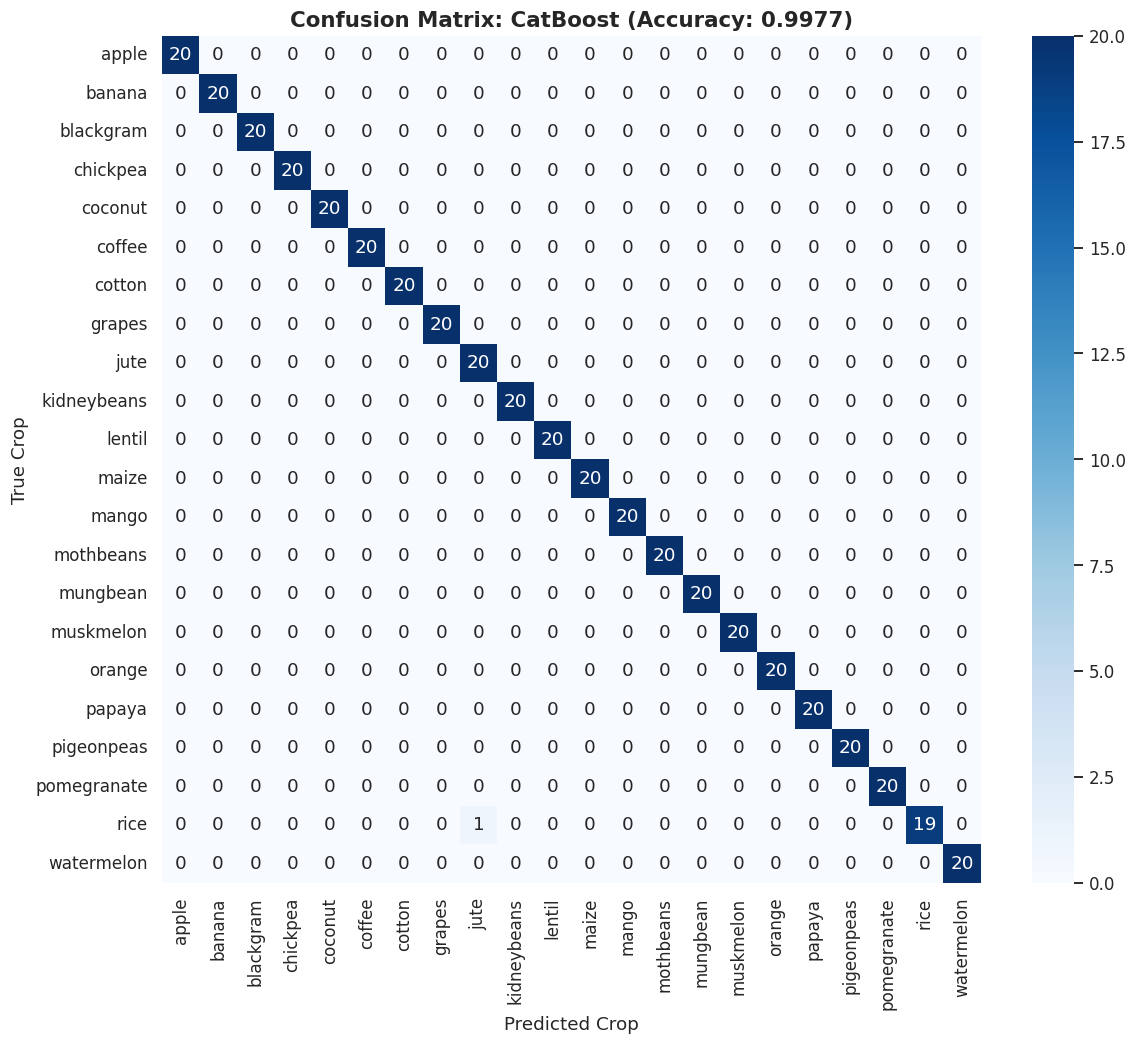

In [ ]:
# CELL: Confusion Matrix for Best Model (CatBoost)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Best performing model: CatBoost
best_model_name = "CatBoost"
best_rec = next(r for r in results if r["model"] == best_model_name)

# Compute and plot
plt.figure(figsize=(12, 10))
cm_cat = confusion_matrix(best_rec["_y_test"], best_rec["_y_pred"])
sns.heatmap(cm_cat, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f"Confusion Matrix: {best_model_name} (Accuracy: {best_rec['accuracy']:.4f})", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Crop")
plt.ylabel("True Crop")
plt.xticks(rotation=90)
save_fig("confusion_matrix_catboost_only")
plt.show()

In [ ]:
# for testing

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# Best-performing model (CatBoost)
# -------------------------------
best_model_name = "CatBoost"

# Retrieve CatBoost results
best_rec = next(r for r in results if r["model"] == best_model_name)

# Compute confusion matrix
cm = confusion_matrix(best_rec["_y_test"], best_rec["_y_pred"])

# Plot
plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.4,
    linecolor="gray",
    square=True,
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cbar=True
)

plt.title(
    f"Confusion Matrix for the Best Performing Crop Recommendation Model (CatBoost)\n"
    f"Accuracy = {best_rec['accuracy']:.4f}",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Predicted Crop Class", fontsize=12, fontweight="bold")
plt.ylabel("True Crop Class", fontsize=12, fontweight="bold")

plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "catboost_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

   💾 Saved → /content/figures/figure_37_confusion_matrices_top4.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

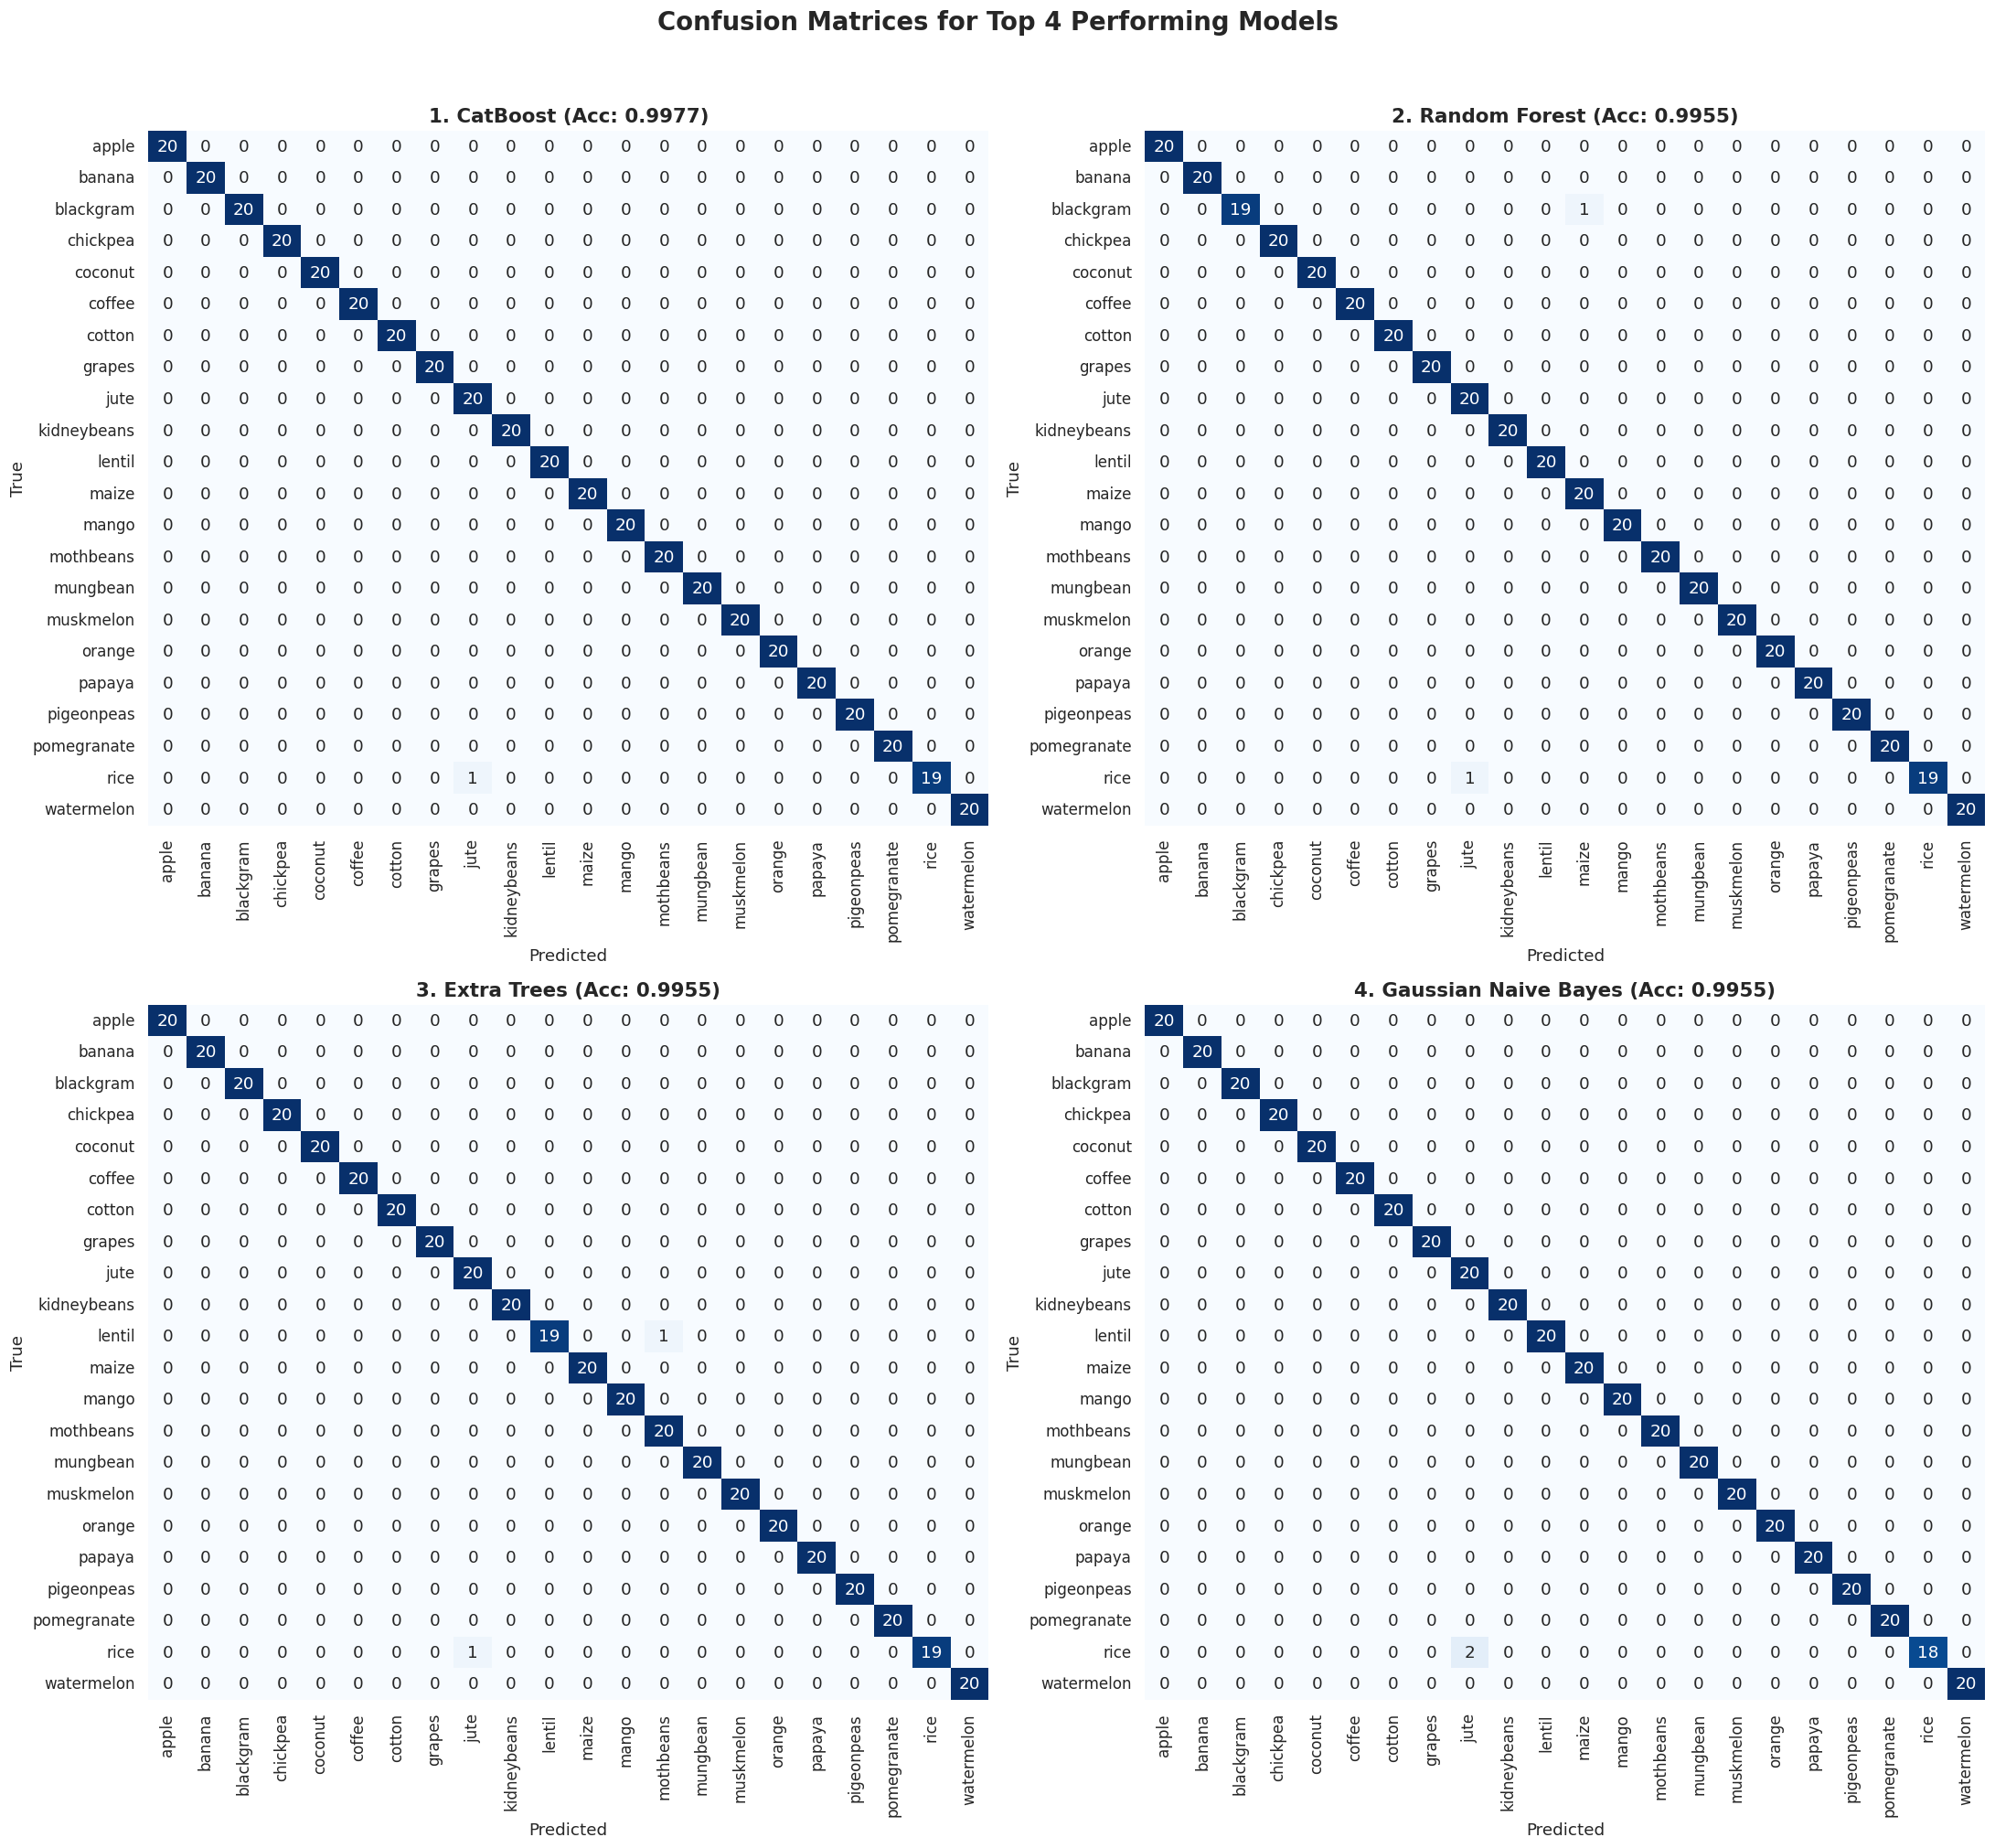

In [ ]:
# CELL: Confusion Matrices for Top 4 Models
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Identify top 4 models by accuracy from the results dataframe
top_4_names = results_df.head(4)['model'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(20, 18))
axes = axes.flatten()

for i, name in enumerate(top_4_names):
    # Get result record
    rec = next(r for r in results if r['model'] == name)
    cm = confusion_matrix(rec['_y_test'], rec['_y_pred'])

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_,
                ax=axes[i], cbar=False)

    axes[i].set_title(f"{i+1}. {name} (Acc: {rec['accuracy']:.4f})", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("True")
    axes[i].tick_params(axis='x', rotation=90)

plt.suptitle("Confusion Matrices for Top 4 Performing Models", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig("confusion_matrices_top4")
plt.show()

In [ ]:
# Per-class F1 for the top-3 models (Section 16 sort puts them first)
top3 = results_df.head(3)["model"].tolist()
print("Per-class F1 for the top-3 models on the held-out test set:")
for name in top3:
    rec = next(r for r in results if r["model"] == name)
    f1_per = f1_score(rec["_y_test"], rec["_y_pred"], average=None)
    print(f"\n{name}")
    for cls, score in zip(le.classes_, f1_per):
        print(f"  {cls:<14s} {score:.4f}")


Per-class F1 for the top-3 models on the held-out test set:

CatBoost
  apple          1.0000
  banana         1.0000
  blackgram      1.0000
  chickpea       1.0000
  coconut        1.0000
  coffee         1.0000
  cotton         1.0000
  grapes         1.0000
  jute           0.9756
  kidneybeans    1.0000
  lentil         1.0000
  maize          1.0000
  mango          1.0000
  mothbeans      1.0000
  mungbean       1.0000
  muskmelon      1.0000
  orange         1.0000
  papaya         1.0000
  pigeonpeas     1.0000
  pomegranate    1.0000
  rice           0.9744
  watermelon     1.0000

Random Forest
  apple          1.0000
  banana         1.0000
  blackgram      0.9744
  chickpea       1.0000
  coconut        1.0000
  coffee         1.0000
  cotton         1.0000
  grapes         1.0000
  jute           0.9756
  kidneybeans    1.0000
  lentil         1.0000
  maize          0.9756
  mango          1.0000
  mothbeans      1.0000
  mungbean       1.0000
  muskmelon      1.0000
  o

# SECTION 19 — SHAP Explainability on the Tuned XGBoost Model

SHAP (SHapley Additive exPlanations) opens the black box. For any single prediction it decomposes the answer into per-feature contributions whose values sum to the model output.

Three SHAP outputs are produced:

1. **Global feature importance bar chart** — mean absolute SHAP value across every feature and every test sample, ranking the seven inputs by overall influence.
2. **Beeswarm plot** for one crop class (rice by default) — every dot is one test sample; the colour shows the feature's value and the horizontal position shows the SHAP contribution.
3. **Waterfall plot** for one specific prediction — for one sample, broken down feature by feature, so a reader can see exactly how the model reached that crop.

SHAP is computed with `TreeExplainer`, which is exact and fast for tree-based models.


In [ ]:
# Compute SHAP values on the tuned XGBoost
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_s)

# Newer SHAP versions return a (n_classes, n_samples, n_features) array
shap_arr = np.array(shap_values)
print("SHAP values shape :", shap_arr.shape)


SHAP values shape : (440, 7, 22)


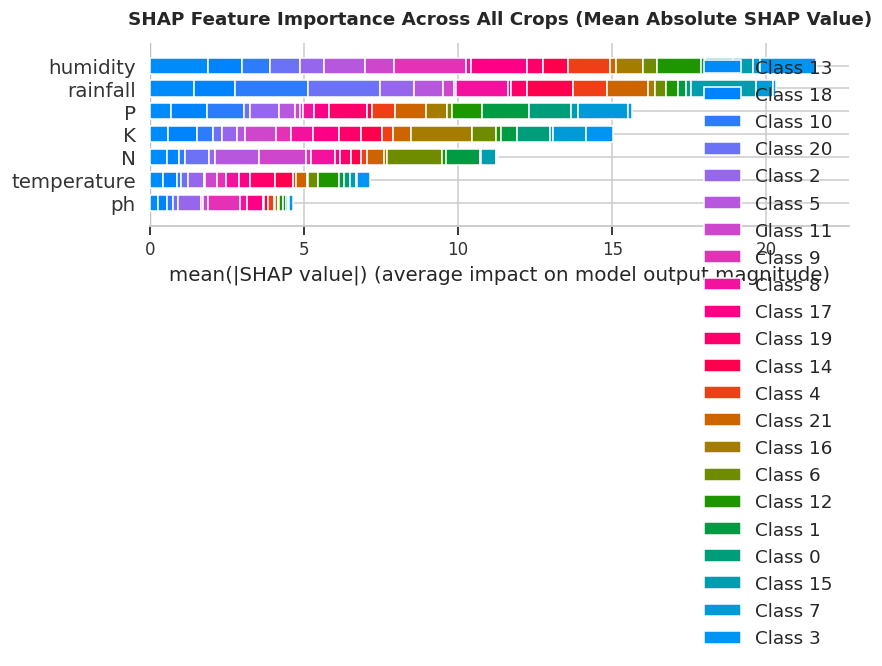

In [ ]:
# Global feature importance (mean |SHAP| across all classes and samples)
plt.figure()
shap.summary_plot(shap_values, X_test_s, feature_names=features,
                  plot_type="bar", show=False)
plt.title("SHAP Feature Importance Across All Crops (Mean Absolute SHAP Value)",
          fontsize=12, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "shap_global_importance.png", dpi=300, bbox_inches="tight")
plt.show()


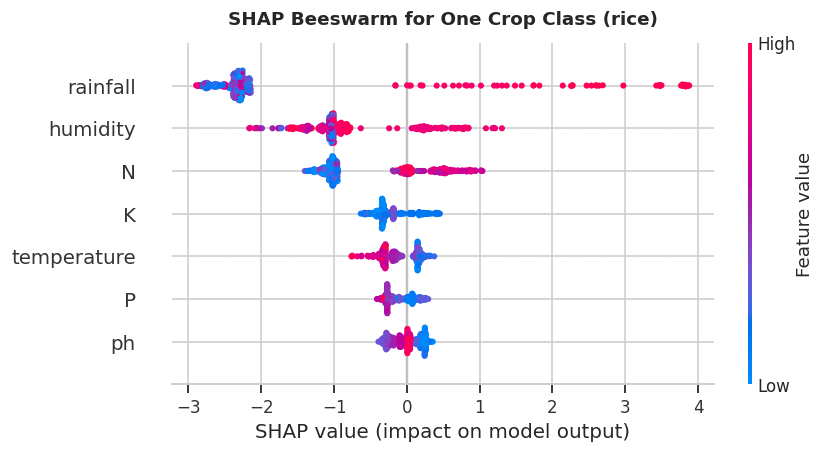

In [ ]:
# Beeswarm plot for one crop class (default: rice)
target_crop = "rice"
if target_crop in le.classes_:
    cls_idx = list(le.classes_).index(target_crop)
else:
    cls_idx = 0
    target_crop = le.classes_[0]

# Newer SHAP shap_values may be 3-D: (samples, features, classes) OR (classes, samples, features)
def select_class_shap(shap_values, cls_idx):
    arr = np.array(shap_values)
    if arr.ndim == 3:
        # Decide axis: try (classes, samples, features) first
        if arr.shape[0] == NUM_CLASSES:
            return arr[cls_idx]
        elif arr.shape[2] == NUM_CLASSES:
            return arr[:, :, cls_idx]
    return arr

shap_one_class = select_class_shap(shap_values, cls_idx)

plt.figure()
shap.summary_plot(shap_one_class, X_test_s, feature_names=features, show=False)
plt.title(f"SHAP Beeswarm for One Crop Class ({target_crop})",
          fontsize=12, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(FIG_DIR / f"shap_beeswarm_{target_crop}.png", dpi=300, bbox_inches="tight")
plt.show()


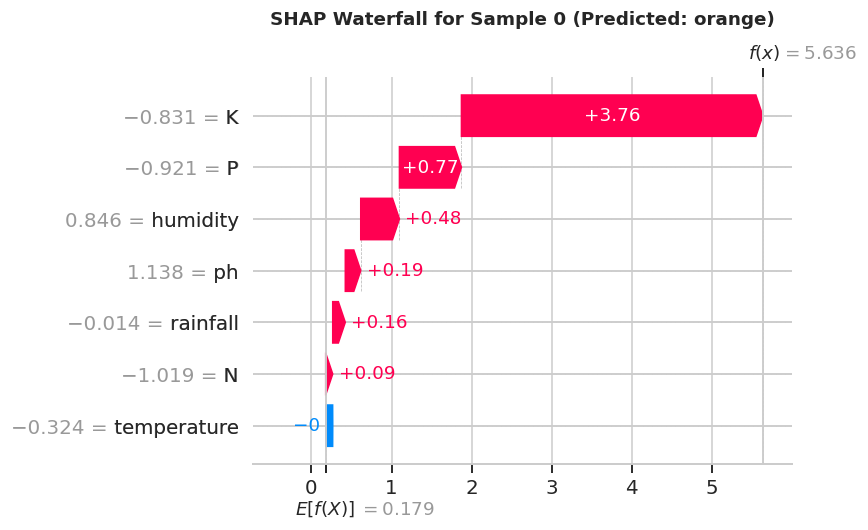

In [ ]:
# Waterfall plot for one specific prediction
sample_idx = 0
proba_sample = best_xgb.predict_proba(X_test_s[sample_idx:sample_idx+1])[0]
pred_class_idx = int(np.argmax(proba_sample))
pred_class_name = le.classes_[pred_class_idx]

shap_pred_class = select_class_shap(shap_values, pred_class_idx)
expected = explainer.expected_value
if isinstance(expected, (list, np.ndarray)) and len(np.atleast_1d(expected)) > 1:
    base_val = float(np.atleast_1d(expected)[pred_class_idx])
else:
    base_val = float(np.atleast_1d(expected)[0])

explanation = shap.Explanation(
    values=shap_pred_class[sample_idx],
    base_values=base_val,
    data=X_test_s[sample_idx],
    feature_names=features,
)

plt.figure()
shap.waterfall_plot(explanation, show=False)
plt.title(f"SHAP Waterfall for Sample 0 (Predicted: {pred_class_name})",
          fontsize=12, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(FIG_DIR / f"shap_waterfall_sample0_{pred_class_name}.png",
            dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# @title 🧠 SHAP Feature Importance Dashboard {display-mode: "form"}

import json
import numpy as np
import pandas as pd
from IPython.display import HTML
from google.colab import output

# Prepare SHAP data for the dashboard
# shap_arr shape is (n_samples, n_features, n_classes)

# Calculate Global Importance (Mean Absolute SHAP across all samples and classes)
global_importance = np.abs(shap_arr).mean(axis=(0, 2))
global_data = []
for i, feat in enumerate(features):
    global_data.append({"feature": feat, "importance": float(global_importance[i])})

# Calculate Per-Class Importance
class_importance_data = {}
for idx, class_name in enumerate(le.classes_):
    # Mean absolute SHAP for this specific class
    class_vals = np.abs(shap_arr[:, :, idx]).mean(axis=0)
    class_importance_data[class_name] = [
        {"feature": feat, "val": float(class_vals[i])}
        for i, feat in enumerate(features)
    ]

json_global = json.dumps(global_data)
json_classes = json.dumps(class_importance_data)

html_code = """
<!DOCTYPE html>
<html>
<head>
    <script src=\"https://cdn.jsdelivr.net/npm/chart.js\"></script>
    <link href=\"https://fonts.googleapis.com/css2?family=Inter:wght@400;600;700&display=swap\" rel=\"stylesheet\">
    <style>
        :root {
            --bg-color: #f4f6f8;
            --card-bg: #ffffff;
            --primary: #2c3e50;
            --secondary: #7f8c8d;
            --accent: #3498db;
            --shadow: 0 4px 6px rgba(0,0,0,0.05);
        }
        body {
            font-family: 'Inter', sans-serif;
            background-color: var(--bg-color);
            margin: 0; padding: 20px;
            color: var(--primary);
        }
        .container {
            max-width: 1100px;
            margin: 0 auto;
            display: flex;
            flex-direction: column;
            gap: 20px;
        }
        .header { display: flex; justify-content: space-between; align-items: center; }
        .card-grid { display: grid; grid-template-columns: repeat(3, 1fr); gap: 15px; }
        .card {
            background: var(--card-bg);
            padding: 20px; border-radius: 12px;
            box-shadow: var(--shadow); text-align: center;
        }
        .card .label { font-size: 11px; text-transform: uppercase; color: var(--secondary); margin-bottom: 5px; }
        .card .value { font-size: 20px; font-weight: 700; }
        .main-section {
            display: grid; grid-template-columns: 1.5fr 1fr; gap: 20px;
        }
        .chart-container {
            background: var(--card-bg);
            padding: 20px; border-radius: 12px;
            box-shadow: var(--shadow); display: flex; flex-direction: column;
        }
        .canvas-wrapper {
            position: relative; flex-grow: 1; min-height: 350px; min-height: 0;
        }
        select {
            padding: 8px; border-radius: 6px; border: 1px solid #ddd; margin-bottom: 15px;
        }
    </style>
</head>
<body>
    <div class=\"container\">
        <div class=\"header\">
            <h2>Model Explainability (SHAP)</h2>
            <select id=\"classSelector\" onchange=\"updateCharts()\">
                <option value=\"GLOBAL\">Global (All Crops)</option>
            </select>
        </div>

        <div class=\"card-grid\">
            <div class=\"card\">
                <div class=\"label\">Top Driver</div>
                <div id=\"topDriver\" class=\"value\">-</div>
            </div>
            <div class=\"card\">
                <div class=\"label\">Analysis Method</div>
                <div class=\"value\">TreeExplainer</div>
            </div>
            <div class=\"card\">
                <div class=\"label\">Dataset Samples</div>
                <div class=\"value\">440 (Test Set)</div>
            </div>
        </div>

        <div class=\"main-section\">
            <div class=\"chart-container\">
                <div class=\"label\">Feature Impact Magnitude</div>
                <div class=\"canvas-wrapper\">
                    <canvas id=\"shapChart\"></canvas>
                </div>
            </div>
            <div class=\"chart-container\">
                <div class=\"label\">Relative Importance (%)</div>
                <div class=\"canvas-wrapper\">
                    <canvas id=\"pieChart\"></canvas>
                </div>
            </div>
        </div>
    </div>

    <script>
        const globalData = GLOBAL_DATA;
        const classData = CLASS_DATA;
        let mainChart, pieChart;

        const selector = document.getElementById('classSelector');
        Object.keys(classData).forEach(cls => {
            const opt = document.createElement('option');
            opt.value = cls; opt.innerText = cls.charAt(0).toUpperCase() + cls.slice(1);
            selector.appendChild(opt);
        });

        function updateCharts() {
            const selection = selector.value;
            let currentData;

            if (selection === 'GLOBAL') {
                currentData = globalData.map(d => ({feature: d.feature, val: d.importance}));
            } else {
                currentData = classData[selection];
            }

            currentData.sort((a, b) => b.val - a.val);
            document.getElementById('topDriver').innerText = currentData[0].feature;

            const labels = currentData.map(d => d.feature);
            const vals = currentData.map(d => d.val);

            if (mainChart) mainChart.destroy();
            if (pieChart) pieChart.destroy();

            mainChart = new Chart(document.getElementById('shapChart'), {
                type: 'bar',
                data: {
                    labels: labels,
                    datasets: [{
                        label: 'Mean |SHAP|',
                        data: vals,
                        backgroundColor: '#3498db',
                        borderRadius: 4
                    }]
                },
                options: {
                    indexAxis: 'y', responsive: true, maintainAspectRatio: false,
                    plugins: { legend: { display: false } }
                }
            });

            pieChart = new Chart(document.getElementById('pieChart'), {
                type: 'doughnut',
                data: {
                    labels: labels,
                    datasets: [{
                        data: vals,
                        backgroundColor: ['#2ecc71','#3498db','#9b59b6','#f1c40f','#e67e22','#e74c3c','#95a5a6']
                    }]
                },
                options: { responsive: true, maintainAspectRatio: false }
            });
        }

        function _report_js_error(message) {
            google.colab.kernel.invokeFunction('report_js_error', [message], {});
        }
        window.onerror = _report_js_error;

        window.onload = updateCharts;
    </script>
</body>
</html>
""".replace('GLOBAL_DATA', json_global).replace('CLASS_DATA', json_classes)

def report_error(msg):
    print(f"JS Error: {msg}")

try:
    output.register_callback('report_js_error', report_error)
except:
    pass

HTML(html_code)

# SECTION 20 — Irrigation Decision Classifier

The companion task is a binary classifier that decides whether to irrigate now (1) or not (0), based on:
- Crop ID
- Soil type
- Seedling stage
- Current soil moisture index
- Current temperature
- Current humidity

The classifier is built as a scikit-learn `Pipeline` that bundles preprocessing (`ColumnTransformer` with one-hot encoding for categoricals and `StandardScaler` for numerics) together with an XGBoost classifier. Saving the pipeline saves the preprocessing too, so the website can pass raw inputs and the pipeline does everything internally.

The model is evaluated on the same metric battery as the crop recommender (binary classification → ROC-AUC uses the standard two-class form, no `multi_class` argument).


In [ ]:
cat_cols = ["crop_id", "soil_type", "seedling_stage"]
num_cols = ["moi", "temp", "humidity"]
X_irr = smart_df[cat_cols + num_cols].copy()
# Fix: Binarize the 'result' column to treat only 1 as 'irrigate' and others as 'no irrigate'
y_irr = (smart_df["result"] == 1).astype(int).values

X_irr_tr, X_irr_te, y_irr_tr, y_irr_te = train_test_split(
    X_irr, y_irr, test_size=0.20, stratify=y_irr, random_state=SEED,
)

irr_preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

irrigation_pipeline = Pipeline([
    ("prep", irr_preprocess),
    ("xgb",  xgb.XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.1,
        tree_method="hist", random_state=SEED, n_jobs=-1,
        eval_metric="logloss", verbosity=0,
    )),
])
print("Train shape:", X_irr_tr.shape, "Test shape:", X_irr_te.shape)

Train shape: (13128, 6) Test shape: (3283, 6)


In [ ]:
t0 = time.perf_counter()
irrigation_pipeline.fit(X_irr_tr, y_irr_tr)
irr_train_time = time.perf_counter() - t0

t0 = time.perf_counter()
y_irr_pred = irrigation_pipeline.predict(X_irr_te)
irr_pred_time = time.perf_counter() - t0
irr_proba = irrigation_pipeline.predict_proba(X_irr_te)
irr_latency_ms = (irr_pred_time / len(X_irr_te)) * 1000.0

irr_metrics = {
    "model":               "Irrigation XGBoost Pipeline",
    "group":               "Binary Classifier",
    "device":              CPU_DEVICE,
    "accuracy":            accuracy_score(y_irr_te, y_irr_pred),
    "precision_macro":     precision_score(y_irr_te, y_irr_pred, average="macro"),
    "recall_macro":        recall_score(y_irr_te,   y_irr_pred, average="macro"),
    "f1_macro":            f1_score(y_irr_te,       y_irr_pred, average="macro"),
    "mcc":                 matthews_corrcoef(y_irr_te, y_irr_pred),
    "roc_auc":             roc_auc_score(y_irr_te, irr_proba, multi_class='ovr', average='macro'),
    "training_time_s":     irr_train_time,
    "inference_latency_ms":irr_latency_ms,
}
for k, v in irr_metrics.items():
    if isinstance(v, float):
        print(f"  {k:<22s} {v:.4f}")
    else:
        print(f"  {k:<22s} {v}")

  model                  Irrigation XGBoost Pipeline
  group                  Binary Classifier
  device                 CPU
  accuracy               0.9997
  precision_macro        0.9985
  recall_macro           0.9997
  f1_macro               0.9991
  mcc                    0.9994
  roc_auc                1.0000
  training_time_s        4.3023
  inference_latency_ms   0.0632


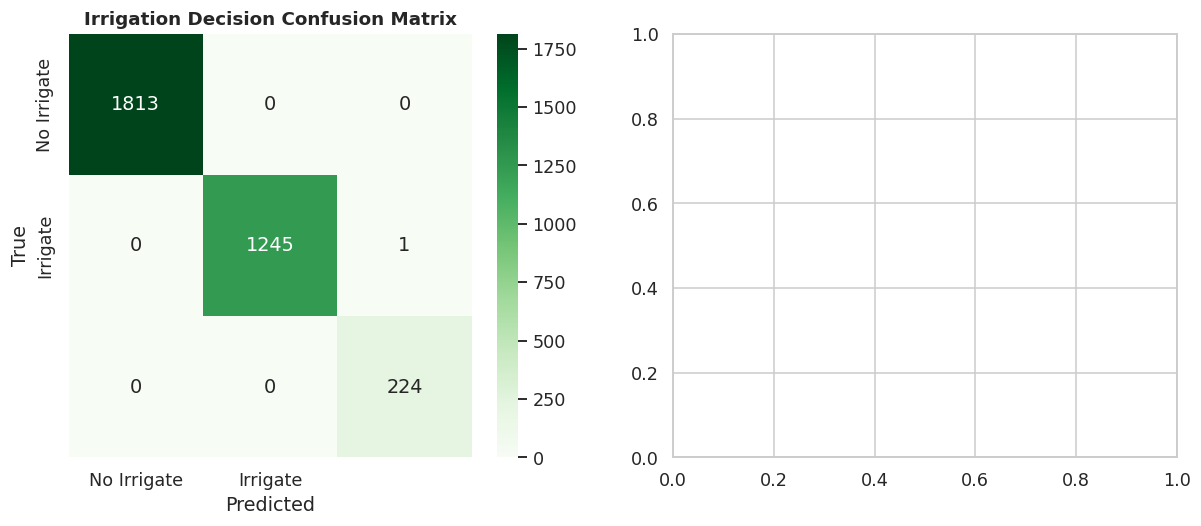

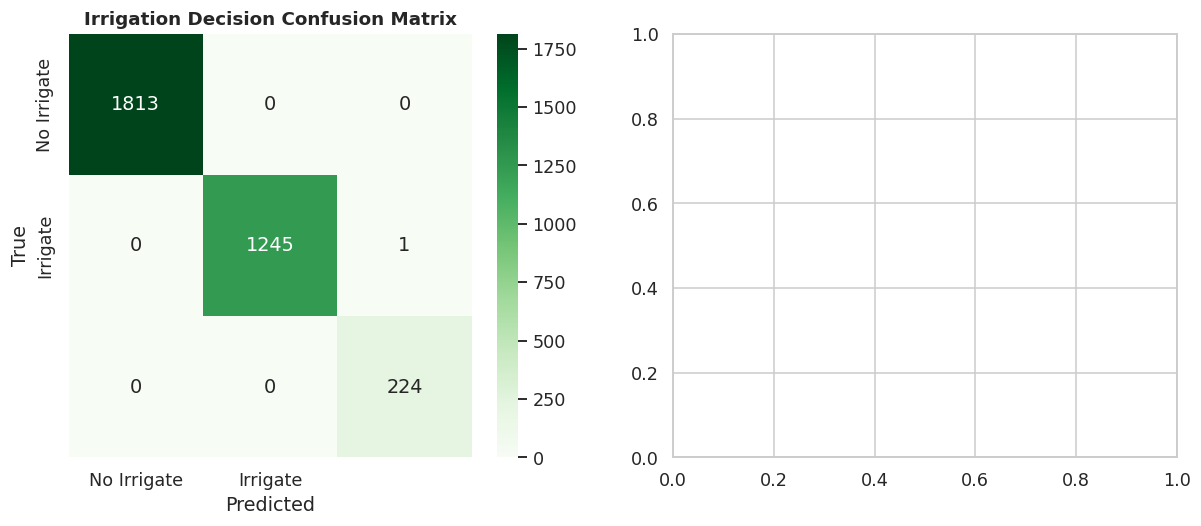

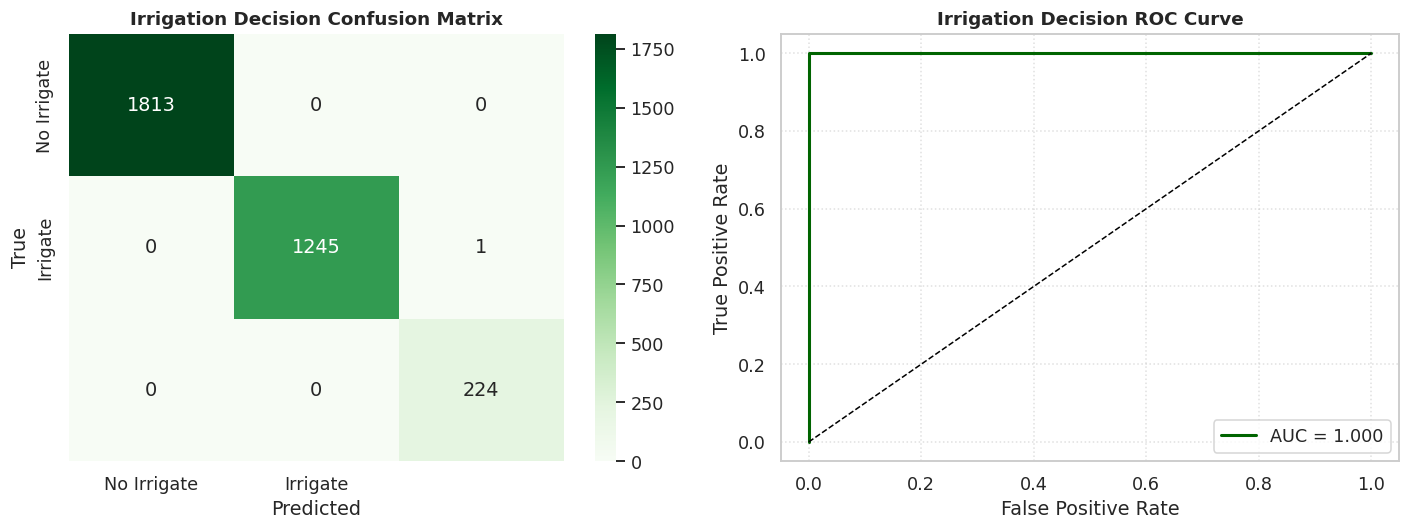

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm_irr = confusion_matrix(y_irr_te, y_irr_pred)
sns.heatmap(cm_irr, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No Irrigate", "Irrigate"],
            yticklabels=["No Irrigate", "Irrigate"], ax=axes[0])
axes[0].set_title("Irrigation Decision Confusion Matrix",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

# ROC curve
# Convert y_irr_te to binary (1 for 'irrigate', 0 for 'no irrigate' from original 0 and 2)
# Select probabilities for the positive class (index 1) from irr_proba
fpr, tpr, _ = roc_curve((y_irr_te == 1).astype(int), irr_proba[:, 1])
axes[1].plot(fpr, tpr, color="darkgreen", lw=2,
             label=f"AUC = {irr_metrics['roc_auc']:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Irrigation Decision ROC Curve", fontsize=12, fontweight="bold")
axes[1].legend(loc="lower right")
axes[1].grid(linestyle=":", alpha=0.6)

plt.tight_layout()
plt.savefig(FIG_DIR / "irrigation_cm_and_roc.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Save the irrigation pipeline (preprocessing + classifier in one artefact)
joblib.dump(irrigation_pipeline, MODEL_DIR / "irrigation_pipeline.joblib")
print("Saved:", MODEL_DIR / "irrigation_pipeline.joblib")


Saved: /content/models/irrigation_pipeline.joblib


# SECTION 21 — Bundle the Saved Models and the Comparison Table

Everything needed by the website (or any downstream user) is gathered and zipped:
- `scaler.joblib`, `label_encoder.joblib` — crop recommender preprocessing
- All 12 + 1 classical models, both ensembles, all 3 deep models — crop recommender candidates
- `irrigation_pipeline.joblib` — irrigation classifier (preprocessing bundled)
- `all_17_models_comparison.csv` — the comparison table
- All figures in `/content/figures`


In [ ]:
# Bundle saved models + comparison CSV + figures into a single zip
import shutil
BUNDLE_DIR = Path("/content/bundle")
if BUNDLE_DIR.exists():
    shutil.rmtree(BUNDLE_DIR)
BUNDLE_DIR.mkdir(parents=True, exist_ok=True)

# Copy models
shutil.copytree(MODEL_DIR, BUNDLE_DIR / "saved_models")
# Copy figures
shutil.copytree(FIG_DIR, BUNDLE_DIR / "figures")
# Copy comparison CSV
shutil.copy(out_csv, BUNDLE_DIR / out_csv.name)

zip_base = "/content/smart_farming_bundle"
zip_path = shutil.make_archive(zip_base, "zip", BUNDLE_DIR)
print("Bundle written to:", zip_path)

# Optional Colab auto-download
if IN_COLAB:
    try:
        files.download(zip_path)
    except Exception as e:
        print("Auto-download skipped:", e)


Bundle written to: /content/smart_farming_bundle.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# SECTION 22 — End-to-End Inference Demo

Load the saved artefacts and run a worked example. This is the exact code the website will run.

The demo uses a representative sensor reading that an in-field IoT node might transmit, passes it through the crop recommender (soft-voting ensemble, the winner of the test-set comparison), and then through the irrigation pipeline.


In [ ]:
# Reload the saved artefacts from disk
scaler_r = joblib.load(MODEL_DIR / "scaler.joblib")
le_r     = joblib.load(MODEL_DIR / "label_encoder.joblib")
crop_recommender = joblib.load(MODEL_DIR / "ensemble_soft_voting_ensemble.joblib")
irrigation_r     = joblib.load(MODEL_DIR / "irrigation_pipeline.joblib")
print("Reloaded scaler, label_encoder, crop recommender (soft voting), irrigation pipeline.")


Reloaded scaler, label_encoder, crop recommender (soft voting), irrigation pipeline.


In [ ]:
# Three representative sensor readings
sensor_readings = pd.DataFrame([
    {"N": 90, "P": 42, "K": 43, "temperature": 20.9, "humidity": 82.0, "ph": 6.5, "rainfall": 202.9},
    {"N": 25, "P": 35, "K": 20, "temperature": 33.1, "humidity": 60.0, "ph": 7.8, "rainfall":  60.0},
    {"N": 38, "P": 45, "K": 55, "temperature": 27.5, "humidity": 75.0, "ph": 6.2, "rainfall": 120.0},
])

# Crop recommendation
X_demo = scaler_r.transform(sensor_readings[features].values)
crop_idx = crop_recommender.predict(X_demo)
crop_names = le_r.inverse_transform(crop_idx)

print("CROP RECOMMENDATION RESULTS")
print("=" * 60)
for i, (row, name) in enumerate(zip(sensor_readings.itertuples(index=False), crop_names)):
    print(f"\nReading {i+1}: {dict(row._asdict())}")
    print(f"   Recommended crop: {name}")


CROP RECOMMENDATION RESULTS

Reading 1: {'N': 90, 'P': 42, 'K': 43, 'temperature': 20.9, 'humidity': 82.0, 'ph': 6.5, 'rainfall': 202.9}
   Recommended crop: rice

Reading 2: {'N': 25, 'P': 35, 'K': 20, 'temperature': 33.1, 'humidity': 60.0, 'ph': 7.8, 'rainfall': 60.0}
   Recommended crop: mothbeans

Reading 3: {'N': 38, 'P': 45, 'K': 55, 'temperature': 27.5, 'humidity': 75.0, 'ph': 6.2, 'rainfall': 120.0}
   Recommended crop: papaya


In [ ]:
# Irrigation decision for each demo reading
#
# The irrigation model was trained on five crops (Carrot, Chilli, Potato,
# Tomato, Wheat), seven soil types and eight growth stages, and on a moisture
# index observed between 1 and 100. None of the 22 recommender crops is among
# the five, so the two models cannot be chained on the same crop; the demo
# therefore pairs each reading with a supported crop and states that plainly.
# Inputs outside the training vocabulary are an error, never a silent fallback.
IRR_CROPS  = list(irrigation_r.named_steps["prep"].named_transformers_["cat"].categories_[0])
IRR_SOILS  = list(irrigation_r.named_steps["prep"].named_transformers_["cat"].categories_[1])
IRR_STAGES = list(irrigation_r.named_steps["prep"].named_transformers_["cat"].categories_[2])

demo_irrigation = [
    # (crop,     soil,          stage,                 moisture index 1-100)
    ("Wheat",    "Black Soil",  "Germination",         3),
    ("Tomato",   "Loam Soil",   "Flowering",           55),
    ("Potato",   "Sandy Soil",  "Vegetative Growth / Root or Tuber Development", 85),
]

print("IRRIGATION DECISION RESULTS")
print("=" * 60)
for i, ((crop, soil, stage, moi), row, rec) in enumerate(zip(demo_irrigation,
                                                            sensor_readings.itertuples(index=False),
                                                            crop_names)):
    for value, allowed, what in ((crop, IRR_CROPS, "crop"), (soil, IRR_SOILS, "soil type"), (stage, IRR_STAGES, "growth stage")):
        if value not in allowed:
            raise ValueError(f"{what} {value!r} is not in the irrigation training vocabulary: {allowed}")
    if not 1 <= moi <= 100:
        raise ValueError("moisture index must be within the observed 1-100 range")

    irr_input = pd.DataFrame([{
        "crop_id":        crop,
        "soil_type":      soil,
        "seedling_stage": stage,
        "moi":            moi,
        "temp":           row.temperature,
        "humidity":       row.humidity,
    }])
    decision  = int(irrigation_r.predict(irr_input)[0])
    proba_yes = float(irrigation_r.predict_proba(irr_input)[0][1])
    label = "IRRIGATE NOW" if decision == 1 else "DO NOT IRRIGATE"
    print(f"\nReading {i+1}  →  recommended crop: {rec}  (not an irrigation-model crop)")
    print(f"             irrigation check for {crop:<8s} / {soil} / {stage} / moisture {moi}")
    print(f"             decision: {label}  (p_irrigate={proba_yes:.3f})")


# SECTION 24 — Export for the web application

The website serves both models from compact JSON tree files evaluated by a small
TypeScript applier, so no Python runs in production. This section:

1. Embeds `mlops/web_export.py` from the repository **verbatim** — do not edit it
   here; edit the file and re-run `python3 mlops/sync_notebook.py`.
2. Converts the fitted CatBoost and the irrigation pipeline, checks a reference
   applier against the library on every training row, and writes the model JSON,
   a golden-prediction file, and a manifest with SHA-256 checksums.
3. Zips `web_export/`, `models/`, `figures/` and the comparison table for download.

**Send the resulting `smart_farming_web_export.zip` to the web repository.**


In [ ]:
# ---- mlops/web_export.py (embedded verbatim by mlops/sync_notebook.py; do not edit here) ----
"""
Export the trained models into the compact formats the web application serves.

This module is the single source of truth for the export. The same code is
embedded verbatim into the training notebook (see `mlops/sync_notebook.py`) so
a Colab run and a local run produce byte-identical artefacts.

Two models are exported:

* Crop recommender — CatBoost (22 classes), plus the StandardScaler and
  LabelEncoder it was trained with.
* Irrigation decision — the scikit-learn Pipeline (ColumnTransformer + XGBoost)
  from the thesis, binary.

For each model the export writes:

* `<name>.model.json` — a compact tree format that a ~100-line applier can
  evaluate with no ML runtime.
* `<name>-golden.json` — every training row with the library's own class
  probabilities and predicted label. This is the oracle the TypeScript applier
  is tested against.
* `<name>-manifest.json` — provenance, metrics and SHA-256 checksums.

Before anything is written, a pure-Python reference applier evaluates the
compact format and must agree with the library on every row. If it does not,
the export aborts: a format the reference applier cannot reproduce is not one
the web application can serve.
"""

from __future__ import annotations

import base64
import hashlib
import json
import os
import tempfile
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd

EXPORT_SCHEMA_VERSION = "1.0.0"

CROP_FEATURES = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
CROP_FEATURES_WEB = [
    "nitrogen",
    "phosphorus",
    "potassium",
    "temperature_c",
    "humidity_pct",
    "soil_ph",
    "rainfall_mm",
]

IRR_CAT = ["crop_id", "soil_type", "seedling_stage"]
IRR_NUM = ["moi", "temp", "humidity"]
IRR_CAT_WEB = ["crop", "soil_type", "growth_stage"]
IRR_NUM_WEB = ["moisture_pct", "temperature_c", "humidity_pct"]

# The thesis (§4.1.12) treats irrigation as binary. The source column has three
# values; this is the mapping the notebook applied and the manifest discloses.
IRRIGATION_LABEL_MAPPING = {
    "0": "do_not_irrigate",
    "1": "irrigate",
    "2": "mapped_to_0 (thesis §4.1.12 evaluates the task as binary; 1,122 rows, 6.8%)",
}


# --------------------------------------------------------------------------
# helpers
# --------------------------------------------------------------------------


def sha256_file(path: Path) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()


def b64_f32(values) -> str:
    """Float32, little-endian, base64. Compact and exact enough for tree leaves."""
    return base64.b64encode(np.asarray(values, dtype="<f4").tobytes()).decode("ascii")


def b64_f64(values) -> str:
    return base64.b64encode(np.asarray(values, dtype="<f8").tobytes()).decode("ascii")


def now_iso() -> str:
    return datetime.now(timezone.utc).replace(microsecond=0).isoformat().replace("+00:00", "Z")


def softmax(raw: np.ndarray) -> np.ndarray:
    z = raw - raw.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)


def sigmoid(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-x))


def write_json(path: Path, payload) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(payload, f, separators=(",", ":"), ensure_ascii=False)


# --------------------------------------------------------------------------
# CatBoost: compact format + reference applier
# --------------------------------------------------------------------------


def catboost_to_compact(model, scaler, label_encoder) -> dict:
    """Convert a fitted CatBoostClassifier to the compact oblivious-tree format."""
    with tempfile.TemporaryDirectory() as tmp:
        raw_path = os.path.join(tmp, "catboost.json")
        model.save_model(raw_path, format="json")
        with open(raw_path, encoding="utf-8") as f:
            raw = json.load(f)

    float_features = raw["features_info"]["float_features"]
    if any(ff.get("nan_value_treatment", "AsIs") != "AsIs" for ff in float_features):
        raise RuntimeError("Model uses NaN-aware splits; the compact applier does not support them.")
    if raw["features_info"].get("categorical_features"):
        raise RuntimeError("Model uses categorical features; the compact applier is numeric-only.")
    flat_index = {ff["feature_index"]: ff["flat_feature_index"] for ff in float_features}

    n_classes = len(model.classes_)
    scale, bias = raw["scale_and_bias"]
    bias = list(bias) if isinstance(bias, list) else [float(bias)] * n_classes

    trees = []
    for tree in raw["oblivious_trees"]:
        splits = []
        for split in tree["splits"]:
            if split.get("split_type", "FloatFeature") != "FloatFeature":
                raise RuntimeError(f"Unsupported split type {split.get('split_type')}")
            splits.append([int(flat_index[split["float_feature_index"]]), float(split["border"])])
        leaves = np.asarray(tree["leaf_values"], dtype=np.float64)
        expected = (1 << len(splits)) * n_classes
        if leaves.size != expected:
            raise RuntimeError(f"Tree has {leaves.size} leaf values, expected {expected}")
        trees.append({"splits": splits, "leaves": b64_f64(leaves)})

    return {
        "schema_version": EXPORT_SCHEMA_VERSION,
        "kind": "catboost-oblivious-multiclass",
        "feature_order": CROP_FEATURES_WEB,
        "scaler": {"mean": [float(v) for v in scaler.mean_], "scale": [float(v) for v in scaler.scale_]},
        "classes": [str(c) for c in label_encoder.classes_],
        "scale": float(scale),
        "bias": [float(b) for b in bias],
        "trees": trees,
    }


def catboost_reference_predict_proba(compact: dict, X_raw: np.ndarray) -> np.ndarray:
    """Pure-numpy applier of the compact format. The TypeScript port mirrors this."""
    mean = np.asarray(compact["scaler"]["mean"], dtype=np.float64)
    scale = np.asarray(compact["scaler"]["scale"], dtype=np.float64)
    X = ((np.asarray(X_raw, dtype=np.float64) - mean) / scale).astype(np.float32)

    n_classes = len(compact["classes"])
    raw = np.zeros((X.shape[0], n_classes), dtype=np.float64)
    for tree in compact["trees"]:
        idx = np.zeros(X.shape[0], dtype=np.int64)
        for depth, (feature, border) in enumerate(tree["splits"]):
            idx |= (X[:, feature] > np.float32(border)).astype(np.int64) << depth
        leaves = np.frombuffer(base64.b64decode(tree["leaves"]), dtype="<f8").reshape(-1, n_classes)
        raw += leaves[idx]
    raw = raw * compact["scale"] + np.asarray(compact["bias"], dtype=np.float64)
    return softmax(raw)


# --------------------------------------------------------------------------
# XGBoost pipeline: compact format + reference applier
# --------------------------------------------------------------------------


def _logit(p: float) -> float:
    return float(np.log(p / (1.0 - p)))


def xgboost_pipeline_to_compact(pipeline) -> dict:
    """Convert the irrigation Pipeline (ColumnTransformer + XGBClassifier)."""
    prep = pipeline.named_steps["prep"]
    xgb_model = pipeline.named_steps["xgb"]

    scaler = prep.named_transformers_["num"]
    encoder = prep.named_transformers_["cat"]
    if list(prep.transformers_[0][2]) != IRR_NUM or list(prep.transformers_[1][2]) != IRR_CAT:
        raise RuntimeError("ColumnTransformer column order differs from the thesis pipeline.")

    vocab = {web: [str(v) for v in cats] for web, cats in zip(IRR_CAT_WEB, encoder.categories_)}

    with tempfile.TemporaryDirectory() as tmp:
        raw_path = os.path.join(tmp, "xgb.json")
        xgb_model.get_booster().save_model(raw_path)
        with open(raw_path, encoding="utf-8") as f:
            raw = json.load(f)

    learner = raw["learner"]
    objective = learner["objective"]["name"]
    if objective != "binary:logistic":
        raise RuntimeError(f"Unsupported objective {objective}")
    base_score = float(learner["learner_model_param"]["base_score"])

    trees = []
    for tree in learner["gradient_booster"]["model"]["trees"]:
        trees.append(
            {
                "feature": [int(v) for v in tree["split_indices"]],
                "threshold": [float(v) for v in tree["split_conditions"]],
                "left": [int(v) for v in tree["left_children"]],
                "right": [int(v) for v in tree["right_children"]],
                "default_left": [int(v) for v in tree["default_left"]],
            }
        )

    return {
        "schema_version": EXPORT_SCHEMA_VERSION,
        "kind": "xgboost-binary-logistic",
        # Trained on a sparse matrix: absent one-hot entries and exact zeros are
        # missing values and follow `default_left`. The applier must honour this.
        "sparse_zeros_are_missing": True,
        "numeric_order": IRR_NUM_WEB,
        "categorical_order": IRR_CAT_WEB,
        "scaler": {"mean": [float(v) for v in scaler.mean_], "scale": [float(v) for v in scaler.scale_]},
        "vocabulary": vocab,
        # Stored as a probability by XGBoost >= 2; the applier adds logit(base_score).
        "base_score": base_score,
        "trees": trees,
    }


def xgboost_reference_encode(compact: dict, frame: pd.DataFrame) -> np.ndarray:
    """
    Replicates ColumnTransformer output: scaled numerics, then one-hot blocks.

    The thesis pipeline's ColumnTransformer emits a *sparse* matrix, so XGBoost
    was trained seeing every one-hot zero (and any exactly-zero scaled value) as
    a missing value routed by `default_left`. The applier must do the same, so
    zeros are encoded as NaN here.
    """
    mean = np.asarray(compact["scaler"]["mean"], dtype=np.float64)
    scale = np.asarray(compact["scaler"]["scale"], dtype=np.float64)
    num = (frame[IRR_NUM].to_numpy(dtype=np.float64) - mean) / scale
    num = np.where(num == 0.0, np.nan, num)

    blocks = [num]
    for col, web in zip(IRR_CAT, IRR_CAT_WEB):
        cats = compact["vocabulary"][web]
        onehot = np.full((len(frame), len(cats)), np.nan, dtype=np.float64)
        index = {c: i for i, c in enumerate(cats)}
        for row, value in enumerate(frame[col].astype(str)):
            if value in index:
                onehot[row, index[value]] = 1.0
        blocks.append(onehot)
    return np.hstack(blocks).astype(np.float32)


def xgboost_reference_predict_proba(compact: dict, frame: pd.DataFrame) -> np.ndarray:
    X = xgboost_reference_encode(compact, frame)
    margin = np.full(X.shape[0], _logit(compact["base_score"]), dtype=np.float64)
    for tree in compact["trees"]:
        feature = tree["feature"]
        threshold = tree["threshold"]
        left = tree["left"]
        right = tree["right"]
        default_left = tree["default_left"]
        for row in range(X.shape[0]):
            node = 0
            while left[node] != -1:
                value = X[row, feature[node]]
                if np.isnan(value):
                    node = left[node] if default_left[node] else right[node]
                else:
                    node = left[node] if value < np.float32(threshold[node]) else right[node]
            margin[row] += threshold[node]
    return sigmoid(margin)


# --------------------------------------------------------------------------
# manifests
# --------------------------------------------------------------------------


def make_manifest(
    *,
    model_name: str,
    task: str,
    model_version: str,
    trained_at: str,
    git_revision: str,
    dataset_name: str,
    dataset_csv: Path,
    feature_order: list[str],
    classes: int,
    metrics: dict,
    artefacts: dict[str, Path],
    root: Path,
    extra: dict | None = None,
) -> dict:
    manifest = {
        "schema_version": "1.0.0",
        "model_name": model_name,
        "task": task,
        "model_version": model_version,
        "status": "production",
        "trained_at": trained_at,
        "git_revision": git_revision,
        "dataset_versions": {dataset_name: f"sha256:{sha256_file(dataset_csv)}"},
        "feature_order": feature_order,
        "classes": classes,
        "metrics": metrics,
        "artifacts": {
            name: {"path": str(path.relative_to(root)).replace(os.sep, "/"), "sha256": sha256_file(path)}
            for name, path in artefacts.items()
        },
        "release_gate": None,
    }
    if extra:
        manifest.update(extra)
    return manifest


# --------------------------------------------------------------------------
# exports
# --------------------------------------------------------------------------


def export_crop_model(
    *,
    model,
    scaler,
    label_encoder,
    crop_df: pd.DataFrame,
    dataset_csv: Path,
    out_dir: Path,
    root: Path,
    git_revision: str,
    trained_at: str,
    seed: int = 42,
) -> dict:
    from sklearn.metrics import accuracy_score, f1_score
    from sklearn.model_selection import train_test_split

    out_dir.mkdir(parents=True, exist_ok=True)

    X = crop_df[CROP_FEATURES].to_numpy(dtype=np.float64)
    y = label_encoder.transform(crop_df["label"].to_numpy())

    # The same partition the thesis evaluated on.
    _, X_test, _, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=seed)
    y_pred = model.predict(scaler.transform(X_test)).ravel().astype(int)
    accuracy = float(accuracy_score(y_test, y_pred))
    macro_f1 = float(f1_score(y_test, y_pred, average="macro"))
    print(f"CatBoost held-out accuracy {accuracy:.6f}  macro F1 {macro_f1:.6f}")

    compact = catboost_to_compact(model, scaler, label_encoder)

    # Reference applier must reproduce the library on every row before export.
    lib_proba = model.predict_proba(scaler.transform(X))
    ref_proba = catboost_reference_predict_proba(compact, X)
    max_abs = float(np.max(np.abs(lib_proba - ref_proba)))
    label_agreement = float(np.mean(lib_proba.argmax(1) == ref_proba.argmax(1)))
    print(f"Reference applier: label agreement {label_agreement:.6f}, max |Δp| {max_abs:.2e}")
    if label_agreement < 1.0 or max_abs > 1e-5:
        raise RuntimeError("Compact CatBoost format does not reproduce the library; export aborted.")

    model_path = out_dir / "crop-catboost.model.json"
    cbm_path = out_dir / "crop-catboost.cbm"
    golden_path = out_dir / "crop-golden.json"

    write_json(model_path, compact)
    model.save_model(str(cbm_path), format="cbm")
    write_json(
        golden_path,
        {
            "schema_version": EXPORT_SCHEMA_VERSION,
            "feature_order": CROP_FEATURES_WEB,
            "classes": compact["classes"],
            "rows": [
                {
                    "input": [float(v) for v in X[i]],
                    "label": str(crop_df["label"].iloc[i]),
                    "predicted": compact["classes"][int(lib_proba[i].argmax())],
                    "proba": [round(float(p), 8) for p in lib_proba[i]],
                }
                for i in range(len(X))
            ],
        },
    )

    manifest = make_manifest(
        model_name="crop-recommendation-catboost",
        task="crop_recommendation",
        model_version="1.0.0",
        trained_at=trained_at,
        git_revision=git_revision,
        dataset_name="crop_recommendation",
        dataset_csv=dataset_csv,
        feature_order=CROP_FEATURES,
        classes=len(compact["classes"]),
        metrics={"held_out_accuracy": round(accuracy, 6), "macro_f1": round(macro_f1, 6)},
        artefacts={"model": model_path, "native": cbm_path, "golden": golden_path},
        root=root,
        extra={
            "serving": {"format": "catboost-oblivious-multiclass", "score_kind": "uncalibrated_model_score"},
            "notes": "Scaler and label encoder are embedded in the model JSON.",
        },
    )
    write_json(out_dir / "crop-manifest.json", manifest)
    return manifest


def export_irrigation_model(
    *,
    pipeline,
    smart_df: pd.DataFrame,
    dataset_csv: Path,
    out_dir: Path,
    root: Path,
    git_revision: str,
    trained_at: str,
    seed: int = 42,
) -> dict:
    from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef, roc_auc_score
    from sklearn.model_selection import train_test_split

    out_dir.mkdir(parents=True, exist_ok=True)

    frame = smart_df[IRR_CAT + IRR_NUM].copy()
    y = (smart_df["result"] == 1).astype(int).to_numpy()
    label2_rows = int((smart_df["result"] == 2).sum())

    _, X_test, _, y_test = train_test_split(frame, y, test_size=0.20, stratify=y, random_state=seed)
    y_pred = pipeline.predict(X_test)
    proba_test = pipeline.predict_proba(X_test)[:, 1]
    metrics = {
        "held_out_accuracy": round(float(accuracy_score(y_test, y_pred)), 6),
        "macro_f1": round(float(f1_score(y_test, y_pred, average="macro")), 6),
        "mcc": round(float(matthews_corrcoef(y_test, y_pred)), 6),
        "roc_auc": round(float(roc_auc_score(y_test, proba_test)), 6),
    }
    print("Irrigation held-out:", metrics)

    compact = xgboost_pipeline_to_compact(pipeline)

    lib_proba = pipeline.predict_proba(frame)[:, 1]
    ref_proba = xgboost_reference_predict_proba(compact, frame)
    max_abs = float(np.max(np.abs(lib_proba - ref_proba)))
    label_agreement = float(np.mean((lib_proba >= 0.5) == (ref_proba >= 0.5)))
    print(f"Reference applier: label agreement {label_agreement:.6f}, max |Δp| {max_abs:.2e}")
    if label_agreement < 1.0 or max_abs > 1e-5:
        raise RuntimeError("Compact XGBoost format does not reproduce the library; export aborted.")

    model_path = out_dir / "irrigation-xgboost.model.json"
    golden_path = out_dir / "irrigation-golden.json"
    write_json(model_path, compact)
    write_json(
        golden_path,
        {
            "schema_version": EXPORT_SCHEMA_VERSION,
            "categorical_order": IRR_CAT_WEB,
            "numeric_order": IRR_NUM_WEB,
            "rows": [
                {
                    "categorical": [str(frame[c].iloc[i]) for c in IRR_CAT],
                    "numeric": [float(frame[c].iloc[i]) for c in IRR_NUM],
                    "label": int(y[i]),
                    "source_result": int(smart_df["result"].iloc[i]),
                    "proba_irrigate": round(float(lib_proba[i]), 8),
                }
                for i in range(len(frame))
            ],
        },
    )

    manifest = make_manifest(
        model_name="irrigation-decision-xgboost",
        task="irrigation_decision",
        model_version="1.0.0",
        trained_at=trained_at,
        git_revision=git_revision,
        dataset_name="smart_agriculture",
        dataset_csv=dataset_csv,
        feature_order=IRR_CAT + IRR_NUM,
        classes=2,
        metrics=metrics,
        artefacts={"model": model_path, "golden": golden_path},
        root=root,
        extra={
            "serving": {"format": "xgboost-binary-logistic", "score_kind": "uncalibrated_model_score"},
            "label_mapping": IRRIGATION_LABEL_MAPPING,
            "label_2_rows_mapped_to_0": label2_rows,
            "vocabulary": compact["vocabulary"],
        },
    )
    write_json(out_dir / "irrigation-manifest.json", manifest)
    return manifest


def load_smart_agriculture(csv_path: Path) -> pd.DataFrame:
    """Loads the Smart Agriculture CSV with the notebook's column normalisation."""
    frame = pd.read_csv(csv_path)
    frame.columns = [c.strip().lower().replace(" ", "_") for c in frame.columns]
    return frame


def train_irrigation_pipeline(smart_df: pd.DataFrame, seed: int = 42):
    """The thesis pipeline, verbatim from the notebook (cell 117)."""
    import xgboost as xgb
    from sklearn.compose import ColumnTransformer
    from sklearn.model_selection import train_test_split
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import OneHotEncoder, StandardScaler

    X = smart_df[IRR_CAT + IRR_NUM].copy()
    y = (smart_df["result"] == 1).astype(int).to_numpy()
    X_train, _, y_train, _ = train_test_split(X, y, test_size=0.20, stratify=y, random_state=seed)

    preprocess = ColumnTransformer(
        [("num", StandardScaler(), IRR_NUM), ("cat", OneHotEncoder(handle_unknown="ignore"), IRR_CAT)]
    )
    pipeline = Pipeline(
        [
            ("prep", preprocess),
            (
                "xgb",
                xgb.XGBClassifier(
                    n_estimators=400,
                    max_depth=6,
                    learning_rate=0.1,
                    tree_method="hist",
                    random_state=seed,
                    n_jobs=-1,
                    eval_metric="logloss",
                    verbosity=0,
                ),
            ),
        ]
    )
    pipeline.fit(X_train, y_train)
    return pipeline


In [ ]:
# Run the export against this session's fitted objects.
# Each model is exported only if it is available (in memory or saved under
# MODEL_DIR), so a partial run — e.g. retraining irrigation alone — still works.
import subprocess
WEB_EXPORT_DIR = Path("/content/web_export") if IN_COLAB else (MODEL_DIR.parent / "web_export")
WEB_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

def _get(name, fallback_path):
    obj = globals().get(name)
    if obj is not None:
        return obj
    return joblib.load(fallback_path) if fallback_path.exists() else None

_catboost = (fitted_classical["CatBoost"] if "fitted_classical" in globals() and "CatBoost" in fitted_classical
             else _get("__no_such_global__", MODEL_DIR / "classical_catboost.joblib"))
_scaler   = _get("scaler",  MODEL_DIR / "scaler.joblib")
_le       = _get("le",      MODEL_DIR / "label_encoder.joblib")
_irr      = _get("irrigation_pipeline", MODEL_DIR / "irrigation_pipeline.joblib")

_revision = os.environ.get("EXPORT_GIT_REVISION", f"colab-run-{now_iso()}")
exported = []

if _catboost is not None and _scaler is not None and _le is not None:
    _crop_csv = next(DATA_DIR.glob("Crop_recommendation*.csv"))
    _crop_df  = crop_df if "crop_df" in globals() else pd.read_csv(_crop_csv)
    export_crop_model(
        model=_catboost, scaler=_scaler, label_encoder=_le, crop_df=_crop_df,
        dataset_csv=_crop_csv, out_dir=WEB_EXPORT_DIR, root=WEB_EXPORT_DIR.parent,
        git_revision=_revision, trained_at=now_iso(), seed=SEED,
    )
    exported.append("crop")
else:
    print("Crop model not available in this session — skipping crop export (the web repo already has it).")

if _irr is not None:
    _smart_csv = next(p for p in DATA_DIR.glob("*.csv")
                      if "result" in [c.strip().lower() for c in pd.read_csv(p, nrows=1).columns])
    _smart_df  = smart_df if "smart_df" in globals() else load_smart_agriculture(_smart_csv)
    export_irrigation_model(
        pipeline=_irr, smart_df=_smart_df, dataset_csv=_smart_csv,
        out_dir=WEB_EXPORT_DIR, root=WEB_EXPORT_DIR.parent,
        git_revision=_revision, trained_at=now_iso(), seed=SEED,
    )
    exported.append("irrigation")
else:
    print("Irrigation pipeline not available in this session — skipping irrigation export.")

print("\nExported:", ", ".join(exported) or "nothing", "→", WEB_EXPORT_DIR)
for p in sorted(WEB_EXPORT_DIR.iterdir()):
    print(f"  {p.name:<34s} {p.stat().st_size/1e6:7.2f} MB")


In [ ]:
# Package everything the web repository needs into one archive and download it.
import shutil
_bundle_root = WEB_EXPORT_DIR.parent / "smart_farming_web_export"
if _bundle_root.exists():
    shutil.rmtree(_bundle_root)
_bundle_root.mkdir()

shutil.copytree(WEB_EXPORT_DIR, _bundle_root / "web_export")
shutil.copytree(MODEL_DIR,      _bundle_root / "models")
shutil.copytree(FIG_DIR,        _bundle_root / "figures")
_cmp = next((p for p in [FIG_DIR.parent / "all_17_models_comparison.csv", MODEL_DIR / "all_17_models_comparison.csv"] if p.exists()), None)
if _cmp is not None:
    shutil.copy(_cmp, _bundle_root / "all_17_models_comparison.csv")
elif "results" in globals():
    pd.DataFrame(results).to_csv(_bundle_root / "all_17_models_comparison.csv", index=False)

_zip = shutil.make_archive(str(_bundle_root), "zip", root_dir=_bundle_root)
print("Archive:", _zip, f"({Path(_zip).stat().st_size/1e6:.1f} MB)")
if IN_COLAB:
    files.download(_zip)


# SECTION 23 — Closing Notes for the Report

What this notebook produces, end to end:

1. Reproducible EDA over the seven open-access datasets used by the project (Sections 1 to 9).
2. Standardised, leakage-free preprocessing for the crop recommendation task (Section 10).
3. A unified evaluation harness covering nine metrics for every model (Section 11).
4. Twelve classical models trained, evaluated, and saved (Section 12).
5. Bayesian hyperparameter tuning of XGBoost via Optuna (Section 13).
6. Two ensembles (soft voting, stacking) trained and evaluated (Section 14).
7. Three deep learning architectures (MLP, 1D CNN, Attention MLP) trained and evaluated (Section 15).
8. A single comparison table covering all 17 configurations (Section 16).
9. Grouped comparison charts for every metric, classical vs ensembles vs deep learning (Section 17).
10. Confusion matrices for every one of the 17 models (Section 18).
11. SHAP global, beeswarm and waterfall explainability plots on the tuned XGBoost (Section 19).
12. A companion binary irrigation classifier evaluated on the same metric battery (Section 20).
13. All artefacts bundled for deployment (Section 21).
14. An end-to-end inference demo (Section 22).

Every chart, table, model file, and the comparison CSV are written to disk and zipped for download. The CSV `all_17_models_comparison.csv` is the canonical reference for any table appearing in the dissertation.

The final section exports both models to the compact JSON format the website serves, verifies a reference applier against the library on every row, and packages the deliverables as `smart_farming_web_export.zip`.
